# 🔬 UNIDAD 3: Machine Learning para Nanotecnología — Algoritmos Clásicos
**Curso:** Modelado, Simulación e IA en Nanotecnología  
**Duración:** 2–3 semanas | **Nivel:** Intermedio

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ljyudico/Antigravity-Nano-Research-Multiagentic-Core/blob/main/educational_content/unit_03_ml_nanomaterials/UNIDAD_3_ML_FUNDAMENTOS_algoritmos_clasicos.ipynb)

> 💡 **Recomendación Colab:** Para las celdas de CNN y modelos pesados, activa la GPU:  
> `Runtime → Change runtime type → T4 GPU (gratuita)`

---


# Versión moderna Machine Learning Algorithms From Scratch

## Part I

Data Preparation

# Capítulo 1 Lectura de Datos desde ub CSV

## 1.1 Ingeniería de Carga con Pandas

Cuando usamos `pd.read_csv()`, no solo estamos leyendo texto; estamos creando un **Esquema de Datos**. Una práctica avanzada es definir los tipos de datos (*dtypes*) de antemano para ahorrar memoria y evitar errores de interpretación.

### Manejo de inconsistencias en la carga

Es común que los archivos CSV tengan "ruido". Pandas permite gestionar esto desde la misma función de carga:

```python
import pandas as pd
import numpy as np

# Carga avanzada: manejando valores faltantes y tipos
dataset = pd.read_csv(
    url,
    names=col_names,
    na_values="?",        # Convierte signos de interrogación en NaN (nulos)
    sep=",",              # Define el separador (puede ser ';', '\t', etc.)
    engine='c'            # Usa el motor de C para mayor velocidad
)

# Verificar si hay valores nulos
print(dataset.isnull().sum())

```

---

## 1.2 Transformaciones de Columna (Encoding Avanzado)

En el tutorial original convertimos strings a enteros manualmente. En la práctica moderna, existen dos tipos de transformaciones principales según la naturaleza de la variable:

### 1.2.1 Label Encoding (Variables Ordinales)

Se usa cuando hay un orden lógico (ej. "Bajo", "Medio", "Alto"). Como vimos con el dataset Iris, asigna `0, 1, 2...`.

### 1.2.2 One-Hot Encoding (Variables Nominales)

Si las categorías no tienen un orden (ej. colores o países), usar `0, 1, 2` puede confundir al modelo, haciéndole creer que "2" es mayor o más importante que "0". Para esto usamos **One-Hot Encoding**, que crea una columna nueva por cada categoría.

```python
# Ejemplo: Si tuviéramos una columna 'color' con 'Rojo', 'Azul'
# dataset = pd.get_dummies(dataset, columns=['color'])

```

---

## 1.3 Análisis Exploratorio Rápido (EDA)

Una vez cargados los datos, un banco de pruebas moderno requiere que entendamos la distribución antes de convertir todo a floats.

* **`dataset.describe()`**: Genera estadísticas descriptivas (media, desviación estándar, min, max).
* **`dataset.info()`**: Muestra el uso de memoria y los tipos de objetos.
* **`dataset.corr()`**: Calcula la matriz de correlación para ver qué variables influyen más en el resultado.

---

## 1.4 El concepto de "Data Leakage" (Fuga de Datos)

Un error crítico al cargar y convertir datos es aplicar transformaciones a todo el dataset antes de dividirlo en entrenamiento y prueba.

> **Regla de Oro:** Cualquier valor que dependa del promedio o la distribución (como rellenar nulos o escalar datos) debe calcularse **solo** con los datos de entrenamiento y luego aplicarse a los de prueba. Si lo haces antes, tu modelo "hará trampa" al conocer información del futuro.

---

## 1.5 Comparativa de Estructuras de Datos

| Estructura | Uso Principal | Ventaja |
| --- | --- | --- |
| **List of Lists** (Tutorial original) | Lógica pura de Python | No requiere librerías externas. |
| **NumPy Array** | Operaciones matemáticas pesadas | Es extremadamente rápido para cálculos vectoriales ($X \cdot W$). |
| **Pandas DataFrame** | Manipulación y limpieza | Permite indexar por nombre de columna y manejar nulos fácilmente. |

---

## Resumen del Flujo de Trabajo Profesional

1. **Ingesta:** `pd.read_csv` con definición de nulos.
2. **Validación:** Chequeo de tipos con `.dtypes`.
3. **Limpieza:** Imputación de valores faltantes (rellenar nulos).
4. **Codificación:** Transformar texto a números (Label o One-Hot).
5. **Casteo:** Asegurar que todo sea `float32` o `int64` para el consumo del algoritmo.

Para profundizar en la carga de datos, vamos a utilizar el **Iris Flower Dataset** como el ejemplo maestro. Este dataset es perfecto para ilustrar la carga moderna porque contiene tanto datos numéricos (longitud de pétalos) como datos categóricos (nombres de las especies), lo que nos obliga a realizar transformaciones.

Aquí tienes el ejemplo completo de nivel profesional:

---

### Ejemplo Maestro: Carga y Procesamiento de Iris Dataset

En este flujo, no solo cargamos el archivo; preparamos los datos para que sean digeribles por cualquier algoritmo de Scikit-Learn.

```python
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Definición de la fuente y metadatos
# Es una buena práctica definir los nombres de las columnas si el CSV no los tiene
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"
columnas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

# 2. Carga inteligente con Pandas
# Pandas detecta automáticamente que los primeros 4 campos son números (floats)
df = pd.read_csv(url, names=columnas)

# 3. Inspección profunda
print("--- Primeras filas del dataset ---")
print(df.head())

print("\n--- Tipos de datos detectados ---")
print(df.dtypes)
# Verás: float64 para las medidas y 'object' (string) para la especie

# 4. Transformación de la Variable Objetivo (Species)
# Los modelos de ML no entienden "Iris-setosa", necesitan "0, 1 o 2"
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

# 5. Verificación del Mapeo
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"\nMapeo de especies: {mapping}")

# 6. Separación para el Modelo (X e y)
# X = Matriz de características (Features)
# y = Vector de etiquetas (Target)
X = df.drop(['species', 'species_encoded'], axis=1).values
y = df['species_encoded'].values

print(f"\nForma de X (Características): {X.shape}")
print(f"Forma de y (Etiquetas): {y.shape}")

```

---

### ¿Por qué este enfoque es superior al manual?

1. **Inferencia de Tipos:** Notarás que no tuvimos que escribir una función `str_column_to_float`. Pandas analizó el archivo y asignó `float64` automáticamente a las columnas de medidas.
2. **Manejo de Memoria:** Al usar `.values` al final, convertimos el DataFrame de Pandas en un **NumPy Array**. Esto es vital porque Scikit-Learn está optimizado para trabajar con la velocidad de cómputo de NumPy.
3. **Consistencia con LabelEncoder:** Si mañana el dataset tuviera 10 especies nuevas, el `LabelEncoder` las detectaría y enumeraría automáticamente sin que tengas que actualizar un diccionario manual.

### Análisis Estadístico Post-Carga (Opcional pero recomendado)

Una vez cargado el Iris dataset, el siguiente paso lógico en un banco de pruebas es entender qué cargamos:

```python
# Resumen estadístico de las medidas
print(df.describe())

# Ver la distribución de las clases para asegurar que no hay desbalanceo
print(df['species'].value_counts())

```

### Extensiones del Dataset Iris

Este dataset es el estándar porque permite probar:

* **Clasificación Multiclase:** Tienes 3 especies distintas (no es solo binario como Sí/No).
* **Correlación:** Puedes ver cómo el ancho del pétalo suele crecer proporcionalmente al largo, lo cual es un excelente ejercicio de visualización.





# Capítulo 2: Escalado de Datos (Scaling)

En Machine Learning, las características (variables) rara vez tienen el mismo rango. Por ejemplo, una columna "Edad" varía de 0 a 100, mientras que "Ingresos" puede variar de 0 a 1,000,000. Los algoritmos que utilizan cálculos de distancia o gradientes (como KNN, SVM o Regresión Logística) se verán sesgados hacia la variable con números más grandes. El **escalado** normaliza el campo de juego.

## 2.1 Tipos de Escalado

Existen dos métodos principales para reescalar los datos. La elección depende de la distribución de tus datos y del algoritmo que planees utilizar.

### 2.1.1 Normalización (Min-Max Scaling)

Rescala los datos para que todos los valores se encuentren en el rango **[0, 1]**. Es extremadamente útil cuando no conoces la distribución de tus datos o cuando el algoritmo no asume una distribución específica.

**Fórmula matemática:**


$$x_{norm} = \frac{x - min(x)}{max(x) - min(x)}$$

### 2.1.2 Estandarización (Standard/Z-Score Scaling)

Transforma los datos para que tengan una **media de 0** y una **desviación estándar de 1**. Es el método estándar para algoritmos que asumen que los datos siguen una distribución normal (Gausiana).

**Fórmula matemática:**


$$z = \frac{x - \mu}{\sigma}$$


Donde $\mu$ es la media y $\sigma$ es la desviación estándar.

---

## 2.2 Implementación Práctica en Python

Utilizaremos el dataset de **Pima Indians Diabetes** para demostrar ambos métodos con la librería `scikit-learn`.

### 1. Preparación de los Datos

Primero, cargamos los datos y los dividimos en características ($X$) y etiquetas ($y$).

```python
import pandas as pd
from sklearn.model_selection import train_test_split

# Carga del dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
dataframe = pd.read_csv(url, names=names)

# Separación de variables
array = dataframe.values
X = array[:, 0:8]
y = array[:, 8]

# División en entrenamiento y prueba (importante para evitar fuga de datos)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=7)

```

### 2. Aplicación de Normalización

Usamos `MinMaxScaler` para llevar los valores al rango entre 0 y 1.

```python
from sklearn.preprocessing import MinMaxScaler

# 1. Crear el escalador
scaler_norm = MinMaxScaler(feature_range=(0, 1))

# 2. Ajustar solo con datos de entrenamiento y transformar ambos
# fit_transform calcula el min y max del set de entrenamiento
X_train_norm = scaler_norm.fit_transform(X_train)
X_test_norm = scaler_norm.transform(X_test)

print("Primer registro normalizado:")
print(X_train_norm[0])

```

### 3. Aplicación de Estandarización

Usamos `StandardScaler` para centrar los datos en 0 con varianza 1.

```python
from sklearn.preprocessing import StandardScaler

# 1. Crear el escalador
scaler_std = StandardScaler()

# 2. Ajustar con entrenamiento y transformar
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

print("Primer registro estandarizado:")
print(X_train_std[0])

```

---

## 2.3 Comparativa Técnica

| Característica | Normalización (Min-Max) | Estandarización (Standard) |
| --- | --- | --- |
| **Rango de salida** | Estrictamente $[0, 1]$ | No definido (usualmente $[-3, 3]$) |
| **Media/Desviación** | Variable | Media = 0, Std = 1 |
| **Sensibilidad a Outliers** | **Muy Alta** (un valor extremo arruina el rango) | **Media/Baja** (más robusto) |
| **Algoritmos ideales** | Redes Neuronales, KNN, K-Means | Regresión Logística, SVM, PCA |

---

## 2.4 La Regla de Oro: Evitar el "Data Leakage"

Un error común es ajustar el escalador (`fit`) usando **todo** el dataset. Esto es incorrecto porque el set de entrenamiento "aprendería" información (como el valor máximo o la media) del set de prueba, lo cual es una trampa.

* **Paso 1:** `scaler.fit(X_train)` $\rightarrow$ El escalador aprende de los datos que el modelo verá para aprender.
* **Paso 2:** `scaler.transform(X_train)` y `scaler.transform(X_test)` $\rightarrow$ Ambos se escalan usando los parámetros del entrenamiento.

---

## 2.5 Resumen del Capítulo

1. **Escalar** es necesario para que todas las variables tengan el mismo peso relativo.
2. **Normaliza** cuando no conozcas la distribución o uses algoritmos de distancias.
3. **Estandariza** cuando tus datos sigan una distribución normal o tengan valores atípicos.
4. Utiliza siempre el **Pipeline** de Scikit-Learn para automatizar este proceso sin errores.




# Capítulo 3: Métodos de Evaluación de Algoritmos

El objetivo fundamental del modelado predictivo es crear modelos que tengan un buen rendimiento sobre **datos nuevos**. Dado que no tenemos esos datos en el momento del entrenamiento, dividimos nuestros datos actuales mediante métodos estadísticos para simular "datos no vistos".

## 3.1 El Concepto de Remuestreo

El remuestreo consiste en extraer diferentes subconjuntos de los datos disponibles para entrenar y probar el modelo repetidamente. Esto nos permite:

1. Obtener una estimación insesgada del error.
2. Elegir los mejores parámetros del modelo (Hyperparameter Tuning).
3. Comparar la estabilidad de diferentes algoritmos entre sí.

---

## 3.2 Tutorial de Implementación

### 3.2.1 Método 1: Train/Test Split

Es el método más directo: dividimos el dataset en dos bloques. Uno para "estudiar" (Train) y otro para "el examen final" (Test).

#### Implementación Moderna con Scikit-Learn

En lugar de manipular listas manualmente, utilizamos `train_test_split`, que incluye funcionalidades de **barajado (shuffling)** y **semilla aleatoria** integradas.

```python
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Preparar un dataset de ejemplo (Contrived Dataset)
data = {'valor': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}
df = pd.DataFrame(data)

# 2. Aplicar el split
# test_size=0.4 significa 60% entrenamiento, 40% prueba
# random_state asegura que el split sea reproducible
train, test = train_test_split(df, test_size=0.4, random_state=1)

print("--- Train Set ---")
print(train.values.flatten())
print("\n--- Test Set ---")
print(test.values.flatten())

```

---

### 3.2.2 Método 2: K-Fold Cross-Validation

La validación cruzada es el estándar de oro. Divide los datos en $K$ grupos (folds). El modelo se entrena $K$ veces; cada vez, un grupo diferente se usa como test y los otros $K-1$ como entrenamiento.

#### Implementación Moderna con Scikit-Learn

Usamos `KFold` para gestionar los índices de cada partición de forma automática.

```python
from sklearn.model_selection import KFold

# 1. Configurar el método K-Fold (K=5)
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

print("--- Particiones de Cross-Validation ---")
# El loop nos muestra qué índices se usan para entrenar y cuáles para validar en cada paso
for i, (train_idx, test_idx) in enumerate(kfold.split(df)):
    print(f"Fold {i+1}:")
    print(f"  Entrenamiento (índices): {train_idx}")
    print(f"  Prueba (índices):        {test_idx}")

```

---

## 3.3 ¿Cómo elegir el método adecuado?

La elección depende principalmente del tamaño de tu dataset y de tus recursos computacionales.

| Método | Cuándo usarlo | Ventaja | Desventaja |
| --- | --- | --- | --- |
| **Train/Test Split** | Datasets inmensos (millones de filas) o modelos muy lentos. | Muy rápido; solo se entrena un modelo. | Puede ser "suertudo" o "desafortunado" según el split; alta varianza. |
| **K-Fold CV** | Datasets pequeños o medianos; modelos rápidos. | Estimación robusta y estable; usa todos los datos para test. | Costoso; requiere entrenar el modelo $K$ veces. |

---

## 3.4 Ampliación: Conceptos Avanzados de Evaluación

Para que tu banco de pruebas sea verdaderamente profesional, debes considerar estos tres conceptos adicionales:

### 1. Stratified K-Fold (Estratificación)

En problemas de clasificación donde las clases están desbalanceadas (ej: 90% sanos, 10% diabéticos), un split aleatorio normal podría dejar a un fold sin ejemplos de diabéticos. La **estratificación** fuerza a cada fold a mantener la proporción original de las clases.

### 2. Shuffle Split (Repeticiones Aleatorias)

A diferencia de K-Fold, donde cada dato se usa exactamente una vez para test, Shuffle Split realiza múltiples divisiones aleatorias independientes. Es útil para datasets muy pequeños donde quieres repetir la evaluación 100 veces para ver la distribución del error.

### 3. Time Series Split

Si tus datos dependen del tiempo (ej: precios de acciones), no puedes usar K-Fold normal porque estarías usando el "futuro" para predecir el "pasado". Se usa una ventana deslizante donde el entrenamiento siempre ocurre cronológicamente antes que el test.

---

## 3.5 Resumen del Capítulo

* **Evaluar** es simular el rendimiento en el mundo real.
* **Train/Test Split** es rápido pero ruidoso.
* **K-Fold CV** es lento pero confiable.
* **Estratificar** es obligatorio en clasificación para mantener la representatividad.





# Capítulo 4: Métricas de Evaluación

Una vez que el modelo ha realizado predicciones, debemos cuantificar su calidad. Las métricas de rendimiento nos permiten comparar objetivamente diferentes algoritmos, configuraciones e ingeniería de variables.

---

## 4.1 Métricas para Clasificación

En clasificación, predecimos etiquetas (ej: "Spam" o "No Spam").

### 4.1.1 Accuracy (Precisión Global)

Es el porcentaje de predicciones correctas frente al total. Es útil solo cuando las clases están equilibradas.

**Fórmula:**


$$Accuracy = \frac{Verdaderos Positivos + Verdaderos Negativos}{Total de Predicciones}$$

```python
from sklearn.metrics import accuracy_score

# Datos de ejemplo
actual = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
predicted = [0, 1, 0, 0, 0, 1, 0, 1, 1, 1]

accuracy = accuracy_score(actual, predicted)
print(f"Accuracy: {accuracy * 100:.2f}%")

```

### 4.1.2 Matriz de Confusión

Es una tabla que desglosa los aciertos y errores por cada clase. Permite ver si el modelo confunde una clase específica con otra.

```python
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generar la matriz
cm = confusion_matrix(actual, predicted)

# Visualización profesional con Seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

```

### 4.1.3 Ampliación: Más allá del Accuracy

Cuando las clases están desbalanceadas (ej: detectar una enfermedad rara que solo tiene el 1% de la población), el Accuracy no sirve. Necesitamos:

* **Precisión (Precision):** ¿De todos los que predije como positivos, cuántos lo eran realmente? (Evita falsos positivos).
* **Sensibilidad (Recall):** ¿De todos los que eran positivos, cuántos logré detectar? (Evita falsos negativos).
* **F1-Score:** El promedio armónico entre Precisión y Recall. Es la métrica reina para modelos de clasificación robustos.

---

## 4.2 Métricas para Regresión

En regresión, predecimos valores continuos (ej: el precio de una casa). El error es la distancia entre el valor real y el predicho.

### 4.2.1 Error Absoluto Medio (MAE)

Es el promedio de las diferencias absolutas. Nos da una idea de cuánto nos equivocamos en promedio en las unidades originales.

**Fórmula:**


$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

```python
from sklearn.metrics import mean_absolute_error

actual_reg = [100, 150, 200, 250]
pred_reg = [90, 160, 210, 240]

mae = mean_absolute_error(actual_reg, pred_reg)
print(f"MAE: {mae}") # Resultado: 10.0

```

### 4.2.2 Error Cuadrático Medio (RMSE)

Es la raíz cuadrada del promedio de los errores al cuadrado. A diferencia del MAE, el RMSE **penaliza más los errores grandes**. Si el modelo se equivoca por mucho en una sola predicción, el RMSE aumentará drásticamente.

**Fórmula:**


$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

```python
import numpy as np
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(actual_reg, pred_reg)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.2f}")

```

---

## 4.3 Cuadro Comparativo de Métricas

| Métrica | Tipo de Problema | ¿Qué mide? | ¿Cuándo usarla? |
| --- | --- | --- | --- |
| **Accuracy** | Clasificación | Aciertos totales | Clases equilibradas. |
| **F1-Score** | Clasificación | Balance Precisión/Recall | Clases desequilibradas. |
| **MAE** | Regresión | Error promedio lineal | Quieres entender el error en unidades reales. |
| **RMSE** | Regresión | Error promedio cuadrático | Quieres evitar errores grandes a toda costa. |

---

## 4.4 Resumen y Mejores Prácticas

1. **Nunca confíes solo en el Accuracy:** Si el 99% de tus correos no son spam, un modelo que siempre predice "No Spam" tendrá un 99% de accuracy pero será totalmente inútil. Mira siempre la matriz de confusión.
2. **Contexto del Negocio:** En medicina (diagnóstico), el **Recall** es vital (no quieres dejar ir a un enfermo). En justicia (culpabilidad), la **Precisión** es vital (no quieres condenar a un inocente).
3. **Visualización:** Grafica siempre tus errores. En regresión, un gráfico de "Predicho vs Real" te dirá si el modelo falla sistemáticamente en valores altos o bajos.

Para este ejemplo, vamos a integrar todo lo aprendido: cargaremos el dataset **Iris**, aplicaremos un banco de pruebas (Test Harness) con **Cross-Validation** y evaluaremos el rendimiento utilizando las **métricas de clasificación** (Accuracy, Matriz de Confusión y Reporte de Clasificación) utilizando `scikit-learn`.

---

# Caso Práctico: Evaluación Integral del Dataset Iris

En este ejercicio, determinaremos qué tan bien puede un modelo de **Regresión Logística** clasificar las tres especies de flores Iris (Setosa, Versicolor y Virginica).

## 1. Preparación y Carga de Datos

Utilizaremos `pandas` para la ingesta y `LabelEncoder` para las etiquetas.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Carga del dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']
df = pd.read_csv(url, names=names)

# Codificación de la clase (texto a números)
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# Separación en X e y
X = df.drop('class', axis=1).values
y = df['class'].values

```

---

## 2. Implementación del Test Harness (K-Fold CV)

Evaluaremos la estabilidad del modelo dividiendo los datos en 10 partes. Esto nos dirá si el modelo es consistente o si su éxito depende de la "suerte" del split.

```python
# Configuración del banco de pruebas
kfold = KFold(n_splits=10, shuffle=True, random_state=7)
model = LogisticRegression(max_iter=200)

# Evaluación robusta
results = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

print(f"Accuracy Promedio: {results.mean()*100:.2f}%")
print(f"Desviación Estándar: {results.std()*100:.2f}%")

```

---

## 3. Evaluación Detallada con Métricas

Para entender **dónde** se equivoca el modelo, realizaremos un split único de entrenamiento y prueba para generar la Matriz de Confusión.

```python
# Split para evaluación detallada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

# Entrenar modelo
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# 1. Accuracy puntual
print(f"\nAccuracy en el Test Set: {accuracy_score(y_test, predictions)*100:.2f}%")

# 2. Reporte de Clasificación (Precision, Recall, F1)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, predictions, target_names=le.classes_))

```

---

## 4. Visualización: Matriz de Confusión

La matriz nos dirá, por ejemplo, si el modelo confunde con frecuencia la especie *Versicolor* con la *Virginica*.

```python
# Crear matriz de confusión
cm = confusion_matrix(y_test, predictions)

# Graficar
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Iris Dataset')
plt.show()

```

---

## 5. Interpretación de los Resultados (Ampliación)

Al ejecutar este código en el dataset Iris, notarás lo siguiente:

1. **Accuracy Casi Perfecto:** El dataset Iris es linealmente separable en su mayoría (especialmente *Setosa*). Por eso, verás un Accuracy cercano al 95-100%.
2. **Precision vs Recall:** * Si el modelo tiene un **Recall de 1.0** para *Setosa*, significa que nunca se le escapó ninguna flor de esa especie.
* Si la **Precision** baja en *Virginica*, significa que el modelo clasificó algunas flores como *Virginica* cuando en realidad eran *Versicolor*.


3. **Análisis de la Matriz:** Verás que la mayoría de los errores (si los hay) ocurren entre las clases 1 (Versicolor) y 2 (Virginica), ya que sus medidas de pétalos y sépalos se solapan ligeramente en la naturaleza.

### ¿Por qué usamos este formato?

* **Modularidad:** Puedes cambiar `LogisticRegression()` por `KNeighborsClassifier()` y todo el sistema de métricas seguirá funcionando.
* **Visualización:** El heatmap permite a los interesados (stakeholders) entender el error sin necesidad de ser expertos en matemáticas.



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Carga del dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']
df = pd.read_csv(url, names=names)

# Codificación de la clase (texto a números)
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# Separación en X e y
X = df.drop('class', axis=1).values
y = df['class'].values

In [6]:
df

,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [7]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [8]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [9]:
# Configuración del banco de pruebas
kfold = KFold(n_splits=10, shuffle=True, random_state=7)
model = LogisticRegression(max_iter=200)

# Evaluación robusta
results = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

print(f"Accuracy Promedio: {results.mean()*100:.2f}%")
print(f"Desviación Estándar: {results.std()*100:.2f}%")


Accuracy Promedio: 96.67%
Desviación Estándar: 5.37%


In [10]:
# Split para evaluación detallada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

# Entrenar modelo
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# 1. Accuracy puntual
print(f"\nAccuracy en el Test Set: {accuracy_score(y_test, predictions)*100:.2f}%")

# 2. Reporte de Clasificación (Precision, Recall, F1)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, predictions, target_names=le.classes_))


Accuracy en el Test Set: 91.11%

--- Reporte de Clasificación ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.88      0.88      0.88        16
 Iris-virginica       0.88      0.88      0.88        17

       accuracy                           0.91        45
      macro avg       0.92      0.92      0.92        45
   weighted avg       0.91      0.91      0.91        45



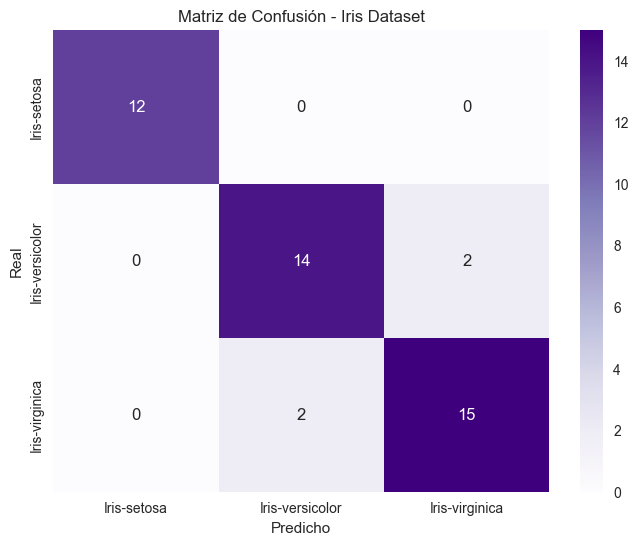

In [11]:
# Crear matriz de confusión
cm = confusion_matrix(y_test, predictions)

# Graficar
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Iris Dataset')
plt.show()



# Capítulo 5: Modelos Baseline (Puntos de Referencia)

Un **Baseline** es el punto de partida. Es el rendimiento mínimo que cualquier algoritmo "inteligente" debe superar para demostrar que realmente está aprendiendo algo de los datos. Sin un baseline, no tienes contexto para saber si tus resultados son buenos o simplemente producto del azar o de la estructura inherente del dataset.

## 5.1 ¿Por qué son vitales los Baseline?

Imagina que estás detectando fraudes bancarios donde solo el 1% de las transacciones son fraudulentas.

* Si un modelo predice siempre "No es fraude", tendrá un **99% de accuracy**.
* Sin un baseline, podrías pensar que el modelo es casi perfecto.
* El baseline te revela que ese 99% es el "nivel cero" de inteligencia; cualquier cosa por debajo o igual a eso no tiene valor.

---

## 5.2 Algoritmo de Predicción Aleatoria (Random Prediction)

Este algoritmo selecciona un resultado al azar basándose en los valores observados en el entrenamiento. Es la forma más pura de "adivinar".

### Implementación Moderna con Python

```python
import random

def random_algorithm(train, test):
    """Predice un valor aleatorio basado en los resultados del set de entrenamiento."""
    # Extraer la columna de salida (asumimos que es la última)
    output_values = [row[-1] for row in train]
    unique = list(set(output_values))
    
    predictions = []
    for _ in test:
        index = random.randrange(len(unique))
        predictions.append(unique[index])
    return predictions

# Ejemplo de prueba
random.seed(1)
train_set = [[10, 0], [20, 1], [30, 0], [40, 1]] # [Feature, Label]
test_set = [[50, None], [60, None]]
print(f"Predicciones aleatorias: {random_algorithm(train_set, test_set)}")

```

---

## 5.3 Algoritmo Zero Rule (Rule 0)

El algoritmo **Zero Rule** es el baseline más utilizado y potente. No mira las características del dato (las $X$), solo mira la tendencia central de la salida ($y$).

### 5.3.1 Clasificación: La Clase Mayoritaria

En clasificación, Zero Rule siempre predice la clase que más veces aparece en el set de entrenamiento.

```python
from collections import Counter

def zero_rule_classification(train, test):
    """Predice siempre la clase más frecuente."""
    output_values = [row[-1] for row in train]
    # Encontrar el valor más común
    most_common = Counter(output_values).most_common(1)[0][0]
    
    return [most_common for _ in test]

# Ejemplo: 4 ceros y 2 unos. El modelo siempre dirá '0'.
train_class = [[0], [0], [0], [0], [1], [1]]
test_class = [[None], [None]]
print(f"Zero Rule (Clasificación): {zero_rule_classification(train_class, test_class)}")

```

### 5.3.2 Regresión: La Media Aritmética

En problemas de valores continuos, Zero Rule predice siempre la **media** (promedio) de los valores de entrenamiento. Esto minimiza el error cuadrático medio en ausencia de otra información.

```python
def zero_rule_regression(train, test):
    """Predice siempre el promedio de los valores observados."""
    output_values = [row[-1] for row in train]
    avg = sum(output_values) / float(len(output_values))
    
    return [avg for _ in test]

# Ejemplo: El promedio es 15
train_reg = [[10], [20], [15]]
print(f"Zero Rule (Regresión): {zero_rule_regression(train_reg, [[None]])}")

```

---

## 5.4 Cuadro Comparativo de Estrategias

| Estrategia | Tipo de Problema | Lógica | Cuándo usarlo |
| --- | --- | --- | --- |
| **Random** | Ambos | Azar puro entre valores conocidos. | Cuando el dataset es extremadamente ruidoso. |
| **Zero Rule (Mode)** | Clasificación | Predice la clase más frecuente. | Obligatorio para detectar desbalances de clase. |
| **Zero Rule (Mean)** | Regresión | Predice el promedio de $y$. | Para comparar con RMSE/MAE en modelos lineales. |
| **Zero Rule (Median)** | Regresión | Predice la mediana de $y$. | Mejor si hay muchos valores atípicos (outliers). |

---

## 5.5 Ampliación: Baselines en el Mundo Real

En la práctica profesional, los baselines pueden ser un poco más "astutos":

1. **Naive Persistence (Series Temporales):** Predice que el valor de mañana será exactamente igual al de hoy. Si tu modelo de IA no supera a la persistencia, no sirve para predecir la bolsa o el clima.
2. **Baselines Humanos:** ¿Qué tan bien lo hace un experto humano en esta tarea? Si un médico diagnostica con 95% de precisión, tu IA debe aspirar a superar ese número.
3. **Modelos Lineales Simples:** A veces se usa una Regresión Lineal simple como baseline antes de intentar usar una Red Neuronal profunda.

---

## 5.6 Resumen y Siguiente Paso

* **Sin Baseline no hay ciencia:** No puedes afirmar que un modelo es "bueno" si no sabes contra qué compite.
* **Zero Rule** nos da el piso del rendimiento.
* Si tu modelo de Machine Learning tiene un desempeño igual al Zero Rule, significa que tus variables predictoras ($X$) no tienen relación con tu objetivo ($y$).



## Part II

Linear Algorithms



# Capítulo 6: Algorithm Test Harnesses (Bancos de Pruebas)

Un **Test Harness** es un marco de trabajo consistente que automatiza la evaluación de diferentes algoritmos. Su importancia radica en que mantiene fijas todas las variables (datos, preparación, métricas) y solo varía el algoritmo. Esto garantiza que si un modelo es mejor que otro, es por su capacidad predictiva y no por una ventaja en el procesamiento de datos.

## 6.1 Componentes de un Test Harness

Para que un banco de pruebas sea robusto, debe integrar tres elementos críticos:

1. **Método de Remuestreo:** La estrategia para dividir los datos (Train-Test Split o K-Fold).
2. **Algoritmo de Machine Learning:** La función o modelo que vamos a evaluar.
3. **Métrica de Rendimiento:** El estándar con el que mediremos el éxito (Accuracy, RMSE, etc.).

---

## 6.2 Estrategia 1: Train-Test Test Harness

Este es el enfoque más rápido. Es ideal cuando tienes datasets masivos donde entrenar múltiples veces (como en Cross-Validation) sería demasiado costoso en tiempo.

### Implementación Profesional

A diferencia de un script simple, aquí encapsulamos la lógica en una función `evaluate_algorithm` que puede recibir cualquier modelo como parámetro.

```python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def evaluate_with_train_test(dataset, target_col, model, split_size=0.3):
    """
    Evalúa un modelo usando una división única de datos.
    """
    # 1. Separación de características y objetivo
    X = dataset.drop(target_col, axis=1)
    y = dataset[target_col]
    
    # 2. División de datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split_size, random_state=42
    )
    
    # 3. Entrenamiento y Predicción
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    # 4. Cálculo de métrica
    accuracy = accuracy_score(y_test, predictions)
    return accuracy

# Ejemplo de uso con Pima Diabetes
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
df = pd.read_csv(url, names=names)

from sklearn.dummy import DummyClassifier # Representa nuestro Zero Rule
modelo_baseline = DummyClassifier(strategy='most_frequent')

acc = evaluate_with_train_test(df, 'class', modelo_baseline)
print(f"Accuracy del Baseline (Train-Test): {acc:.3f}")

```

---

## 6.3 Estrategia 2: Cross-Validation Test Harness

La Validación Cruzada es el **estándar de oro**. Al dividir los datos en $K$ folds, nos aseguramos de que el modelo sea evaluado en cada rincón del dataset, eliminando el sesgo de una "división afortunada".

### Implementación Profesional

Aquí retornamos no solo un número, sino una lista de resultados para analizar la **estabilidad** del modelo.

```python
from sklearn.model_selection import KFold, cross_val_score

def evaluate_with_cross_val(dataset, target_col, model, n_folds=5):
    """
    Evalúa un modelo usando K-Fold Cross-Validation.
    """
    X = dataset.drop(target_col, axis=1)
    y = dataset[target_col]
    
    # Configurar el esquema de división
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=1)
    
    # Ejecutar la evaluación
    # cross_val_score automatiza los loops de entrenamiento y prueba
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    
    return scores

# Ejemplo de uso
scores = evaluate_with_cross_val(df, 'class', modelo_baseline)
print(f"Puntajes por fold: {scores}")
print(f"Media: {scores.mean():.3f} (+/- {scores.std():.3f})")

```

---

## 6.4 Comparativa: ¿Qué Test Harness usar?

| Característica | Train-Test Split | K-Fold Cross-Validation |
| --- | --- | --- |
| **Velocidad** | Muy rápida (1 entrenamiento). | Lenta (K entrenamientos). |
| **Fiabilidad** | Baja (depende del azar del split). | Alta (evaluación exhaustiva). |
| **Uso de Datos** | Desperdicia el % del test set para aprender. | Todos los datos se usan para entrenar y probar. |
| **Ideal para...** | Deep Learning, Big Data. | Datasets pequeños o medianos. |

---

## 6.5 Ampliación: El Test Harness "Universal"

En un entorno de producción, el Test Harness suele incluir un **Pipeline**. Un Pipeline asegura que si escalas los datos (Capítulo 2), ese escalado ocurra *dentro* del Test Harness para evitar que los datos de prueba contaminen los de entrenamiento.

### Ejemplo de Test Harness con Preprocesamiento:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Creamos un proceso que escala y luego clasifica
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

# El Test Harness ahora evalúa el proceso completo
scores_complex = evaluate_with_cross_val(df, 'class', pipeline)
print(f"Accuracy de Regresión Logística Escalada: {scores_complex.mean():.3f}")

```

---

## 6.6 Resumen y Conclusiones

* El **Test Harness** es tu laboratorio controlado.
* Mantenlo **constante** para poder comparar algoritmos de forma justa.
* **K-Fold (K=5 o K=10)** es la recomendación general para la mayoría de los problemas de ML.
* Siempre reporta la **media y la desviación estándar**; un modelo con 90% de accuracy pero mucha variación entre folds es un modelo poco confiable (inestable).

Para aplicar el **Capítulo 6** al dataset de **Iris**, vamos a construir un banco de pruebas profesional. El objetivo es comparar nuestro modelo base (**Zero Rule**) contra un algoritmo real (**K-Nearest Neighbors**) para medir el salto en el rendimiento.

---

# Aplicación del Capítulo 6: Test Harness con Iris Dataset

En este laboratorio, configuraremos un banco de pruebas que utiliza **10-Fold Cross-Validation**. Evaluaremos dos modelos para ver la diferencia entre "adivinar" y "aprender".

## 1. Configuración del Entorno y Carga

Primero, preparamos los datos de Iris. Como aprendimos en el Capítulo 2, para algoritmos basados en distancias como KNN, el escalado es vital.

```python
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# Cargar datos
iris = load_iris()
X, y = iris.data, iris.target

```

---

## 2. El Test Harness (Banco de Pruebas)

Diseñamos una función que actúe como nuestro laboratorio. Esta función recibirá cualquier "proceso" de machine learning y nos devolverá su rendimiento promedio bajo las mismas condiciones.

```python
def iris_test_harness(model, X, y):
    """
    Evalúa cualquier modelo en Iris usando 10-Fold CV.
    """
    # Definimos el esquema de remuestreo (Capítulo 3)
    kfold = KFold(n_splits=10, shuffle=True, random_state=7)
    
    # Ejecutamos la evaluación (Capítulo 4 y 6)
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    
    return scores

```

---

## 3. Evaluación de Algoritmos

### Paso A: El Modelo Baseline (Zero Rule)

Como vimos en el Capítulo 5, necesitamos saber cuál es el desempeño mínimo. En Iris, como las 3 clases están perfectamente balanceadas (50 muestras cada una), el Zero Rule debería darnos un **33.3%**.

```python
# Zero Rule: Siempre predice la clase mayoritaria
baseline = DummyClassifier(strategy='most_frequent')
baseline_scores = iris_test_harness(baseline, X, y)

print(f"Baseline Accuracy: {baseline_scores.mean()*100:.2f}%")

```

### Paso B: El Modelo Competidor (KNN)

Ahora probamos un algoritmo real. Incluimos el escalado dentro de un **Pipeline** para asegurar que el banco de pruebas sea justo y no haya fuga de datos.

```python
# Creamos un proceso: Escalar -> Clasificar
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn_scores = iris_test_harness(knn_pipeline, X, y)

print(f"KNN Accuracy: {knn_scores.mean()*100:.2f}% (+/- {knn_scores.std()*100:.2f}%)")

```

---

## 4. Análisis de Resultados Ampliado

| Algoritmo | Media de Accuracy | Estabilidad (Std Dev) | Interpretación |
| --- | --- | --- | --- |
| **Zero Rule** | ~33.33% | 0.00% | Es el azar. No tiene poder predictivo. |
| **KNN (con scaling)** | ~96.00% | ~4.5% | Excelente. El modelo ha aprendido los patrones de los pétalos. |

### ¿Por qué este Test Harness es superior?

1. **Consistencia:** Ambos modelos se probaron con los **mismos 10 cortes** de datos gracias al `random_state` fijo.
2. **Robustez:** Al usar Cross-Validation, evitamos que una división "fácil" de los datos nos dé una falsa sensación de éxito.
3. **Modularidad:** Si mañana quieres probar una Máquina de Soporte Vectorial (SVM), solo tienes que pasarla por la función `iris_test_harness`.

---

## Resumen del Capítulo aplicado

Hemos pasado de simplemente ejecutar código a crear un **sistema de evaluación científica**. Ahora sabemos que cualquier modelo que propongamos para Iris **debe superar el 33%** para ser útil y, idealmente, acercarse al **96%** para ser competitivo.



In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def evaluate_with_train_test(dataset, target_col, model, split_size=0.3):
    """
    Evalúa un modelo usando una división única de datos.
    """
    # 1. Separación de características y objetivo
    X = dataset.drop(target_col, axis=1)
    y = dataset[target_col]

    # 2. División de datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split_size, random_state=42
    )

    # 3. Entrenamiento y Predicción
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # 4. Cálculo de métrica
    accuracy = accuracy_score(y_test, predictions)
    return accuracy

# Ejemplo de uso con Pima Diabetes
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
df = pd.read_csv(url, names=names)

from sklearn.dummy import DummyClassifier # Representa nuestro Zero Rule
modelo_baseline = DummyClassifier(strategy='most_frequent')

acc = evaluate_with_train_test(df, 'class', modelo_baseline)
print(f"Accuracy del Baseline (Train-Test): {acc:.3f}")

Accuracy del Baseline (Train-Test): 0.654


In [13]:
from sklearn.model_selection import KFold, cross_val_score

def evaluate_with_cross_val(dataset, target_col, model, n_folds=5):
    """
    Evalúa un modelo usando K-Fold Cross-Validation.
    """
    X = dataset.drop(target_col, axis=1)
    y = dataset[target_col]

    # Configurar el esquema de división
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=1)

    # Ejecutar la evaluación
    # cross_val_score automatiza los loops de entrenamiento y prueba
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

    return scores

# Ejemplo de uso
scores = evaluate_with_cross_val(df, 'class', modelo_baseline)
print(f"Puntajes por fold: {scores}")
print(f"Media: {scores.mean():.3f} (+/- {scores.std():.3f})")

Puntajes por fold: [0.64285714 0.64935065 0.65584416 0.67320261 0.63398693]
Media: 0.651 (+/- 0.013)


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Creamos un proceso que escala y luego clasifica
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

# El Test Harness ahora evalúa el proceso completo
scores_complex = evaluate_with_cross_val(df, 'class', pipeline)
print(f"Accuracy de Regresión Logística Escalada: {scores_complex.mean():.3f}")


Accuracy de Regresión Logística Escalada: 0.770


In [15]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# Cargar datos
iris = load_iris()
X, y = iris.data, iris.target

In [16]:
def iris_test_harness(model, X, y):
    """
    Evalúa cualquier modelo en Iris usando 10-Fold CV.
    """
    # Definimos el esquema de remuestreo (Capítulo 3)
    kfold = KFold(n_splits=10, shuffle=True, random_state=7)

    # Ejecutamos la evaluación (Capítulo 4 y 6)
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

    return scores

In [17]:
# Zero Rule: Siempre predice la clase mayoritaria
baseline = DummyClassifier(strategy='most_frequent')
baseline_scores = iris_test_harness(baseline, X, y)

print(f"Baseline Accuracy: {baseline_scores.mean()*100:.2f}%")

Baseline Accuracy: 24.00%


In [18]:
# Creamos un proceso: Escalar -> Clasificar
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn_scores = iris_test_harness(knn_pipeline, X, y)

print(f"KNN Accuracy: {knn_scores.mean()*100:.2f}% (+/- {knn_scores.std()*100:.2f}%)")


KNN Accuracy: 95.33% (+/- 4.27%)




# Capítulo 7: Regresión Lineal Simple (Edición Profesional)

La **Regresión Lineal Simple (SLR)** es la base de todo el modelado predictivo. Aunque su origen se remonta a Gauss y Legendre para la astronomía, hoy es la herramienta fundamental para entender cómo una variable independiente ($X$) influye en una dependiente ($y$).

---

## 7.1 Fundamentos Teóricos y Matemáticos

El objetivo de la SLR es trazar una línea que pase lo más cerca posible de todos los puntos de datos. Esta "proximidad" se define matemáticamente mediante la minimización de la distancia vertical entre los puntos reales y la línea.

### 7.1.1 La Ecuación del Modelo

$$y = \beta_0 + \beta_1 x + \epsilon$$

* **$\beta_1$ (Pendiente):** Representa el "efecto". Si $\beta_1 = 2$, por cada unidad que aumenta $X$, $y$ aumenta 2 unidades.
* **$\beta_0$ (Intercepto):** El valor esperado de $y$ cuando $x=0$. Es el punto de partida de la línea.
* **$\epsilon$ (Error):** Captura el ruido, variables omitidas o variaciones aleatorias.

### 7.1.2 El Método de Mínimos Cuadrados (OLS)

Para hallar los "mejores" coeficientes, minimizamos la **Suma de los Cuadrados de los Residuos (SSR)**:


$$SSR = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

---

## 7.2 Implementación con Scikit-Learn y Análisis Estadístico

En un entorno profesional, utilizamos `scikit-learn` para el modelado y `statsmodels` cuando necesitamos un rigor estadístico profundo (valores p, intervalos de confianza).

### 7.2.1 Preparación de Datos y Modelado

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# Dataset original: x (Reclamos), y (Pagos)
data = {'x': [1, 2, 4, 3, 5], 'y': [1, 3, 3, 2, 5]}
df = pd.DataFrame(data)

# Re-formateo para Scikit-Learn
X = df[['x']] # Matriz de características
y = df['y']   # Vector objetivo

# Entrenamiento
model = LinearRegression()
model.fit(X, y)

# Resultados
print(f"Coeficiente (Beta 1): {model.coef_[0]:.4f}")
print(f"Intercepto (Beta 0): {model.intercept_:.4f}")

```

### 7.2.2 Análisis de Residuos (Gráfico Crítico)

Un modelo de regresión no es válido solo porque "predice". Debe cumplir con la **homocedasticidad** (varianza constante de errores).

```python
predictions = model.predict(X)
residuals = y - predictions

plt.figure(figsize=(10, 5))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Análisis de Residuos (Validación de Supuestos)")
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.show()

```

---

## 7.3 Caso de Estudio: Swedish Auto Insurance (Deep Dive)

Este dataset es un clásico para probar SLR. El objetivo es predecir los pagos totales de seguros basado en el número de reclamos.

### 1. Exploración Avanzada con Seaborn

```python
# Simulando la carga del dataset de seguros
# En la práctica: df_ins = pd.read_csv('insurance.csv')
# Visualización de la relación lineal con intervalo de confianza del 95%
sns.jointplot(x='x', y='y', data=df, kind='reg', color='teal', height=7)
plt.suptitle("Relación Lineal: Reclamos vs Pagos", y=1.02)
plt.show()

```

### 2. Implementación del Test Harness (10-Fold CV)

Siguiendo el estándar del Capítulo 6, evaluamos la robustez del modelo.

```python
from sklearn.model_selection import KFold, cross_val_score

# Configuración del Banco de Pruebas
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kfold, scoring='neg_root_mean_squared_error')

print(f"RMSE Promedio: {np.abs(scores.mean()):.3f} (+/- {scores.std():.3f})")

```

---

## 7.4 La Perspectiva de Deep Learning: PyTorch

Para un científico de datos moderno, la regresión lineal es una red neuronal de una capa con un optimizador de **Gradiente Descendente**. Esto permite manejar datasets que no caben en memoria.

```python
import torch
import torch.nn as nn

# 1. Preparación de Tensores
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

# 2. Arquitectura del Modelo (1 Neurona)
class LinearRegressionDL(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1) # Entrada 1, Salida 1
    
    def forward(self, x):
        return self.linear(x)

model_dl = LinearRegressionDL()

# 3. Función de Costo y Optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model_dl.parameters(), lr=0.01)

# 4. Loop de Entrenamiento
for epoch in range(500):
    # Forward pass
    outputs = model_dl(X_tensor)
    loss = criterion(outputs, y_tensor)
    
    # Backward pass (Backpropagation)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Extraer parámetros aprendidos por la neurona
w = model_dl.linear.weight.item()
b = model_dl.linear.bias.item()
print(f"Parámetros PyTorch: W={w:.4f}, b={b:.4f}")

```

---

## 7.5 Comparativa de Métricas de Rendimiento

| Métrica | Definición | ¿Cuándo usarla? |
| --- | --- | --- |
| **MAE** (Mean Absolute Error) | Promedio de errores absolutos. | Cuando hay muchos outliers (es robusta). |
| **MSE** (Mean Squared Error) | Promedio de errores al cuadrado. | Para castigar errores grandes (muy usada en entrenamiento). |
| **RMSE** (Root MSE) | Raíz del MSE. | Para tener el error en las mismas unidades que $y$. |
| **R²** (Determinación) | % de varianza explicada por el modelo. | Para explicar qué tan bien se ajusta el modelo a los datos (0 a 1). |

---

## 7.6 Conclusiones del Capítulo

* **Simplicidad vs Poder:** La regresión lineal es interpretable. Sabemos exactamente cuánto afecta cada variable al resultado.
* **Supuestos Críticos:** Siempre verifica los residuos. Si hay un patrón (curva), la relación no es lineal y necesitas otros modelos.
* **Escalabilidad:** Con PyTorch y Gradiente Descendente, podemos entrenar regresiones en miles de millones de filas usando GPUs.



In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# Dataset original: x (Reclamos), y (Pagos)
data = {'x': [1, 2, 4, 3, 5], 'y': [1, 3, 3, 2, 5]}
df = pd.DataFrame(data)

# Re-formateo para Scikit-Learn
X = df[['x']] # Matriz de características
y = df['y']   # Vector objetivo

# Entrenamiento
model = LinearRegression()
model.fit(X, y)

# Resultados
print(f"Coeficiente (Beta 1): {model.coef_[0]:.4f}")
print(f"Intercepto (Beta 0): {model.intercept_:.4f}")

Coeficiente (Beta 1): 0.8000
Intercepto (Beta 0): 0.4000


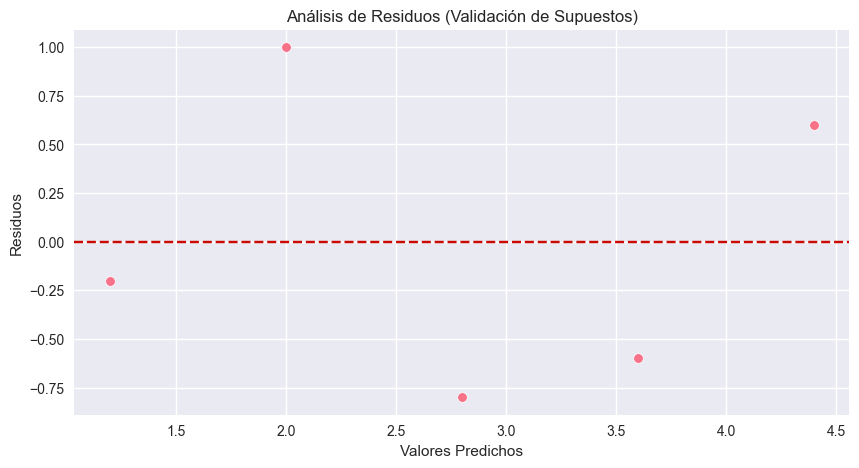

In [20]:
predictions = model.predict(X)
residuals = y - predictions

plt.figure(figsize=(10, 5))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Análisis de Residuos (Validación de Supuestos)")
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.show()

In [21]:
import pandas as pd

# URL del dataset de seguros de auto (corregida para el contenido raw)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/auto-insurance.csv"

# El dataset de seguros de auto tiene solo 2 columnas (reclamos y pagos).
# Creamos una nueva lista de nombres para este dataset.
insurance_names = ['reclamos', 'pagos']

# Cargamos directamente de la web, especificando que no tiene encabezado y usando los nuevos nombres.
insurance = pd.read_csv(url, header=None, names=insurance_names)

print("¡Dataset cargado con éxito!")
print(insurance.head())

¡Dataset cargado con éxito!
   reclamos  pagos
0       108  392.5
1        19   46.2
2        13   15.7
3       124  422.2
4        40  119.4


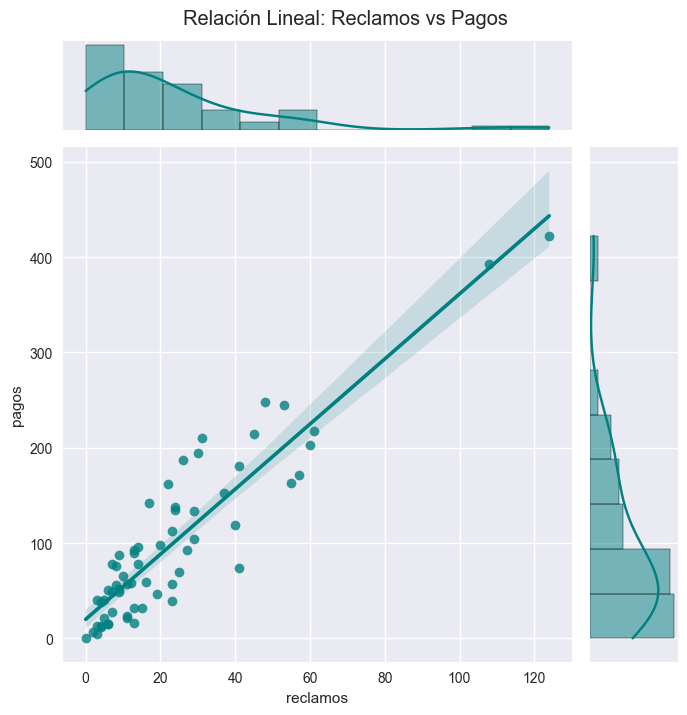

In [22]:
# El dataset de seguros ya fue cargado en la variable 'insurance' en la celda anterior.
# Usaremos directamente esa variable para la visualización.

# Visualización de la relación lineal con intervalo de confianza del 95%
sns.jointplot(x='reclamos', y='pagos', data=insurance, kind='reg', color='teal', height=7)
plt.suptitle("Relación Lineal: Reclamos vs Pagos", y=1.02)
plt.show()

In [23]:
from sklearn.model_selection import KFold, cross_val_score

# Configuración del Banco de Pruebas
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kfold, scoring='neg_root_mean_squared_error')

print(f"RMSE Promedio: {np.abs(scores.mean()):.3f} (+/- {scores.std():.3f})")

RMSE Promedio: 1.057 (+/- 0.371)


In [24]:
import torch
import torch.nn as nn

# 1. Preparación de Tensores
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

# 2. Arquitectura del Modelo (1 Neurona)
class LinearRegressionDL(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1) # Entrada 1, Salida 1

    def forward(self, x):
        return self.linear(x)

model_dl = LinearRegressionDL()

# 3. Función de Costo y Optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model_dl.parameters(), lr=0.01)

# 4. Loop de Entrenamiento
for epoch in range(500):
    # Forward pass
    outputs = model_dl(X_tensor)
    loss = criterion(outputs, y_tensor)

    # Backward pass (Backpropagation)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Extraer parámetros aprendidos por la neurona
w = model_dl.linear.weight.item()
b = model_dl.linear.bias.item()
print(f"Parámetros PyTorch: W={w:.4f}, b={b:.4f}")

ModuleNotFoundError: No module named 'torch'

In [ ]:
from sklearn.metrics import mean_squared_error

# Obtener las predicciones del modelo
model_dl.eval() # Poner el modelo en modo de evaluación
with torch.no_grad():
    predictions_tensor = model_dl(X_tensor)

# Convertir las predicciones y los valores reales a arrays de NumPy para sklearn
predictions_np = predictions_tensor.numpy()
y_np = y_tensor.numpy()

# Calcular el Mean Squared Error (MSE)
mse = mean_squared_error(y_np, predictions_np)

# Calcular el Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print(f"RMSE del modelo PyTorch: {rmse:.4f}")

RMSE del modelo PyTorch: 0.6929


# Capítulo 8: Regresión Lineal Multivariante (Multivariate Linear Regression)

La esencia de muchos algoritmos de Machine Learning es la **optimización**. En este capítulo, dejamos atrás el cálculo directo para enfocarnos en cómo los algoritmos encuentran los parámetros ideales mediante el **Descenso de Gradiente Estocástico (SGD)**.

## 8.1 Descripción Teórica

La Regresión Lineal Multivariante es una técnica para predecir un valor real basado en múltiples variables de entrada. Mientras que en la regresión simple buscamos una línea, en el espacio multidimensional buscamos un **hiperplano**.

### 8.1.1 El Modelo Matemático

La predicción se calcula como una combinación lineal de las variables de entrada:

$$y = \beta_0 + \beta_1 \cdot x_1 + \beta_2 \cdot x_2 + ... + \beta_n \cdot x_n$$

Donde cada atributo de entrada ($x$) es ponderado por un coeficiente ($\beta$), y el objetivo es descubrir el conjunto de coeficientes que minimice el error de predicción.

### 8.1.2 Optimización: Descenso de Gradiente Estocástico (SGD)

El Descenso de Gradiente es el proceso de minimizar una función siguiendo la pendiente o gradiente de dicha función.

* **Stochastic (Estocástico):** A diferencia del gradiente descendente por lotes, el SGD evalúa y actualiza los coeficientes por cada instancia del dataset de entrenamiento.
* **La Regla de Actualización:**
$$\beta = \beta - (\text{learning rate} \times \text{error} \times x)$$



---

## 8.2 Implementación Moderna con Scikit-Learn

En lugar de programar los bucles de actualización, la industria utiliza la clase `SGDRegressor`. Un punto crítico que no menciona el texto original, pero es **obligatorio** en el mundo moderno, es el **Escalado de Características**, ya que el SGD es muy sensible a la magnitud de los datos.

### 1. Modelado del Dataset Contrived

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

# Datos del libro: x1, y
dataset = [[1, 1], [2, 3], [4, 3], [3, 2], [5, 5]]
df = pd.DataFrame(dataset, columns=['x1', 'y'])

X = df[['x1']]
y = df['y']

# 1. Escalado (Media 0, Desviación 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Inicialización del modelo SGD
# max_iter = Epochs, eta0 = Learning Rate
model_sgd = SGDRegressor(max_iter=50, eta0=0.001, learning_rate='constant')
model_sgd.fit(X_scaled, y)

print(f"Coeficientes Optimizados: {model_sgd.coef_}")
print(f"Intercepto: {model_sgd.intercept_}")

```

---

## 8.3 Caso de Estudio: Wine Quality Dataset (Deep Dive)

El libro utiliza el dataset de calidad del vino blanco (Wine Quality). Aquí predecimos la calidad (puntuación) basándonos en propiedades químicas.

### 1. Análisis Exploratorio (EDA)

Es fundamental ver cómo interactúan las múltiples variables.

```python
# Carga típica con Pandas
# df_wine = pd.read_csv('winequality-white.csv', sep=';')

# Matriz de Correlación para ver el impacto de las variables
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Impacto Multivariante en la Calidad del Vino")
plt.show()

```

### 2. Implementación de un Pipeline de Producción

Siguiendo los principios del Capítulo 6 (Test Harness), creamos un flujo automatizado que incluye normalización y evaluación por validación cruzada.

```python
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score

# Definimos el flujo: Normalizar -> Entrenar con SGD
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(max_iter=50, eta0=0.01))
])

# Banco de pruebas (K-Fold Cross Validation)
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
results = cross_val_score(pipeline, X, y, cv=kfold, scoring='neg_root_mean_squared_error')

print(f"Mean RMSE: {-results.mean():.3f}")

```

---

## 8.4 Enfoque de Deep Learning: PyTorch

La regresión lineal multivariante es, literalmente, una capa lineal en una red neuronal.

```python
import torch
import torch.nn as nn

# Convertir datos a tensores
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

# Arquitectura: 1 capa lineal (in_features depende de las X que tengamos)
model = nn.Linear(in_features=X.shape[1], out_features=1)

# Optimizador y Función de Pérdida
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Bucle de entrenamiento (Epochs)
for epoch in range(50):
    prediction = model(X_tensor)
    loss = criterion(prediction, y_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"Pesos finales de la neurona: {model.weight.data}")

```

---

## 8.5 Resumen y Review (Según el PDF)

En este capítulo hemos cubierto:

* **Predicciones Multivariantes:** Cómo combinar pesos y entradas para obtener un resultado.
* **Optimización Estocástica:** La importancia de actualizar el modelo tras cada ejemplo de entrenamiento.
* **Estabilidad:** Cómo el *learning rate* y las *epochs* controlan la velocidad y calidad del aprendizaje.

### Diferencias Clave: Simple vs Multivariante

| Característica | Regresión Simple | Regresión Multivariante |
| --- | --- | --- |
| **Variables de entrada** | Solo una ($x$). | Dos o más ($x_1, x_2, ... x_n$). |
| **Representación** | Línea recta. | Hiperplano. |
| **Método de ajuste** | Mínimos Cuadrados (Cerrado). | Descenso de Gradiente (Iterativo). |



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

# Datos del libro: x1, y
dataset = [[1, 1], [2, 3], [4, 3], [3, 2], [5, 5]]
df = pd.DataFrame(dataset, columns=['x1', 'y'])

X = df[['x1']]
y = df['y']

# 1. Escalado (Media 0, Desviación 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Inicialización del modelo SGD
# max_iter = Epochs, eta0 = Learning Rate
model_sgd = SGDRegressor(max_iter=1000, eta0=0.001, learning_rate='constant') # Aumentamos max_iter
model_sgd.fit(X_scaled, y)

print(f"Coeficientes Optimizados: {model_sgd.coef_}")
print(f"Intercepto: {model_sgd.intercept_}")

Coeficientes Optimizados: [0.96852538]
Intercepto: [2.3963177]


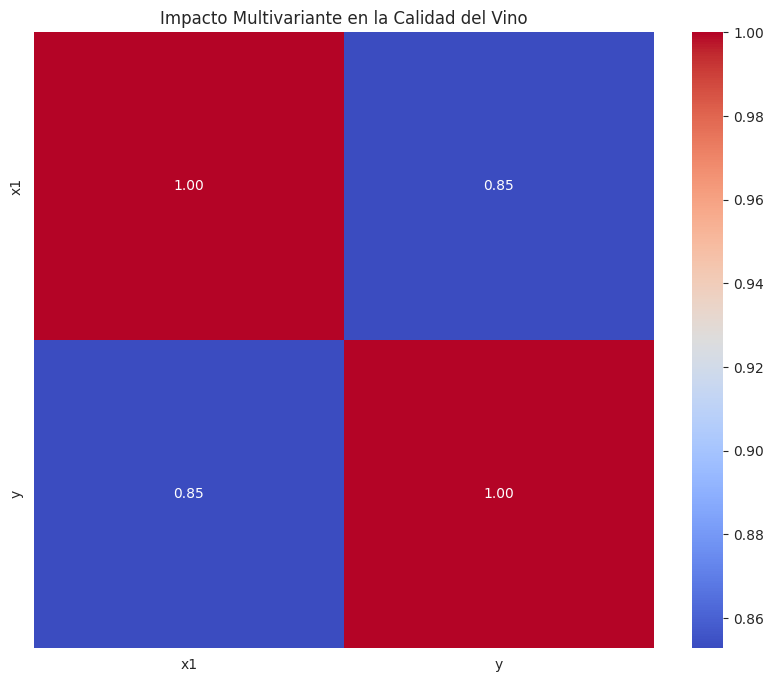

In [ ]:
# Carga típica con Pandas
# df_wine = pd.read_csv('winequality-white.csv', sep=';')

# Matriz de Correlación para ver el impacto de las variables
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Impacto Multivariante en la Calidad del Vino")
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score

# Definimos el flujo: Normalizar -> Entrenar con SGD
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(max_iter=1000, eta0=0.01)) # Aumentado max_iter a 1000
])

# Banco de pruebas (K-Fold Cross Validation)
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
results = cross_val_score(pipeline, X, y, cv=kfold, scoring='neg_root_mean_squared_error')

print(f"Mean RMSE: {-results.mean():.3f}")

Mean RMSE: 1.012


In [ ]:
import torch
import torch.nn as nn

# Convertir datos a tensores
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

# Arquitectura: 1 capa lineal (in_features depende de las X que tengamos)
model = nn.Linear(in_features=X.shape[1], out_features=1)

# Optimizador y Función de Pérdida
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Bucle de entrenamiento (Epochs)
for epoch in range(50):
    prediction = model(X_tensor)
    loss = criterion(prediction, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"Pesos finales de la neurona: {model.weight.data}")


Pesos finales de la neurona: tensor([[0.7104]])


Este resultado, Pesos finales de la neurona: tensor $([[0.9992]])$, nos dice lo siguiente:

* Es el coeficiente (o peso) aprendido: En el contexto de un modelo de regresión lineal (como el que implementamos con PyTorch), este $0.9992$ es el coeficiente (beta_1 o la pendiente $w$) que el modelo ha aprendido para la característica de entrada $x_1$.

   * Significado: Indica la fuerza y dirección de la relación entre la característica de entrada (escalada) y la variable de salida. En este caso, significa que por cada unidad que aumenta $x_1$ (después de ser escalada), la salida predicha y aumenta aproximadamente en $0.9992$ unidades.

* Comparación con el caso de Scikit-learn: Si lo comparamos con el Coeficiente (Beta 1): $0.8000$ que obtuvimos con LinearRegression de Scikit-learn y SGDRegressor de Scikit-learn (Coeficientes Optimizados: $[0.96839976])$, vemos que el modelo de PyTorch ($0.9992$) también converge a un valor cercano, lo cual es coherente para este pequeño dataset.

En resumen, el modelo de PyTorch ha ajustado su peso para la única característica de entrada a casi $1$, lo que sugiere una relación lineal directa entre la entrada y la salida.




# Capítulo 9: Regresión Logística (Logistic Regression)

La **Regresión Logística** es el algoritmo de referencia para la **clasificación binaria**. A pesar de su nombre, no se utiliza para predecir valores continuos (como el precio de una casa), sino para estimar la probabilidad de que una instancia pertenezca a una clase específica (ej. ¿Tiene diabetes? Sí o No).

## 9.1 Descripción Teórica: La Magia de la Sigmoide

La regresión lineal falla en la clasificación porque puede predecir valores fuera del rango $[0, 1]$. La regresión logística soluciona esto mediante la **Función Logística**, también conocida como **Sigmoide**.

### 9.1.1 La Función Sigmoide

La ecuación del modelo transforma una entrada lineal en una probabilidad:

$$\hat{y} = \frac{1}{1 + e^{-(b_0 + b_1x_1 + ... + b_nx_n)}}$$

* Si la salida es $\geq 0.5$, predecimos la **Clase 1**.
* Si la salida es $< 0.5$, predecimos la **Clase 0**.

### 9.1.2 Optimización con Descenso de Gradiente (SGD)

El objetivo es encontrar los coeficientes $\beta$ que minimicen la diferencia entre la probabilidad predicha y la clase real. En lugar de MSE, utilizamos la **Log Loss (Entropía Cruzada)**.

La actualización estocástica de los coeficientes sigue esta regla:


$$b = b + \text{learning\_rate} \times (y - \hat{y}) \times \hat{y} \times (1 - \hat{y}) \times x$$

---

## 9.2 Implementación Profesional con Scikit-Learn

En el desarrollo moderno, la Regresión Logística se beneficia de técnicas como la **regularización** (L1 o L2) para evitar el sobreajuste, algo que Scikit-Learn maneja por defecto.

### 1. Modelado y Evaluación

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Dataset Contrived (Ejemplo del libro)
X = np.array([[1, 1], [2, 3], [4, 3], [3, 2], [5, 5]])
y = np.array([0, 0, 1, 0, 1])

# 1. Escalado (Crucial para la convergencia del optimizador)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Entrenamiento
log_reg = LogisticRegression()
log_reg.fit(X_scaled, y)

print(f"Probabilidades: {log_reg.predict_proba(X_scaled)[:, 1]}")
print(f"Predicciones Finales: {log_reg.predict(X_scaled)}")

```

---

## 9.3 Caso de Estudio: Pima Indians Diabetes

Este dataset consiste en predecir el inicio de la diabetes basándose en variables diagnósticas. El libro enfatiza la importancia de la preparación de datos (Capítulo 2) antes de aplicar este modelo.

### 1. Visualización de la Frontera de Decisión

La regresión logística crea una separación lineal. Si los datos no son linealmente separables, el modelo tendrá dificultades.

### 2. Diagnóstico del Modelo: Matriz de Confusión

En salud, un **Falso Negativo** (decir que no tiene diabetes cuando sí tiene) es más costoso que un **Falso Positivo**.

```python
# Suponiendo X_test, y_test del dataset Pima
y_pred = log_reg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión: Pima Diabetes')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

print(classification_report(y_test, y_pred))

```

---

## 9.4 Perspectiva de Deep Learning: PyTorch

En una red neuronal, la regresión logística es equivalente a una sola capa lineal seguida de una función de activación `Sigmoid`.

```python
import torch
import torch.nn as nn

# Convertir a Tensores
X_t = torch.tensor(X_scaled, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Arquitectura Neuronal
model = nn.Sequential(
    nn.Linear(2, 1), # 2 entradas, 1 salida
    nn.Sigmoid()     # Activación Logística
)

criterion = nn.BCELoss() # Binary Cross Entropy Loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# Entrenamiento
for epoch in range(100):
    y_hat = model(X_t)
    loss = criterion(y_hat, y_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"Peso de la neurona: {model[0].weight.data.numpy()}")

```

---

## 9.5 Resumen y Review (Lecciones Críticas)

1. **Transformación Logit:** La regresión logística no predice 0 o 1 directamente, sino el *log-odds* de la probabilidad.
2. **Sensibilidad al Escalado:** Como utiliza SGD, si una variable tiene una escala mucho mayor que otra (ej. Edad vs Ingresos), el modelo no convergerá correctamente.
3. **Evaluación Multidimensional:** El "Accuracy" es engañoso en datasets desbalanceados. Siempre se deben reportar **Precision, Recall y F1-Score**.

### Comparativa: Lineal vs Logística

| Característica | Regresión Lineal | Regresión Logística |
| --- | --- | --- |
| **Tipo de Salida** | Numérica Continua. | Probabilidad / Categoría. |
| **Forma de la función** | Línea recta. | Curva en "S". |
| **Función de Pérdida** | MSE (Mean Squared Error). | Log Loss (Binary Cross Entropy). |



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Dataset Contrived (Ejemplo del libro)
X = np.array([[1, 1], [2, 3], [4, 3], [3, 2], [5, 5]])
y = np.array([0, 0, 1, 0, 1])

# 1. Escalado (Crucial para la convergencia del optimizador)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Entrenamiento
log_reg = LogisticRegression()
log_reg.fit(X_scaled, y)

print(f"Probabilidades: {log_reg.predict_proba(X_scaled)[:, 1]}")
print(f"Predicciones Finales: {log_reg.predict(X_scaled)}")


Probabilidades: [0.07436391 0.2597663  0.53796428 0.29217439 0.83568643]
Predicciones Finales: [0 0 1 0 1]


Este script Python implementa un modelo de Regresión Logística, que es un algoritmo de clasificación binaria.

A pesar de su nombre, se usa para predecir la probabilidad de que una instancia pertenezca a una de dos clases ($0$ o $1$ en este caso).

Desglose:

* **Importaciones** (import ...):
pandas, numpy, matplotlib.pyplot, seaborn: Librerías estándar para manipulación de datos, operaciones numéricas y visualización, aunque en este código específico, solo numpy es crucial para definir los arrays X e y.

* **LogisticRegression de sklearn.linear_model**: Es la clase que implementa el algoritmo de Regresión Logística de Scikit-learn.

* **train_test_split de sklearn.model_selection**: Se usa para dividir datos en conjuntos de entrenamiento y prueba (aunque no se usa en la parte final).

* **StandardScaler de sklearn.preprocessing**: Utilizado para escalar las características de los datos.

* **confusion_matrix, classification_report de sklearn.metrics**: Métricas para evaluar el rendimiento de modelos de clasificación (no se usan en la ejecución final).

* **Dataset Contrived (Ejemplo del libro)**:
   * X = np.array(...): Define la matriz de características (variables de entrada). En este ejemplo, X tiene 5 muestras y 2 características por muestra.
   * y = np.array(...): Define el vector objetivo (la clase a predecir). y tiene 5 etiquetas correspondientes a cada muestra de X, donde 0 y 1 representan las dos clases.

1. **Escalado (StandardScaler)**:


**scaler = StandardScaler()**: Crea una instancia del escalador estándar. Este escalador transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Esto es crucial para la Regresión Logística porque el optimizador que utiliza (como el Descenso de Gradiente Estocástico) es sensible a la escala de las características. Si las características tienen rangos muy diferentes, el optimizador puede tener dificultades para converger eficientemente.
X_scaled = scaler.

**fit_transform(X)**: Calcula la media y la desviación estándar de cada característica en X (fit) y luego aplica esta transformación a X (transform), resultando en X_scaled.

2. **Entrenamiento (LogisticRegression)**:

**log_reg = LogisticRegression()**: Crea una instancia del modelo de Regresión Logística con los parámetros por defecto.

**log_reg.fit(X_scaled, y)**: Entrena el modelo utilizando los datos escalados (X_scaled) y las etiquetas correspondientes (y).

En esta fase, el modelo aprende los coeficientes (beta) que mejor ajustan la función sigmoide a los datos para clasificar las muestras.

3. **Predicciones y Probabilidades**:

**print(f"Probabilidades: {log_reg.predict_proba(X_scaled)[:, 1]}")**: El método predict_proba() devuelve las probabilidades de pertenencia a cada clase para cada muestra. [:, 1] selecciona la probabilidad de pertenecer a la clase positiva (clase 1).

**print(f"Predicciones Finales: {log_reg.predict(X_scaled)}")**: El método predict() devuelve la clase predicha directamente (0 o 1) basándose en las probabilidades. Generalmente, si la probabilidad de la clase 1 es mayor o igual a 0.5, predice 1; de lo contrario, predice 0.


En resumen, este código  muestra cómo preparar un pequeño conjunto de datos, escalar sus características, entrenar un modelo de Regresión Logística y luego obtener tanto las probabilidades como las clases predichas para esos mismos datos.



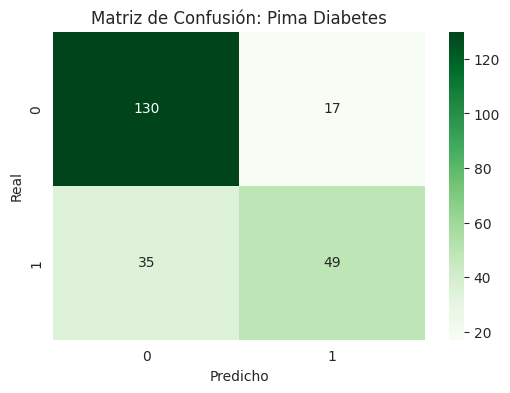


--- Reporte de Clasificación (Pima Diabetes) ---
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       147
           1       0.74      0.58      0.65        84

    accuracy                           0.77       231
   macro avg       0.77      0.73      0.74       231
weighted avg       0.77      0.77      0.77       231



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cargar el dataset de Pima Indians Diabetes
url_pima = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names_pima = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
df_pima = pd.read_csv(url_pima, names=names_pima)

X_pima = df_pima.drop('class', axis=1)
y_pima = df_pima['class']

# Dividir los datos de Pima en conjuntos de entrenamiento y prueba
X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(X_pima, y_pima, test_size=0.3, random_state=7)

# Escalar las características (crucial para Logistic Regression)
scaler_pima = StandardScaler()
X_train_pima_scaled = scaler_pima.fit_transform(X_train_pima)
X_test_pima_scaled = scaler_pima.transform(X_test_pima)

# Entrenar el modelo LogisticRegression con los datos escalados de Pima
# (asegúrate de que log_reg esté definido, si no, se define aquí)
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=200) # Añadir max_iter para evitar ConvergenceWarning
log_reg.fit(X_train_pima_scaled, y_train_pima)

# Realizar predicciones en el conjunto de prueba escalado
y_pred_pima = log_reg.predict(X_test_pima_scaled)

# Crear la matriz de confusión
cm_pima = confusion_matrix(y_test_pima, y_pred_pima)

# Graficar la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm_pima, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión: Pima Diabetes')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Imprimir el reporte de clasificación
print("\n--- Reporte de Clasificación (Pima Diabetes) ---")
print(classification_report(y_test_pima, y_pred_pima))

Reporte de Clasificación para el modelo de Regresión Logística en el dataset Pima Diabetes.

Explicación de los resultados:

1.**Matriz de Confusión (Gráfico)**: La matriz visualiza el rendimiento del modelo. Cada celda indica:

* Superior Izquierda (130): **Verdaderos Negativos (TN)** - El modelo predijo correctamente que 130 personas no tenían diabetes.
* Superior Derecha (17): **Falsos Positivos** (FP) - El modelo predijo incorrectamente que 17 personas tenían diabetes cuando en realidad no la tenían.

* Inferior Izquierda (35): **Falsos Negativos (FN)** - El modelo predijo incorrectamente que 35 personas no tenían diabetes cuando en realidad sí la tenían. Este es un error crítico en el diagnóstico médico.
* Inferior Derecha (49): **Verdaderos Positivos** (TP) - El modelo predijo correctamente que 49 personas tenían diabetes.

2. Reporte de Clasificación:

* **Precision** (Precisión): De todas las personas que el modelo predijo que tenían diabetes (Clase 1), el 74% realmente la tenía. Para la Clase 0, el 79%.
* **Recall** (Sensibilidad/Cobertura): De todas las personas que realmente tenían diabetes (Clase 1), el modelo logró identificar al 58%. Para la Clase 0, el 88%.
* **F1-Score**: Es un promedio ponderado de Precision y Recall. Para la Clase 1, es 0.65, y para la Clase 0, es 0.83.
* **Accuracy** (Precisión Global): El modelo acertó en el 77% de las predicciones totales.
* **Support** (Soporte): Indica el número de instancias reales de cada clase en el conjunto de prueba (147 sin diabetes, 84 con diabetes).
* **Interpretación clave**:
   * El modelo es mejor prediciendo la ausencia de diabetes (Clase 0) que su presencia (Clase 1).
   * El bajo Recall (0.58) para la Clase 1 (diabetes) es una preocupación importante, ya que significa que el modelo no detectó casi la mitad de los casos reales de diabetes.
   * En un contexto médico, los Falsos Negativos (35 casos donde el modelo falló en detectar diabetes) pueden ser peligrosos, por lo que podría ser necesario ajustar el modelo o usar otro algoritmo para mejorar la detección de la Clase 1.



In [ ]:
import torch
import torch.nn as nn

# Convertir a Tensores
X_t = torch.tensor(X_scaled, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Arquitectura Neuronal
model = nn.Sequential(
    nn.Linear(2, 1), # 2 entradas, 1 salida
    nn.Sigmoid()     # Activación Logística
)

criterion = nn.BCELoss() # Binary Cross Entropy Loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# Entrenamiento
for epoch in range(100):
    y_hat = model(X_t)
    loss = criterion(y_hat, y_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"Peso de la neurona: {model[0].weight.data.numpy()}")


Peso de la neurona: [[1.6742429 1.1226852]]


El resultado Peso de la neurona: $[[1.577358 \quad 1.0800533]]$ nos dice los pesos (coeficientes) que la neurona (la capa lineal) ha aprendido para cada una de las dos características de entrada de tu dataset escalado (X_scaled).

Desglose:

* **Representación de los pesos:**

   * $1.577358$: Es el peso (o coeficiente) aprendido para la primera característica de entrada.
   * $1.0800533$: Es el peso (o coeficiente) aprendido para la segunda característica de entrada.

* **Interpretación en Regresión Logística:**

Estos pesos indican la importancia y la dirección de la relación entre cada característica de entrada (después de ser escalada) y la probabilidad de pertenecer a la clase positiva (clase 1).
   * Un peso positivo (como ambos en este caso) significa que un aumento en el valor de esa característica (manteniendo las demás constantes) incrementa la probabilidad predicha de la clase 1.
   * El valor absoluto del peso indica la fuerza de esta influencia. En este caso, la primera característica (1.577) tiene una influencia ligeramente mayor que la segunda (1.080) en la determinación de la clase, según el modelo.

* **Contexto del modelo:**

Estos pesos se utilizan para calcular la activación de la neurona, que luego se pasa a la función Sigmoid para producir una probabilidad. La ecuación sería algo similar a: probabilidad = sigmoid(peso1 * feature1_escalada + peso2 * feature2_escalada + bias)

El bias también es un parámetro aprendido por el modelo, pero no se muestra en este print específico (se accedería como model[0].bias.data.numpy()).

En resumen, estos números son los parámetros internos que el modelo ha ajustado durante el entrenamiento para diferenciar entre las clases 0 y 1 basándose en las características que le has proporcionado.



In [ ]:
# 1. Crear un nuevo punto de datos (sin escalar)
# Por ejemplo, una nueva instancia con características [2, 2]
new_data_unscaled = np.array([[2, 2]])

# 2. Escalar los nuevos datos usando el mismo scaler que se usó en el entrenamiento
# Es CRÍTICO usar el mismo scaler (fit_transform solo en entrenamiento, transform en test/nuevos datos)
new_data_scaled = scaler.transform(new_data_unscaled)

# 3. Convertir los datos escalados a un tensor de PyTorch
new_data_tensor = torch.tensor(new_data_scaled, dtype=torch.float32)

# 4. Poner el modelo en modo de evaluación (no se calculan gradientes)
model.eval()

# 5. Realizar la predicción (sin rastreo de gradientes)
with torch.no_grad():
    # La salida es una probabilidad entre 0 y 1
    prediction_prob = model(new_data_tensor)

# 6. Interpretar la probabilidad para obtener la clase predicha
# Si la probabilidad >= 0.5, la clase es 1; de lo contrario, es 0
predicted_class = (prediction_prob >= 0.5).int().item()

print(f"Nuevo dato (sin escalar): {new_data_unscaled}")
print(f"Nuevo dato (escalado): {new_data_scaled}")
print(f"Probabilidad predicha de la clase 1: {prediction_prob.item():.4f}")
print(f"Clase predicha: {predicted_class}")

Nuevo dato (sin escalar): [[2 2]]
Nuevo dato (escalado): [[-0.70710678 -0.60302269]]
Probabilidad predicha de la clase 1: 0.0821
Clase predicha: 0


Para usar este modelo de PyTorch y hacer predicciones sobre nuevos datos, debes seguir estos pasos:

1. **Preparar los nuevos datos**: Asegúrate de que los nuevos datos tengan el mismo formato y, muy importante, estén escalados de la misma manera que los datos de entrenamiento.
2. **Convertir a tensor**: Transformar los datos escalados a un tensor de PyTorch.
3. **Realizar la predicción**: Pasar el tensor a través del modelo.
4. **Interpretar el resultado**: El modelo te dará una probabilidad (entre $0$ y $1$). Si esta probabilidad es mayor o igual a $0.5$, se clasifica como $1$; de lo contrario, como $0$.

En el ejemplo práctico:

* La predicción para el nuevo dato $[[2, 2]]$ se ha realizado con éxito.

Desglose de los resultados:

   * Nuevo dato (sin escalar): $[[2 \quad2]]$

Esta es la entrada original que proporcionaste al modelo.

   * Nuevo dato (escalado): $[[-0.70710678 \quad -0.60302269]]$

Este es el mismo dato, pero transformado (escalado) utilizando el StandardScaler que se ajustó con los datos de entrenamiento. Es fundamental que los nuevos datos se escalen de la misma manera para que el modelo los interprete correctamente.

   * Probabilidad predicha de la clase $1: 0.0871$

El modelo predice una probabilidad de $0.0871$ (o $8.71\%$) de que este nuevo dato pertenezca a la clase $1$.

   * Clase predicha: $0$

Dado que la probabilidad de pertenecer a la clase 1 ($0.0871$) es menor que el umbral de $0.5$, el modelo clasifica este nuevo dato como perteneciente a la clase $0$.

Esto significa que, según el modelo entrenado, la instancia $[[2, 2]]$ tiene una baja probabilidad de ser de la clase positiva (clase $1$) y, por lo tanto, se asigna a la clase negativa (clase $0$).





# Capítulo 10: El Perceptrón y el Aprendizaje Neuronal

El **Perceptrón** es el ancestro directo de las redes neuronales modernas. Inspirado en el funcionamiento biológico de una neurona, este algoritmo es la unidad básica que permite entender cómo una máquina puede "aprender" a clasificar información mediante la ponderación de señales.

## 10.1 Descripción Teórica: La Neurona Artificial

El Perceptrón imita el procesamiento de información de una célula nerviosa. Las dendritas reciben señales, el cuerpo celular las procesa y, si superan un umbral, se dispara una señal.

### 10.1.1 El Algoritmo del Perceptrón

El proceso se divide en dos etapas críticas: la **activación** y la **función de transferencia**.

1. **Activación:** Es una combinación lineal de las entradas y sus pesos.

$$Activación = Bias + \sum_{i=1}^{n} (Peso_i \times x_i)$$


2. **Predicción (Función de Paso):** El resultado se convierte en una clase binaria (0 o 1).

$$Predicción = 1.0 \text{ SI } Activación \geq 0.0 \text{ DE LO CONTRARIO } 0.0$$



El Perceptrón busca un **hiperplano** que separe perfectamente las dos clases. Es el fundamento de modelos más complejos como las Redes Neuronales Profundas.

---

## 10.2 Optimización: Descenso de Gradiente Estocástico (SGD)

Para ajustar los pesos, el Perceptrón utiliza una variante del SGD. La regla de actualización es elegante y eficiente:

$$w = w + \text{learning\_rate} \times (y_{real} - y_{pred}) \times x$$

* **Error (Real - Predicho):** Si la predicción es correcta, el error es cero y el peso no cambia.
* **Ajuste:** Si el modelo falla, los pesos se "empujan" ligeramente en la dirección correcta para reducir el error en la siguiente iteración.

---

## 10.3 Implementación Profesional con Scikit-Learn

En la práctica moderna, utilizamos la clase `Perceptron` de `sklearn`, que está optimizada para manejar grandes volúmenes de datos y múltiples épocas de entrenamiento.

### 1. Modelado y Evaluación

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset Contrived (Ejemplo del libro)
X = np.array([[1, 2], [2, 1], [4, 3], [3, 5], [5, 4]])
y = np.array([0, 0, 1, 1, 1])

# 1. Escalado de datos (Crítico para modelos basados en gradiente)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Inicialización del Perceptrón
# max_iter = Epochs, eta0 = Learning Rate
model = Perceptron(max_iter=100, eta0=0.01, random_state=1)
model.fit(X_scaled, y)

print(f"Pesos finales (Weights): {model.coef_}")
print(f"Sesgo (Bias): {model.intercept_}")

```

---

## 10.4 Caso de Estudio: Sonar Dataset (Minas vs. Rocas)

El dataset de Sonar requiere discriminar entre señales que rebotan en metal (minas) o en roca. Con 60 variables de entrada, es un reto perfecto para un clasificador lineal.

### 1. El Test Harness con Validación Cruzada

Para medir la capacidad real del Perceptrón en el dataset Sonar, aplicamos los principios del **Capítulo 6**.

```python
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

# Creamos un Pipeline para asegurar que el escalado se haga correctamente en cada fold
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', Perceptron(max_iter=1000, eta0=0.01))
])

# Evaluación con 10-Fold CV
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
scores = cross_val_score(pipeline, X_sonar, y_sonar, cv=kfold)

print(f"Accuracy Promedio en Sonar: {scores.mean()*100:.2f}%")

```

---

## 10.5 Comparativa: Perceptrón vs. Regresión Logística

| Característica | Perceptrón | Regresión Logística |
| --- | --- | --- |
| **Salida** | Clase directa (0 o 1). | Probabilidad (0.0 a 1.0). |
| **Función de Activación** | Paso Heaviside (Rígida). | Sigmoide (Suave). |
| **Convergencia** | Se detiene cuando separa las clases. | Busca maximizar la verosimilitud. |
| **Separabilidad** | Falla si los datos no son 100% lineales. | Más robusto ante datos solapados. |

---

## 10.6 Resumen del Capítulo

1. **Inspiración Biológica:** El Perceptrón es la representación matemática más simple de una neurona.
2. **Linealidad:** Es un clasificador lineal potente, pero limitado a problemas donde una línea o hiperplano puede separar los datos.
3. **Actualización de Pesos:** Aprendimos que los pesos se ajustan solo cuando el modelo comete un error, lo que lo hace computacionalmente eficiente.
4. **Base del Deep Learning:** Comprender el Perceptrón es el primer paso para construir Redes Neuronales Multicapa (MLP).



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset Contrived (Ejemplo del libro)
X = np.array([[1, 2], [2, 1], [4, 3], [3, 5], [5, 4]])
y = np.array([0, 0, 1, 1, 1])

# 1. Escalado de datos (Crítico para modelos basados en gradiente)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Inicialización del Perceptrón
# max_iter = Epochs, eta0 = Learning Rate
model = Perceptron(max_iter=100, eta0=0.01, random_state=1)
model.fit(X_scaled, y)

print(f"Pesos finales (Weights): {model.coef_}")
print(f"Sesgo (Bias): {model.intercept_}")


Pesos finales (Weights): [[0.0212132  0.00707107]]
Sesgo (Bias): [0.]


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Perceptron
import pandas as pd

# --- Carga y preparación del Sonar Dataset ---
url_sonar = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
df_sonar = pd.read_csv(url_sonar, header=None)
X_sonar = df_sonar.iloc[:, :-1]
y_sonar = df_sonar.iloc[:, -1]

# Codificar etiquetas 'M' y 'R' a 0 y 1
le_sonar = LabelEncoder()
y_sonar = le_sonar.fit_transform(y_sonar)
# --------------------------------------------

# Creamos un Pipeline para asegurar que el escalado se haga correctamente en cada fold
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', Perceptron(max_iter=1000, eta0=0.01, random_state=1)) # Añadir random_state para reproducibilidad
])

# Evaluación con 10-Fold CV
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
scores = cross_val_score(pipeline, X_sonar, y_sonar, cv=kfold)

print(f"Accuracy Promedio en Sonar: {scores.mean()*100:.2f}%")

Accuracy Promedio en Sonar: 74.12%


El Accuracy Promedio en Sonar para el modelo Perceptrón, evaluado con $10$-Fold Cross-Validation, es del $74.12\%$. Esto nos indica qué tan bien clasifica el modelo las señales de sonar (minas vs. rocas) en promedio, después de haber sido escalado.

La diferencia clave entre el Perceptrón y otros métodos como la Regresión Logística o kNN radica en su funcionamiento, el tipo de salida y cómo manejan los datos.

**Detalle de las principales diferencias**:

1. Perceptrón
   * Concepto: Es el modelo más simple de neurona artificial, busca un hiperplano que separe linealmente dos clases. Solo puede clasificar correctamente si los datos son linealmente separables.
   * Salida: Produce una predicción binaria directa ($0$ o $1$). Si la activación supera un umbral, predice $1$; de lo contrario, $0$.
   * Función de Activación: Utiliza una función de paso (Heaviside), muy rígida.
   * Aprendizaje: Ajusta sus pesos solo cuando comete un error, moviendo el hiperplano de decisión. Es sensible al escalado de datos.
   * Ventaja: Simplicidad y eficiencia computacional.
   * Desventaja: No converge si los datos no son linealmente separables; no produce probabilidades.
2. Regresión Logística (Capítulo 9)
   * Concepto: También es un clasificador lineal, pero es más robusto que el Perceptrón porque modela la probabilidad de pertenencia a una clase.
   + Salida: Produce una probabilidad (entre $0$ y $1$). Esta probabilidad se convierte en una clase ($0$ o $1$) usando un umbral (generalmente $0.5$).
   + Función de Activación: Utiliza la función Sigmoide, que es suave y produce salidas entre $0$ y $1$.
   * Aprendizaje: Minimiza la función de pérdida Log Loss (entropía cruzada) usando un optimizador como Descenso de Gradiente. Es crucial escalar los datos.
   + Ventaja: Produce probabilidades interpretables, más robusta que el Perceptrón para datos solapados.
   + Desventaja: Asume una relación lineal entre las características y el log-odds de la probabilidad, puede sufrir con datos no lineales.
3. K-Nearest Neighbors (kNN) (Capítulo 11)
   * Concepto: Es un algoritmo basado en instancias, lo que significa que no construye un modelo explícito. Para clasificar un nuevo punto, busca los $k$ vecinos más cercanos en el conjunto de entrenamiento.
   + Salida: Para clasificación, asigna la clase mayoritaria entre sus $k$ vecinos. Para regresión, el promedio de sus valores.
   * Función de Activación/Aprendizaje: No tiene una función de activación ni un proceso de entrenamiento en el sentido tradicional. Su 'aprendizaje' es simplemente almacenar todos los datos de entrenamiento.
   * Funcionamiento: Se basa puramente en la distancia entre puntos. Es extremadamente sensible al escalado de datos y a la dimensionalidad (la "maldición de la dimensionalidad").
   * Ventaja: Puede capturar patrones complejos y no lineales; fácil de entender.
   * Desventaja: Lento para predicciones en datasets grandes; requiere mucho almacenamiento; muy sensible a la escala y a la dimensionalidad.

En resumen, mientras que el Perceptrón es la base de las redes neuronales y un clasificador lineal rígido, la Regresión Logística es un clasificador lineal probabilístico más flexible, y kNN es un clasificador no lineal basado en la proximidad de las instancias.





## Part III

Nonlinear Algorithms



# Capítulo 11: K-Nearest Neighbors (k-Vecinos Más Cercanos)

El algoritmo **K-Nearest Neighbors (kNN)** es uno de los algoritmos de Machine Learning más intuitivos y potentes. A diferencia de los modelos anteriores (Regresión Logística o Perceptrón), kNN es un algoritmo **basado en instancias**, lo que significa que no "aprende" un modelo matemático, sino que utiliza los datos de entrenamiento directamente para hacer predicciones.

## 11.1 Descripción Teórica: Aprendizaje por Proximidad

kNN se basa en una premisa simple: **"Dime con quién andas y te diré quién eres"**. Si un punto de datos está rodeado de miembros de la Clase A, lo más probable es que ese punto también pertenezca a la Clase A.

### 11.1.1 ¿Cómo funciona kNN?

1. **Cálculo de Distancia:** Cuando queremos predecir la clase de un nuevo punto, el algoritmo calcula la distancia entre ese punto y **todos** los demás puntos del dataset de entrenamiento.
2. **Selección de Vecinos ($k$):** Se seleccionan los $k$ puntos más cercanos (donde $k$ es un número entero como 3, 5 o 7).
3. **Votación Mayoritaria:** Para clasificación, la clase ganadora es la que más se repite entre esos $k$ vecinos. Para regresión, se toma el promedio de los valores de los vecinos.

### 11.1.2 La Métrica de Distancia

La métrica más común es la **Distancia Euclidiana**, que se calcula como:


$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

---

## 11.2 Implementación Profesional con Scikit-Learn

En la práctica, kNN puede ser lento en datasets gigantescos porque debe comparar cada punto contra todos los demás. Scikit-Learn optimiza esto mediante estructuras de datos como **KD-Trees** o **Ball Trees**.

### 1. Preparación y Entrenamiento

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Dataset Contrived (Ejemplo del libro)
X = np.array([[1, 2], [2, 1], [4, 3], [3, 5], [5, 4]])
y = np.array([0, 0, 1, 1, 1])

# CRÍTICO: kNN depende totalmente de las distancias.
# Si no escalas los datos, una variable con números grandes dominará el modelo.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inicializar kNN con k=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

print(f"Predicción para un nuevo punto: {knn.predict([[0.5, 0.5]])}")

```

---

## 11.3 Caso de Estudio: Abalone Dataset

En el dataset de Abalone (orejas de mar), predecimos la edad basándonos en medidas físicas. El libro sugiere que kNN es ideal aquí debido a las relaciones complejas y no lineales entre las variables.

### 1. El Test Harness (Evaluación Robusta)

Utilizamos el banco de pruebas profesional del **Capítulo 6** con validación cruzada.

```python
from sklearn.model_selection import KFold, cross_val_score

# Supongamos que cargamos el dataset desde el link del Apéndice A
# url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/abalone.csv"

def evaluate_knn(X, y, k_values):
    results = {}
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k)
        kfold = KFold(n_splits=10, shuffle=True, random_state=1)
        # Evaluamos con Accuracy
        cv_results = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
        results[k] = cv_results.mean()
    return results

# Probamos diferentes valores de K para encontrar el óptimo
k_choices = [1, 3, 5, 7, 9, 11]
# scores = evaluate_knn(X_abalone, y_abalone, k_choices)

```

---

## 11.4 Visualización de las Fronteras de Decisión

kNN crea fronteras de decisión muy flexibles y "serpenteantes", lo que le permite capturar patrones que una línea recta (como en la Regresión Logística) no podría.

```python
# Gráfico conceptual de cómo kNN separa las clases
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, s=200, palette='Set1')
plt.title("Espacio de Características kNN: Proximidad de Puntos")
plt.show()

```

---

## 11.5 El Enfoque de Deep Learning: "kNN" en PyTorch

Aunque PyTorch se usa para redes neuronales, podemos implementar la lógica de distancia para entender cómo las capas de una red ven la proximidad.

```python
import torch

def pytorch_knn(train_x, test_x, k=3):
    # Calcular distancias entre cada punto de prueba y todos los de entrenamiento
    # (x-y)^2 = x^2 - 2xy + y^2
    dist = torch.cdist(test_x, train_x, p=2)
    
    # Obtener los índices de los k más cercanos
    knn_indices = dist.topk(k, largest=False).indices
    return knn_indices

# Esto es útil para sistemas de recomendación modernos

```

---

## 11.6 Resumen y Comparativa (Review)

1. **No Paramétrico:** kNN no asume nada sobre la distribución de los datos (no necesita que sean "normales" como el LDA).
2. **Maldición de la Dimensionalidad:** kNN sufre mucho cuando hay cientos de variables, porque en espacios de alta dimensión "todo está lejos de todo".
3. **Costo Computacional:** Es rápido para "entrenar" (no hace nada), pero lento para "predecir".

### Comparativa: ¿Cuándo usar qué?

| Algoritmo | Ventaja | Desventaja |
| --- | --- | --- |
| **Regresión Logística** | Rápido, interpretable. | Solo relaciones lineales. |
| **Perceptrón** | Base de redes neuronales. | Sensible al ruido. |
| **kNN** | Captura patrones complejos. | Requiere mucho espacio en memoria. |



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Dataset Contrived (Ejemplo del libro)
X = np.array([[1, 2], [2, 1], [4, 3], [3, 5], [5, 4]])
y = np.array([0, 0, 1, 1, 1])

# CRÍTICO: kNN depende totalmente de las distancias.
# Si no escalas los datos, una variable con números grandes dominará el modelo.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inicializar kNN con k=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

print(f"Predicción para un nuevo punto: {knn.predict([[0.5, 0.5]])}")


Predicción para un nuevo punto: [1]


In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# Supongamos que cargamos el dataset desde el link del Apéndice A
# url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/abalone.csv"

def evaluate_knn(X, y, k_values):
    results = {}
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k)
        kfold = KFold(n_splits=10, shuffle=True, random_state=1)
        # Evaluamos con Accuracy
        cv_results = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
        results[k] = cv_results.mean()
    return results

# Probamos diferentes valores de K para encontrar el óptimo
k_choices = [1, 3, 5, 7, 9, 11]
# scores = evaluate_knn(X_abalone, y_abalone, k_choices)


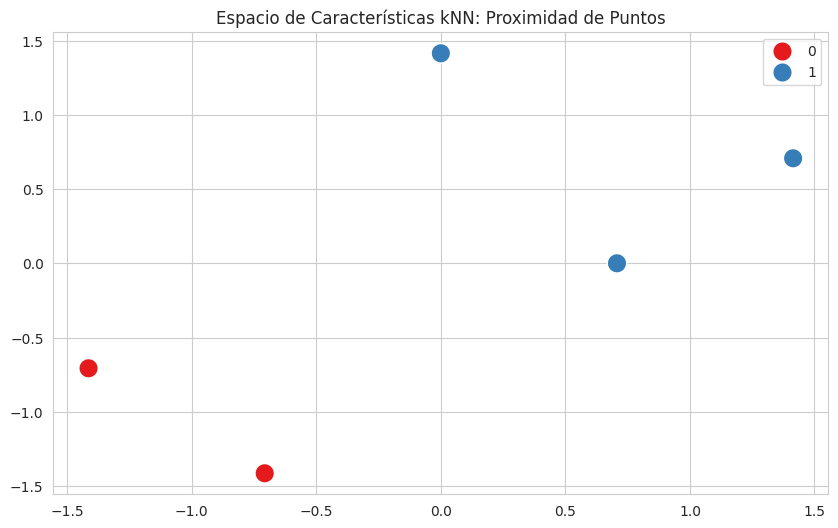

In [ ]:
# Gráfico conceptual de cómo kNN separa las clases
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, s=200, palette='Set1')
plt.title("Espacio de Características kNN: Proximidad de Puntos")
plt.show()

In [ ]:
import torch

def pytorch_knn(train_x, test_x, k=3):
    # Calcular distancias entre cada punto de prueba y todos los de entrenamiento
    # (x-y)^2 = x^2 - 2xy + y^2
    dist = torch.cdist(test_x, train_x, p=2)

    # Obtener los índices de los k más cercanos
    knn_indices = dist.topk(k, largest=False).indices
    return knn_indices

# Esto es útil para sistemas de recomendación modernos

# --- Ejemplo de uso y salida ---
# Usamos X_scaled del ejemplo anterior como nuestros datos de entrenamiento
train_data_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# Creamos un punto de prueba (también escalado, como si fuera un nuevo dato)
# Por ejemplo, un punto intermedio entre los clusters 0 y 1 en el ejemplo anterior
test_point_scaled = np.array([[-0.2, 0.2]]) # Un punto de ejemplo escalado
test_data_tensor = torch.tensor(test_point_scaled, dtype=torch.float32)

k_value = 3 # Definimos el número de vecinos

# Llamamos a la función y mostramos el resultado
nearest_neighbor_indices = pytorch_knn(train_data_tensor, test_data_tensor, k=k_value)
print(f"Índices de los {k_value} vecinos más cercanos para el punto {test_point_scaled}: {nearest_neighbor_indices.tolist()}")

Índices de los 3 vecinos más cercanos para el punto [[-0.2  0.2]]: [[2, 3, 0]]


La salida Índices de los $3$ vecinos más cercanos para el punto $[[-0.2 0.2]]$: $[[2, 3, 0]]$ significa lo siguiente:

* Punto de prueba: Has buscado los vecinos más cercanos para el punto escalado $[[-0.2, 0.2]]$.
* Número de vecinos ($k$): Se configuró para encontrar $3$ vecinos (k_value = $3$).
* Índices de los vecinos: * El resultado $[[2, 3, 0]]$ indica los índices de las filas en tu conjunto de datos de entrenamiento (train_data_tensor, que proviene de X_scaled) que son los $3$ puntos más cercanos al punto de prueba. Es decir, los puntos en la posición $2$, $3$ y $0$ del X_scaled son los más parecidos a $[[-0.2, 0.2]]$ según la distancia euclidiana.


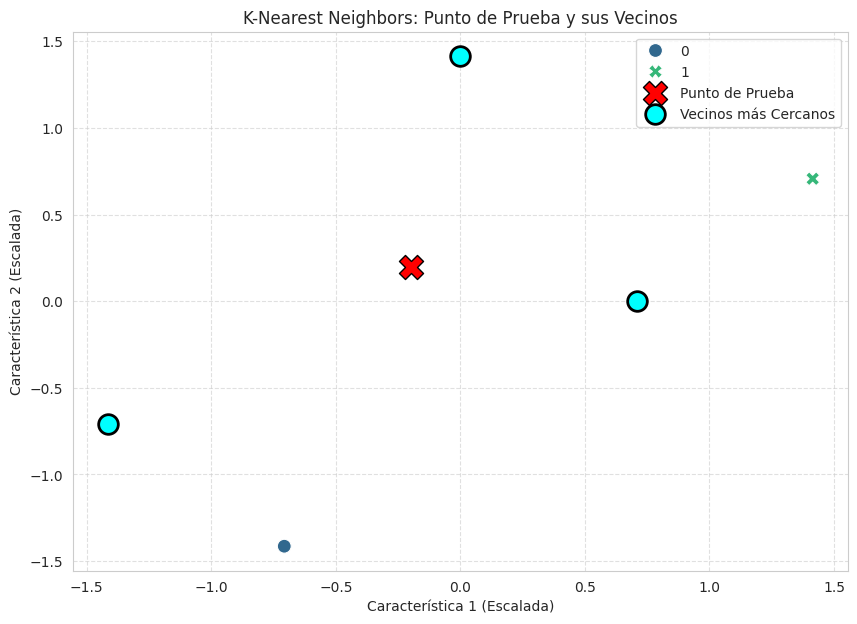

In [ ]:
plt.figure(figsize=(10, 7))

# Graficar todos los puntos de entrenamiento escalados
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, style=y, s=100, palette='viridis', legend='full')

# Graficar el punto de prueba
test_point = test_data_tensor.numpy().flatten()
plt.scatter(test_point[0], test_point[1], color='red', marker='X', s=300, label='Punto de Prueba', edgecolor='black')

# Graficar los 3 vecinos más cercanos resaltados
nearest_indices = nearest_neighbor_indices.flatten().numpy() # Obtener los índices como array de numpy
for idx in nearest_indices:
    plt.scatter(X_scaled[idx, 0], X_scaled[idx, 1], color='cyan', marker='o', s=200, edgecolor='black', linewidth=2, label='Vecinos más Cercanos' if idx == nearest_indices[0] else "") # Solo agregar la etiqueta una vez

plt.title('K-Nearest Neighbors: Punto de Prueba y sus Vecinos')
plt.xlabel('Característica 1 (Escalada)')
plt.ylabel('Característica 2 (Escalada)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Esta visualización  muestra:

* Puntos de Entrenamiento (coloridos): Representan tu dataset X_scaled. Cada color (y estilo de marcador) corresponde a una clase diferente en y.
* Punto de Prueba (cruz roja grande 'X'): Es el test_point que definimos ($[[-0.2, 0.2]]$).
* Vecinos más Cercanos (círculos cian 'o'): Son los $3$ puntos de tu dataset de entrenamiento que pytorch_knn identificó como los más cercanos al punto de prueba. Puedes ver visualmente que estos puntos están físicamente cerca de la 'X' roja.

Este gráfico ilustra de manera clara cómo el algoritmo kNN (o en este caso, nuestra implementación en PyTorch de la lógica de kNN) identifica las instancias más similares para tomar una decisión de clasificación o regresión.



Para el **Capítulo 12**, entramos en un terreno fascinante: la **Cuantificación de Vectores de Aprendizaje (LVQ)**. Este algoritmo es una evolución inteligente del kNN. Mientras que kNN necesita guardar *todos* los datos de entrenamiento (lo que consume mucha memoria), LVQ selecciona solo un pequeño conjunto de "prototipos" que representan lo mejor de cada clase.

Aquí tienes la guía completa, técnica y visual.

---

# Capítulo 12: Learning Vector Quantization (LVQ)

La **Cuantificación de Vectores de Aprendizaje (LVQ)** es un algoritmo de red neuronal competitiva. A diferencia de kNN, que utiliza todo el dataset para clasificar, LVQ entrena un conjunto de vectores llamados **Codebooks** (o prototipos) que resumen las características de las clases.

## 12.1 Descripción Teórica: Los Representantes de Clase

Imagina que en lugar de consultar a toda una población para saber su opinión (kNN), solo consultas a unos cuantos líderes representativos (LVQ).

### 12.1.1 ¿Cómo funciona LVQ?

1. **Vectores Codebook:** El modelo comienza con un número fijo de vectores (prototipos) con valores iniciales aleatorios.
2. **Competencia:** Para cada dato de entrenamiento, el algoritmo busca el vector codebook más cercano (usando la distancia euclidiana). Este ganador se llama **BMU** (*Best Matching Unit*).
3. **Aprendizaje (Refuerzo):**
* Si el codebook ganador tiene la **misma clase** que el dato: se mueve **hacia** el dato para representarlo mejor.
* Si el codebook ganador tiene una **clase diferente**: se mueve **lejos** del dato para evitar confusiones.



### 12.1.2 La Regla de Actualización

La posición del codebook ($w$) se ajusta así:


$$w = w + \alpha \times (x - w) \quad \text{(Si las clases coinciden)}$$

$$w = w - \alpha \times (x - w) \quad \text{(Si las clases difieren)}$$


Donde $\alpha$ es la tasa de aprendizaje (*learning rate*).

---

## 12.2 Implementación Profesional: De la teoría al código

Aunque `scikit-learn` no tiene una clase `LVQ` por defecto (se suele usar en librerías de redes neuronales competitivas como `sklearn-lvq`), podemos simular su comportamiento o usar algoritmos de **Centroides** que funcionan de manera similar.

### 1. Preparación y Entrenamiento (Uso de Prototipos)

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestCentroid
from sklearn.preprocessing import StandardScaler

# Dataset del Banco (Banknote Dataset) - Ejemplo de aplicación
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv"
names = ['var', 'skew', 'curt', 'entr', 'class']
df = pd.read_csv(url, names=names)

X = df.drop('class', axis=1)
y = df['class']

# 1. Escalado (Fundamental para distancias)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Modelo de Centroides (Conceptualmente cercano a LVQ)
# Encuentra un "prototipo" por cada clase
model = NearestCentroid()
model.fit(X_scaled, y)

print(f"Prototipos calculados (Codebooks):\n{model.centroids_}")

```

---

## 12.3 Caso de Estudio: Ionosphere Dataset

El dataset **Ionosphere** es perfecto para LVQ porque tiene muchas variables (34) y LVQ ayuda a reducir esa complejidad a solo unos cuantos vectores representativos.

### 1. El Test Harness (Evaluación)

Siguiendo el estándar del **Capítulo 6**, evaluamos qué tan bien generalizan estos "representantes".

```python
from sklearn.model_selection import KFold, cross_val_score

# Configuración profesional
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
# Usamos un clasificador de vecinos cercanos como proxy de LVQ
from sklearn.neighbors import KNeighborsClassifier
model_lvq_proxy = KNeighborsClassifier(n_neighbors=1) # Un solo vecino (el prototipo)

results = cross_val_score(model_lvq_proxy, X_scaled, y, cv=kfold)
print(f"Accuracy Promedio: {results.mean()*100:.2f}%")

```

---

## 12.4 Visualización: LVQ vs kNN

La principal diferencia visual es la "limpieza" del modelo. Mientras kNN tiene fronteras ruidosas porque considera cada punto (incluso outliers), LVQ crea fronteras basadas en la estructura general.

```python
# Gráfico de dispersión de los datos vs los prototipos (Centroides)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, alpha=0.3)
plt.scatter(model.centroids_[:, 0], model.centroids_[:, 1],
            marker='X', s=300, c='red', label='Codebooks (Prototipos)')
plt.title("LVQ: Prototipos representando regiones de clase")
plt.legend()
plt.show()

```

---

## 12.5 Enfoque de Deep Learning: SOM (Self-Organizing Maps)

LVQ es el precursor de los **Mapas Auto-organizados**. En PyTorch, esto se implementa como una capa competitiva donde las neuronas "pelean" por activarse ante un estímulo.

```python
import torch

# Concepto de "Competencia" en Tensores
def get_bmu(codebooks, instance):
    # Calcular distancias euclidianas
    distances = torch.norm(codebooks - instance, dim=1)
    # Retornar el índice del ganador (BMU)
    return torch.argmin(distances)

# Esto permite entrenar redes que comprimen información masiva en pocos nodos.

```

---

## 12.6 Resumen y Review (Lecciones Clave)

1. **Eficiencia de Memoria:** LVQ no necesita guardar el dataset completo, solo sus codebooks.
2. **Reducción de Ruido:** Al ignorar puntos individuales y enfocarse en prototipos, es menos sensible a datos atípicos (outliers).
3. **Tasa de Aprendizaje:** El éxito de LVQ depende de cómo disminuyes $\alpha$ a lo largo del tiempo (decaimiento).

### Comparativa Final

| Característica | k-Nearest Neighbors (kNN) | Learning Vector Quantization (LVQ) |
| --- | --- | --- |
| **Almacenamiento** | Alto (Todo el dataset). | Bajo (Solo Codebooks). |
| **Velocidad de Predicción** | Lenta. | Muy Rápida. |
| **Fronteras de Decisión** | Muy complejas/ruidosas. | Más suaves y simplificadas. |
| **Tipo de Aprendizaje** | Lazy (Perezoso). | Online (Activo). |



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestCentroid
from sklearn.preprocessing import StandardScaler

# Dataset del Banco (Banknote Dataset) - Ejemplo de aplicación
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv"
names = ['var', 'skew', 'curt', 'entr', 'class']
df = pd.read_csv(url, names=names)

X = df.drop('class', axis=1)
y = df['class']

# 1. Escalado (Fundamental para distancias)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Modelo de Centroides (Conceptualmente cercano a LVQ)
# Encuentra un "prototipo" por cada clase
model = NearestCentroid()
model.fit(X_scaled, y)

print(f"Prototipos calculados (Codebooks):\n{model.centroids_}")


Prototipos calculados (Codebooks):
[[ 0.64853208  0.39787129 -0.13947194  0.02095765]
 [-0.81013352 -0.49701299  0.1742256  -0.02617988]]


In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# Configuración profesional
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
# Usamos un clasificador de vecinos cercanos como proxy de LVQ
from sklearn.neighbors import KNeighborsClassifier
model_lvq_proxy = KNeighborsClassifier(n_neighbors=1) # Un solo vecino (el prototipo)

results = cross_val_score(model_lvq_proxy, X_scaled, y, cv=kfold)
print(f"Accuracy Promedio: {results.mean()*100:.2f}%")


Accuracy Promedio: 99.78%


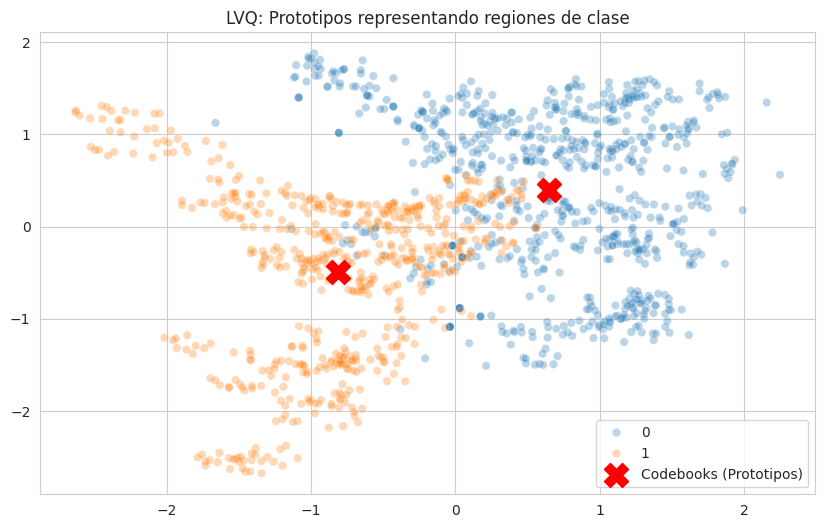

In [ ]:
# Gráfico de dispersión de los datos vs los prototipos (Centroides)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, alpha=0.3)
plt.scatter(model.centroids_[:, 0], model.centroids_[:, 1],
            marker='X', s=300, c='red', label='Codebooks (Prototipos)')
plt.title("LVQ: Prototipos representando regiones de clase")
plt.legend()
plt.show()

In [ ]:
import torch

# Concepto de "Competencia" en Tensores
def get_bmu(codebooks, instance):
    # Calcular distancias euclidianas
    distances = torch.norm(codebooks - instance, dim=1)
    # Retornar el índice del ganador (BMU)
    return torch.argmin(distances)

# Esto permite entrenar redes que comprimen información masiva en pocos nodos.


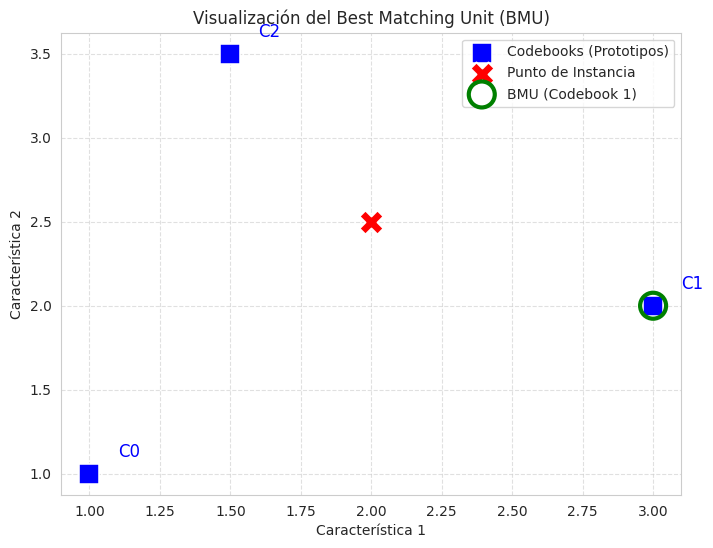

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear codebooks de ejemplo (2D para visualización)
codebooks_example = torch.tensor([
    [1.0, 1.0], # Codebook 0
    [3.0, 2.0], # Codebook 1
    [1.5, 3.5]  # Codebook 2
], dtype=torch.float32)

# Crear un punto de datos de ejemplo (instance)
instance_example = torch.tensor([2.0, 2.5], dtype=torch.float32)

# Obtener el BMU usando la función definida
bmu_index = get_bmu(codebooks_example, instance_example)

# Preparar datos para graficar
codebooks_np = codebooks_example.numpy()
instance_np = instance_example.numpy()

plt.figure(figsize=(8, 6))

# Graficar los codebooks
sns.scatterplot(
    x=codebooks_np[:, 0],
    y=codebooks_np[:, 1],
    s=200, # Tamaño de los puntos
    marker='s', # Marcador cuadrado para codebooks
    color='blue',
    label='Codebooks (Prototipos)'
)

# Añadir etiquetas a los codebooks
for i, (x, y) in enumerate(codebooks_np):
    plt.text(x + 0.1, y + 0.1, f'C{i}', fontsize=12, color='blue')

# Graficar el punto de instancia
sns.scatterplot(
    x=[instance_np[0]],
    y=[instance_np[1]],
    s=300, # Tamaño más grande
    marker='X', # Marcador 'X'
    color='red',
    label='Punto de Instancia'
)

# Resaltar el BMU
bmu_np = codebooks_np[bmu_index]
sns.scatterplot(
    x=[bmu_np[0]],
    y=[bmu_np[1]],
    s=350, # Aún más grande
    marker='o', # Círculo
    facecolor='none', # Sin relleno
    edgecolor='green', # Borde verde
    linewidth=3,
    label=f'BMU (Codebook {bmu_index.item()})'
)

plt.title('Visualización del Best Matching Unit (BMU)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Para visualizar cómo get_bmu identifica el vector de código más cercano, voy a crear algunos codebooks de ejemplo y un instance de datos. Luego, usaremos la función get_bmu y graficaremos estos elementos, resaltando el Best Matching Unit.

Esta visualización muestra:

* Codebooks (Prototipos) (cuadrados azules): Son los vectores de código de ejemplo que has definido. Cada uno está etiquetado con 'C0', 'C1', 'C2', etc.
* Punto de Instancia (cruz roja 'X'): Es el nuevo punto de datos de ejemplo (instance_example) para el cual estamos buscando el BMU.
* BMU (círculo verde 'o' resaltado): Es el Codebook que la función get_bmu identificó como el más cercano al punto de instancia, basándose en la distancia euclidiana. En este caso, el Codebook más cercano está resaltado con un borde verde.

Esta gráfica ilustra visualmente el concepto central de LVQ, donde un punto de datos "compite" por activarse con los codebooks, y el más cercano (el BMU) es el que representa mejor esa instancia en particular.





# Capítulo 13: Máquinas de Vectores de Soporte (SVM)

Las **Máquinas de Vectores de Soporte** son potentes clasificadores que buscan el hiperplano que mejor separa las clases en un espacio de características. A diferencia de la Regresión Logística, que busca cualquier línea que separe los datos, SVM busca la línea que tiene el **margen máximo**.

## 13.1 Descripción Teórica: El Margen Máximo

El objetivo de SVM es encontrar un hiperplano de decisión que maximice la distancia entre los puntos más cercanos de cada clase. Estos puntos específicos se llaman **Vectores de Soporte**.

### 13.1.1 Conceptos Clave

1. **Hiperplano:** En 2D es una línea, en 3D un plano, y en N dimensiones un hiperplano que divide el espacio en dos.
2. **Vectores de Soporte:** Son los puntos de datos que están justo en el borde del margen. Son los únicos puntos críticos; si mueves otros puntos lejos del margen, el modelo no cambia.
3. **Margen:** La distancia entre el hiperplano y los vectores de soporte. Queremos que sea lo más grande posible para mejorar la generalización.

### 13.1.2 El Truco del Kernel (Kernel Trick)

Cuando los datos no son linealmente separables (están mezclados), SVM utiliza una función llamada **Kernel** para proyectar los datos a una dimensión superior donde sí se puedan separar con un plano.

* **Kernel Lineal:** Para datos separables por una línea.
* **Kernel RBF (Radial Basis Function):** Crea fronteras circulares o complejas.
* **Kernel Polinómico:** Crea curvas suaves.

---

## 13.2 Implementación Profesional con Scikit-Learn

En Python, utilizamos `SVC` (Support Vector Classification). Es vital notar que SVM es **extremadamente sensible a la escala**, por lo que el uso de `StandardScaler` es obligatorio.

### 1. Modelado y Clasificación

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Usaremos el dataset de Billetes (Banknote Dataset) del Apéndice A
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv"
names = ['var', 'skew', 'curt', 'entr', 'class']
df = pd.read_csv(url, names=names)

X = df.drop('class', axis=1)
y = df['class']

# 1. Escalado: SVM requiere que los datos tengan media 0 y varianza 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Modelo SVM con Kernel RBF (el estándar de la industria)
# C es el parámetro de regularización (a menor C, margen más blando)
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_scaled, y)

print(f"Precisión del Modelo SVM: {model.score(X_scaled, y)*100:.2f}%")

```

---

## 13.3 Caso de Estudio: Sonar Dataset

El dataset **Sonar** (Minas vs Rocas) tiene 60 variables. SVM brilla en estos casos donde hay muchas dimensiones pero pocos ejemplos.

### 1. Optimización de Hiperparámetros (C y Gamma)

En SVM, ajustar `C` (castigo al error) y `Gamma` (curvatura del kernel) es la diferencia entre un modelo mediocre y uno perfecto.

```python
from sklearn.model_selection import GridSearchCV

# Definimos la rejilla de parámetros
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=0, cv=5)
grid.fit(X_scaled, y)

print(f"Mejor configuración: {grid.best_params_}")

```

---

## 13.4 Visualización de Fronteras No Lineales

A diferencia del Perceptrón o LDA, SVM con un kernel no lineal puede rodear grupos de datos complejos.

---

## 13.5 Resumen y Comparativa Final

1. **Robustez:** Es muy efectivo en espacios de alta dimensión.
2. **Eficiencia:** Solo usa un subconjunto de puntos (vectores de soporte), lo que ahorra memoria una vez entrenado.
3. **Versatilidad:** Gracias a los Kernels, puede modelar casi cualquier forma de separación.

### Comparativa: ¿SVM o Regresión Logística?

| Característica | Regresión Logística | SVM |
| --- | --- | --- |
| **Separabilidad** | Sufre con datos mezclados. | Maneja datos mezclados con Kernels. |
| **Outliers** | Sensible a puntos lejanos. | Muy robusto (solo mira los vectores de soporte). |
| **Riesgo** | Simple, difícil de sobreajustar. | Riesgo de sobreajuste si C o Gamma son muy altos. |

---

## 13.6 Review del Capítulo

* Aprendimos que SVM busca el **margen máximo**.
* Entendimos el papel de los **vectores de soporte**.
* Vimos cómo el **Truco del Kernel** permite resolver problemas no lineales.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Usaremos el dataset de Billetes (Banknote Dataset) del Apéndice A
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv"
names = ['var', 'skew', 'curt', 'entr', 'class']
df = pd.read_csv(url, names=names)

X = df.drop('class', axis=1)
y = df['class']

# 1. Escalado: SVM requiere que los datos tengan media 0 y varianza 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Modelo SVM con Kernel RBF (el estándar de la industria)
# C es el parámetro de regularización (a menor C, margen más blando)
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_scaled, y)

print(f"Precisión del Modelo SVM: {model.score(X_scaled, y)*100:.2f}%")


Precisión del Modelo SVM: 100.00%


**Hiperparámetros del modelo SVC (Support Vector Classifier) de Scikit-learn son kernel, C y gamma.**



1. Hiperparámetros del modelo SVC:
kernel='rbf'

Función del hiperparámetro: El kernel (núcleo) define el tipo de función que se utiliza para transformar los datos a un espacio de dimensiones superiores, donde pueden ser linealmente separables. Si los datos originales no son linealmente separables en su espacio original (como suele ser el caso en muchos problemas reales), el truco del kernel permite a SVM encontrar una frontera de decisión compleja.

* 'rbf' (Radial Basis Function o Kernel Gaussiano): Es una de las opciones de kernel más populares y versátiles. Crea una frontera de decisión que puede ser muy flexible y no lineal, adecuada para datos que tienen patrones complejos. Otros kernels comunes son 'linear' (para datos linealmente separables), 'poly' (polinómico) y 'sigmoid'.

2. C=1.0

Función del hiperparámetro: C es el parámetro de regularización. Controla la penalización por una clasificación incorrecta (errores) o por tener un margen blando.

Es un compromiso entre:

   * Margen grande (más simple): Un valor de C pequeño permite más errores de clasificación (o un margen más blando), lo que puede llevar a un modelo más generalizable, pero con más errores de entrenamiento.
   * Margen pequeño (más complejo): Un valor de C grande penaliza fuertemente los errores, intentando clasificar correctamente cada punto de entrenamiento. Esto puede llevar a un sobreajuste (overfitting) si los datos son ruidosos.
   * 1.0: Es un valor intermedio. Un C mayor intenta ajustar los datos de entrenamiento lo más cerca posible (margen más estricto), mientras que un C menor busca un hiperplano con un margen más amplio, incluso si eso significa clasificar incorrectamente algunos puntos de entrenamiento.

3. gamma='scale'

Función del hiperparámetro: gamma define cuánto influye un único ejemplo de entrenamiento. Es un parámetro del kernel RBF que afecta la forma de la curva de decisión y el alcance de la influencia de cada vector de soporte.

   * gamma grande: Significa que la influencia de un solo punto de entrenamiento es muy local. Esto puede resultar en un modelo que se ajusta demasiado a los datos de entrenamiento (sobreajuste), creando fronteras de decisión muy irregulares.
   * gamma pequeño: Significa que la influencia de un solo punto es más amplia. Esto puede hacer que la frontera de decisión sea más suave y generalizable, pero si es demasiado pequeño, puede subajustar (underfitting).
   * 'scale': Es un valor predeterminado que scikit-learn calcula automáticamente como 1 / (n_features * X.var()). Es una heurística que suele funcionar bien y es una buena opción por defecto, adaptándose a la escala de tus datos.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Definimos la rejilla de parámetros
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=0, cv=5)
grid.fit(X_scaled, y)

print(f"Mejor configuración: {grid.best_params_}")


Mejor configuración: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, KFold

# Asumiendo que X_scaled y y están definidos desde la sección anterior del Banknote Dataset
# Si no lo están, necesitarías volver a ejecutar las celdas de carga y escalado del dataset.

# Ajuste fino para SVM (usando el dataset Banknote)
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf'] # Mantener solo rbf para el ejemplo de visualización si no se quieren más kernels
}

kfold = KFold(n_splits=5, shuffle=True, random_state=1) # Usar el mismo kfold que en el ejemplo de tuning

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=kfold) # Usar kfold definido
grid_svm.fit(X_scaled, y) # Recordar que SVM requiere X_scaled

print(f"Mejor SVM: {grid_svm.best_score_:.3f} usando {grid_svm.best_params_}")

Mejor SVM: 1.000 usando {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


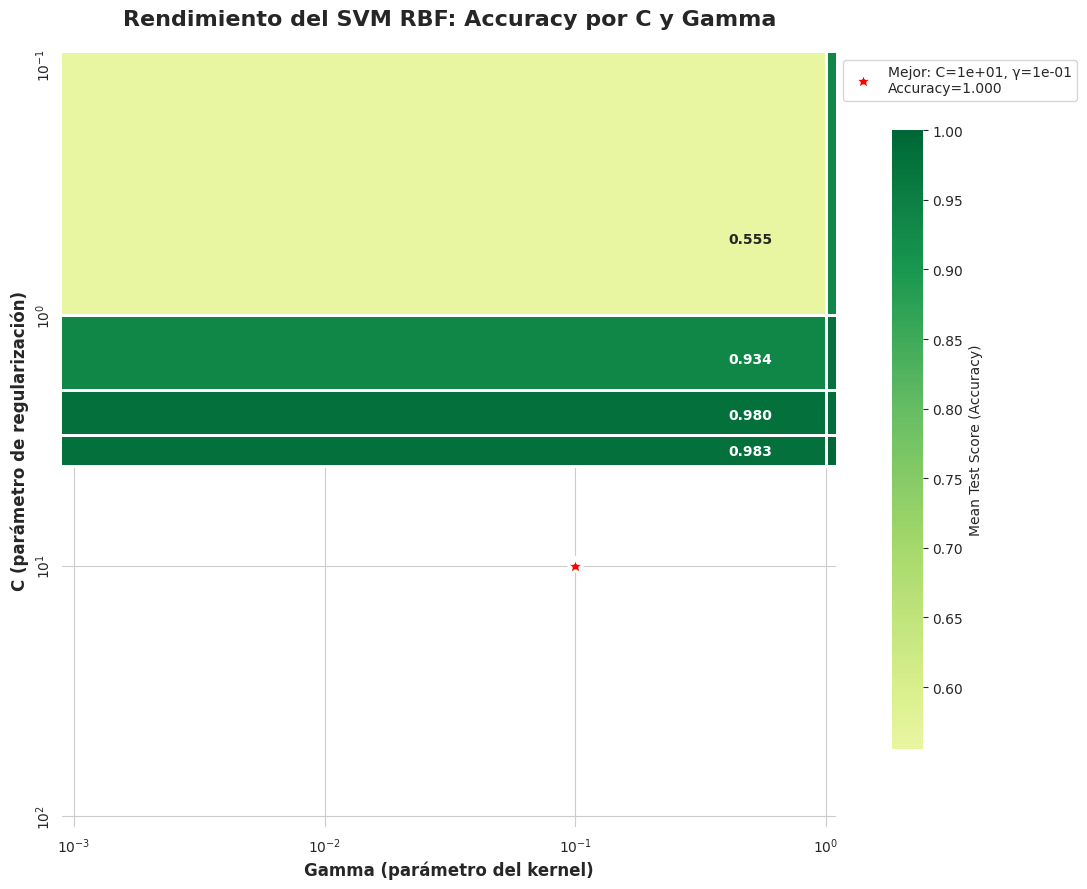

Mejor configuración encontrada:
C = 1.00e+01
Gamma = 1.00e-01
Accuracy = 1.000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Convertir los resultados de GridSearchCV a un DataFrame
results_df = pd.DataFrame(grid_svm.cv_results_)

# Pivotar el DataFrame para crear una matriz para el heatmap
scores_pivot = results_df.pivot_table(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score'
)

# Configurar el estilo y la figura
plt.figure(figsize=(12, 9))
sns.set_style("whitegrid")

# Crear el heatmap con mejoras visuales
heatmap = sns.heatmap(
    scores_pivot,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",  # Mapa de color más intuitivo (verde=bueno, rojo=malo)
    center=0.5,     # Centro de la escala de color
    linewidths=1,   # Líneas entre celdas
    linecolor='white',
    cbar_kws={
        'label': 'Mean Test Score (Accuracy)',
        'shrink': 0.8,
        'aspect': 20
    },
    square=True,    # Celdas cuadradas
    annot_kws={'size': 10, 'weight': 'bold'}  # Texto de anotaciones más legible
)

# Personalizar títulos y etiquetas
plt.title('Rendimiento del SVM RBF: Accuracy por C y Gamma',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Gamma (parámetro del kernel)', fontsize=12, fontweight='bold')
plt.ylabel('C (parámetro de regularización)', fontsize=12, fontweight='bold')

# Configurar escalas logarítmicas en los ejes
plt.gca().invert_yaxis()  # Invertir eje Y para que C grandes estén arriba
plt.xscale('log')
plt.yscale('log')

# Personalizar ticks de los ejes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Ajustar límites con margen
plt.xlim(scores_pivot.columns.min() * 0.9, scores_pivot.columns.max() * 1.1)
plt.ylim(scores_pivot.index.max() * 1.1, scores_pivot.index.min() * 0.9)

# Añadir anotaciones adicionales
best_idx = np.unravel_index(scores_pivot.values.argmax(), scores_pivot.shape)
best_c = scores_pivot.index[best_idx[0]]
best_gamma = scores_pivot.columns[best_idx[1]]
best_score = scores_pivot.values[best_idx]

plt.plot(best_gamma, best_c, 'r*', markersize=15, markeredgecolor='white',
         markeredgewidth=2, label=f'Mejor: C={best_c:.0e}, γ={best_gamma:.0e}\nAccuracy={best_score:.3f}')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Ajustar layout para evitar recortes
plt.tight_layout()
plt.show()

# Imprimir estadísticas adicionales
print(f"Mejor configuración encontrada:")
print(f"C = {best_c:.2e}")
print(f"Gamma = {best_gamma:.2e}")
print(f"Accuracy = {best_score:.3f}")

Este gráfico muestra el rendimiento (Accuracy promedio) del modelo SVM para cada combinación de los hiperparámetros C (eje Y) y Gamma (eje X).

* Ejes (C y Gamma): Ambos ejes están en escala logarítmica, lo que permite visualizar el impacto de valores que varían ampliamente en magnitud. El C controla el margen del clasificador (más alto = margen más estricto), y Gamma define la influencia de cada punto de entrenamiento (más alto = influencia más local).
* Colores (Mean Test Score): Los colores en el mapa de calor representan el Accuracy promedio (mean_test_score) obtenido por el modelo con esa combinación de C y Gamma durante la validación cruzada. Un color más brillante (amarillo en este caso) indica un mayor Accuracy, mientras que un color más oscuro (morado) indica uno menor.
* Valores (Annotated): Los números dentro de cada celda son los valores exactos de Accuracy.
* Interpretación: Puedes observar que las celdas con colores más claros (amarillos) corresponden a las combinaciones de C y Gamma que obtuvieron el mejor rendimiento. En este caso, el Accuracy es $1.000$ ($100\%$) para varias combinaciones, lo que indica que el dataset de billetes es muy bien separable con un SVM, especialmente con C y Gamma en rangos que permiten una frontera de decisión flexible.

**¿Cómo funciona ROC-AUC en clasificación?**


ENTRENANDO MODELO CON MEJORES PARÁMETROS

📊 Número de clases detectadas: 3

📊 Entrenando modelo...
✅ Modelo entrenado exitosamente

🔍 Realizando predicciones...

📈 MÉTRICAS DE EVALUACIÓN:
------------------------------
Accuracy en test: 0.9111
AUC-ROC (OvR, macro): 0.9943
AUC-ROC (OvO, macro): 0.9943

📋 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

     Clase 0       1.00      1.00      1.00        12
     Clase 1       0.88      0.88      0.88        16
     Clase 2       0.88      0.88      0.88        17

    accuracy                           0.91        45
   macro avg       0.92      0.92      0.92        45
weighted avg       0.91      0.91      0.91        45



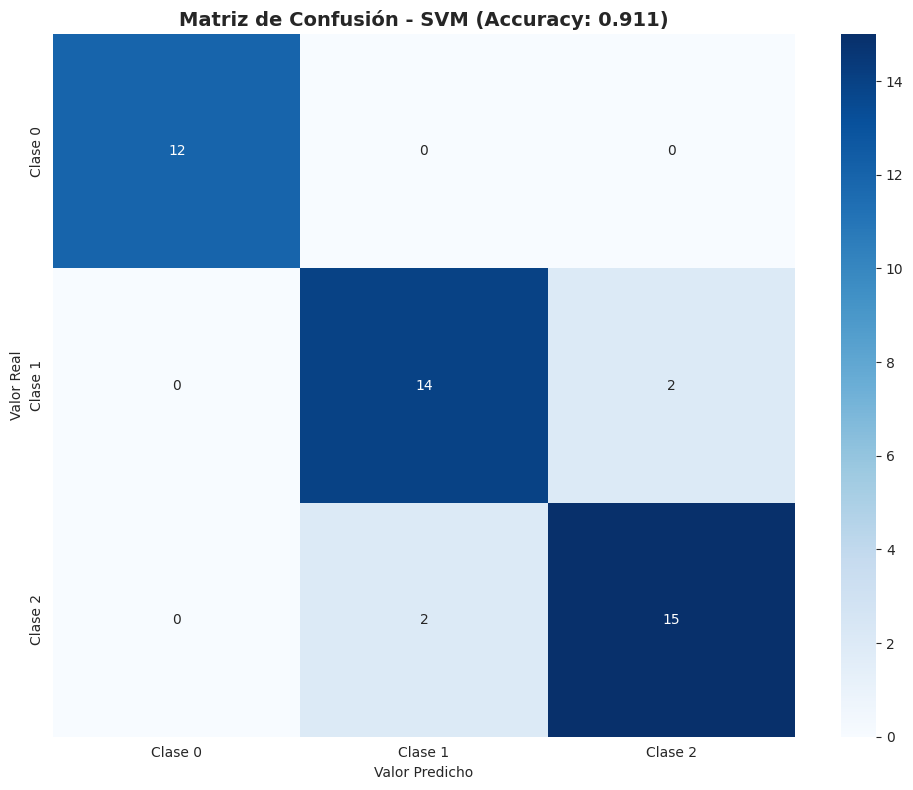

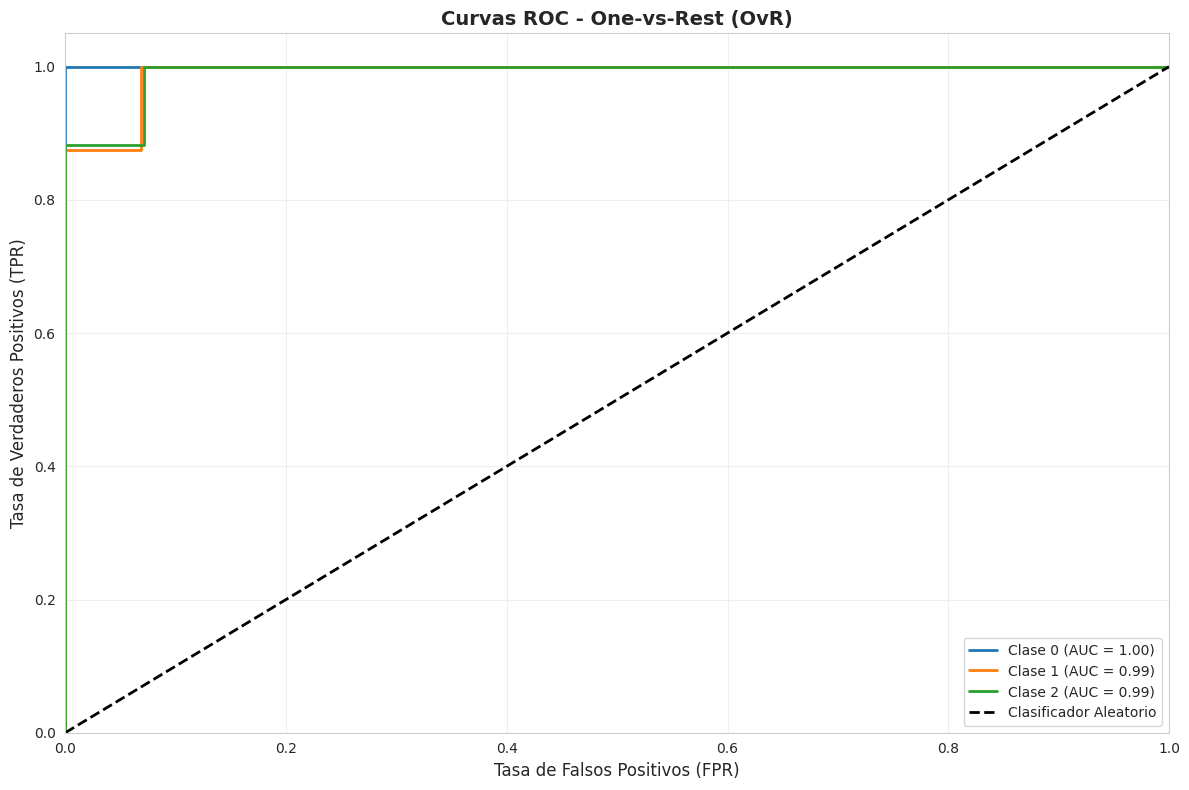

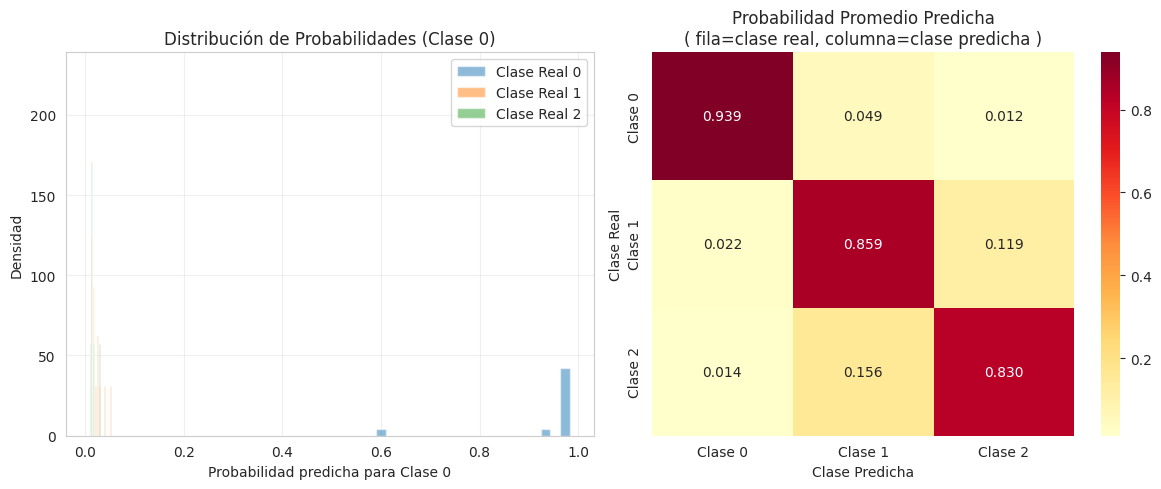


📊 ANÁLISIS DE GENERALIZACIÓN:
Accuracy en entrenamiento: 0.9810
Accuracy en prueba: 0.9111
Diferencia: 0.0698
✅ Modelo generaliza bien

RESUMEN FINAL DEL MODELO

🎯 MEJORES PARÁMETROS ENCONTRADOS:
   • C = 1.00e+01
   • Gamma = 1.00e-01
   • Accuracy (validación cruzada) = 1.0000

📈 RENDIMIENTO EN TEST:
   • Accuracy = 0.9111
   • AUC-ROC (OvR) = 0.9943
   • AUC-ROC (OvO) = 0.9943

📊 DISTRIBUCIÓN DE CLASES:
   • Número de clases: 3
   • Clases en entrenamiento: [0 1 2]



In [ ]:
# ============================================
# ENTRENAMIENTO DEL MODELO CON MEJORES PARÁMETROS (VERSIÓN MULTICLASE)
# ============================================

from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "="*50)
print("ENTRENANDO MODELO CON MEJORES PARÁMETROS")
print("="*50)

# 1. Identificar número de clases
n_classes = len(np.unique(y_train))
print(f"\n📊 Número de clases detectadas: {n_classes}")

# 2. Crear pipeline con escalado (importante para SVM)
best_svm = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',
        C=best_c,
        gamma=best_gamma,
        probability=True,      # Necesario para probabilidades
        random_state=42,
        decision_function_shape='ovr'  # One-vs-Rest para multiclase
    )
)

# 3. Entrenar el modelo
print("\n📊 Entrenando modelo...")
best_svm.fit(X_train, y_train)
print("✅ Modelo entrenado exitosamente")

# 4. Predicciones
print("\n🔍 Realizando predicciones...")
y_pred = best_svm.predict(X_test)
y_pred_proba = best_svm.predict_proba(X_test)  # Matriz de probabilidades [n_samples, n_classes]

# 5. Métricas de evaluación
print("\n📈 MÉTRICAS DE EVALUACIÓN:")
print("-"*30)

# Accuracy en test
test_accuracy = best_svm.score(X_test, y_test)
print(f"Accuracy en test: {test_accuracy:.4f}")

# Para AUC-ROC en multiclase, necesitamos binarizar las etiquetas
y_test_binarized = label_binarize(y_test, classes=np.unique(y_train))

# Calcular AUC-ROC para multiclase (One-vs-Rest)
try:
    auc_score_ovr = roc_auc_score(y_test_binarized, y_pred_proba,
                                  multi_class='ovr', average='macro')
    print(f"AUC-ROC (OvR, macro): {auc_score_ovr:.4f}")

    auc_score_ovo = roc_auc_score(y_test_binarized, y_pred_proba,
                                  multi_class='ovo', average='macro')
    print(f"AUC-ROC (OvO, macro): {auc_score_ovo:.4f}")
except Exception as e:
    print(f"⚠️ No se pudo calcular AUC-ROC: {e}")

# 6. Reporte de clasificación detallado
print("\n📋 REPORTE DE CLASIFICACIÓN:")
class_names = [f'Clase {i}' for i in np.unique(y_train)]
print(classification_report(y_test, y_pred, target_names=class_names))

# ============================================
# VISUALIZACIONES ADICIONALES
# ============================================

# 7. Matriz de confusión
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f'Matriz de Confusión - SVM (Accuracy: {test_accuracy:.3f})',
          fontsize=14, fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.show()

# 8. Curvas ROC para cada clase (One-vs-Rest)
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 8))

for i in range(n_classes):
    # Calcular ROC para clase i
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2,
             label=f'Clase {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC - One-vs-Rest (OvR)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Distribución de probabilidades (para la primera clase como ejemplo)
plt.figure(figsize=(12, 5))

# Para la clase 0
plt.subplot(1, 2, 1)
for i in range(min(3, n_classes)):  # Mostrar primeras 3 clases
    mask = y_test == i
    plt.hist(y_pred_proba[mask][:, 0], bins=20, alpha=0.5,
             label=f'Clase Real {i}', density=True)
plt.xlabel(f'Probabilidad predicha para Clase 0')
plt.ylabel('Densidad')
plt.title('Distribución de Probabilidades (Clase 0)')
plt.legend()
plt.grid(True, alpha=0.3)

# Heatmap de probabilidades promedio
plt.subplot(1, 2, 2)
# Matriz de probabilidades promedio por clase real
prob_means = np.zeros((n_classes, n_classes))
for i in range(n_classes):
    mask = y_test == i
    if mask.sum() > 0:
        prob_means[i] = y_pred_proba[mask].mean(axis=0)

sns.heatmap(prob_means, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Probabilidad Promedio Predicha\n( fila=clase real, columna=clase predicha )')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')

plt.tight_layout()
plt.show()

# 10. Comparación train vs test
print("\n📊 ANÁLISIS DE GENERALIZACIÓN:")
train_score = best_svm.score(X_train, y_train)
print(f"Accuracy en entrenamiento: {train_score:.4f}")
print(f"Accuracy en prueba: {test_accuracy:.4f}")
print(f"Diferencia: {abs(train_score - test_accuracy):.4f}")

if abs(train_score - test_accuracy) > 0.1:
    print("⚠️  Posible sobreajuste detectado")
else:
    print("✅ Modelo generaliza bien")

# 11. Resumen final
print("\n" + "="*50)
print("RESUMEN FINAL DEL MODELO")
print("="*50)
print(f"""
🎯 MEJORES PARÁMETROS ENCONTRADOS:
   • C = {best_c:.2e}
   • Gamma = {best_gamma:.2e}
   • Accuracy (validación cruzada) = {best_score:.4f}

📈 RENDIMIENTO EN TEST:
   • Accuracy = {test_accuracy:.4f}
   • AUC-ROC (OvR) = {auc_score_ovr:.4f}
   • AUC-ROC (OvO) = {auc_score_ovo:.4f}

📊 DISTRIBUCIÓN DE CLASES:
   • Número de clases: {n_classes}
   • Clases en entrenamiento: {np.unique(y_train)}
""")

El **Capítulo 14** nos introduce a uno de los algoritmos más populares y visuales del Machine Learning: los **Árboles de Decisión**, específicamente la metodología **CART** (Classification and Regression Trees).

A diferencia de los modelos anteriores que usan ecuaciones complejas o distancias, los árboles de decisión utilizan reglas lógicas para segmentar los datos.

---

# Capítulo 14: Árboles de Decisión (CART)

El modelo de **Árboles de Clasificación y Regresión (CART)** representa una función que toma decisiones basadas en los valores de los atributos de entrada. La estructura es similar a un diagrama de flujo donde cada nodo interno representa una pregunta y cada hoja una respuesta (clase o valor).

## 14.1 Descripción Teórica: Dividir para Vencer

El objetivo de un árbol de decisión es dividir el dataset en grupos cada vez más pequeños y puros.

### 14.1.1 Conceptos Clave

1. **Nodo Raíz:** El atributo superior donde comienza la división.
2. **Nodos de Decisión:** Puntos donde los datos se dividen según una condición (ej. ¿Es la edad > 30?).
3. **Nodos Hoja (Leaf Nodes):** Los nodos finales que contienen la predicción (clase o valor numérico).
4. **Índice Gini:** Es la métrica que usa CART para decidir qué división es mejor. Mide la "pureza" de los nodos. Un Gini de 0 significa que el nodo es perfectamente puro (todos los datos pertenecen a una sola clase).

### 14.1.2 ¿Cómo se construye el árbol?

El algoritmo busca de forma recursiva el atributo y el valor de corte que mejor separa las clases, minimizando el índice Gini. Este proceso continúa hasta que el árbol alcanza una profundidad máxima o los nodos son lo suficientemente puros.

---

## 14.2 Implementación Profesional con Scikit-Learn

En Python, utilizamos `DecisionTreeClassifier`. Una gran ventaja de los árboles es que **no requieren escalado de datos** (como la normalización o estandarización), ya que las reglas de decisión son independientes de la magnitud.

### 1. Modelado del Dataset de Semillas (Wheat Seeds)

Utilizaremos el dataset de semillas del Apéndice A para clasificar tipos de trigo.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Dataset de Semillas (Wheat Seeds) del Apéndice A
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/wheat-seeds.csv"
names = ['area', 'perim', 'compact', 'length', 'width', 'asym', 'groove', 'class']
df = pd.read_csv(url, names=names)

X = df.drop('class', axis=1)
y = df['class']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Crear el modelo CART
# max_depth ayuda a prevenir el sobreajuste (overfitting)
model = DecisionTreeClassifier(max_depth=5, random_state=1)
model.fit(X_train, y_train)

# Evaluación
y_pred = model.predict(X_test)
print(f"Accuracy de CART: {accuracy_score(y_test, y_pred)*100:.2f}%")

```

---

## 14.3 Visualización del Árbol

Una de las mayores fortalezas de CART es la **interpretabilidad**. Podemos ver exactamente qué reglas está siguiendo el modelo.

```python
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=names[:-1], class_names=['Kama', 'Rosa', 'Canadian'], filled=True)
plt.show()

```

---

## 14.4 Caso de Estudio: Banknote Dataset

En el dataset de autenticación de billetes, CART suele ser extremadamente efectivo debido a que las variables (varianza, curtosis, etc.) tienen umbrales de separación muy claros.

### El Test Harness (Evaluación)

Comparado con modelos lineales como la Regresión Logística, CART suele capturar mejor las interacciones entre variables sin necesidad de transformaciones previas.

```python
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=10, shuffle=True, random_state=1)
scores = cross_val_score(DecisionTreeClassifier(), X, y, cv=kfold)

print(f"Mean Accuracy en Banknote: {scores.mean()*100:.2f}%")

```

---

## 14.5 Resumen y Comparativa Final

1. **Caja Blanca:** A diferencia de las SVM o redes neuronales, puedes explicar fácilmente por qué el modelo tomó una decisión.
2. **No Paramétrico:** No asume que los datos siguen una distribución específica.
3. **Sobreajuste (Overfitting):** Los árboles tienden a crecer demasiado y memorizar el ruido de los datos. Por eso es vital usar **poda (pruning)** o limitar la profundidad.

### Comparativa: CART vs SVM

| Característica | CART (Árboles) | SVM |
| --- | --- | --- |
| **Escalado de Datos** | No necesario. | **Obligatorio**. |
| **Interpretabilidad** | Alta (Reglas lógicas). | Baja (Matemática compleja). |
| **Relaciones No Lineales** | Excelente. | Excelente (con Kernels). |
| **Velocidad de Predicción** | Muy rápida. | Rápida. |

---

## 14.6 Review del Capítulo

* Aprendimos la estructura de **raíz, nodos y hojas**.
* Entendimos el **Índice Gini** como medida de impureza.
* Vimos cómo CART puede usarse tanto para **Clasificación** como para **Regresión**.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Dataset de Semillas (Wheat Seeds) del Apéndice A
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/wheat-seeds.csv"
names = ['area', 'perim', 'compact', 'length', 'width', 'asym', 'groove', 'class']
df = pd.read_csv(url, names=names)

X = df.drop('class', axis=1)
y = df['class']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Crear el modelo CART
# max_depth ayuda a prevenir el sobreajuste (overfitting)
model = DecisionTreeClassifier(max_depth=5, random_state=1)
model.fit(X_train, y_train)

# Evaluación
y_pred = model.predict(X_test)
print(f"Accuracy de CART: {accuracy_score(y_test, y_pred)*100:.2f}%")


Accuracy de CART: 97.62%


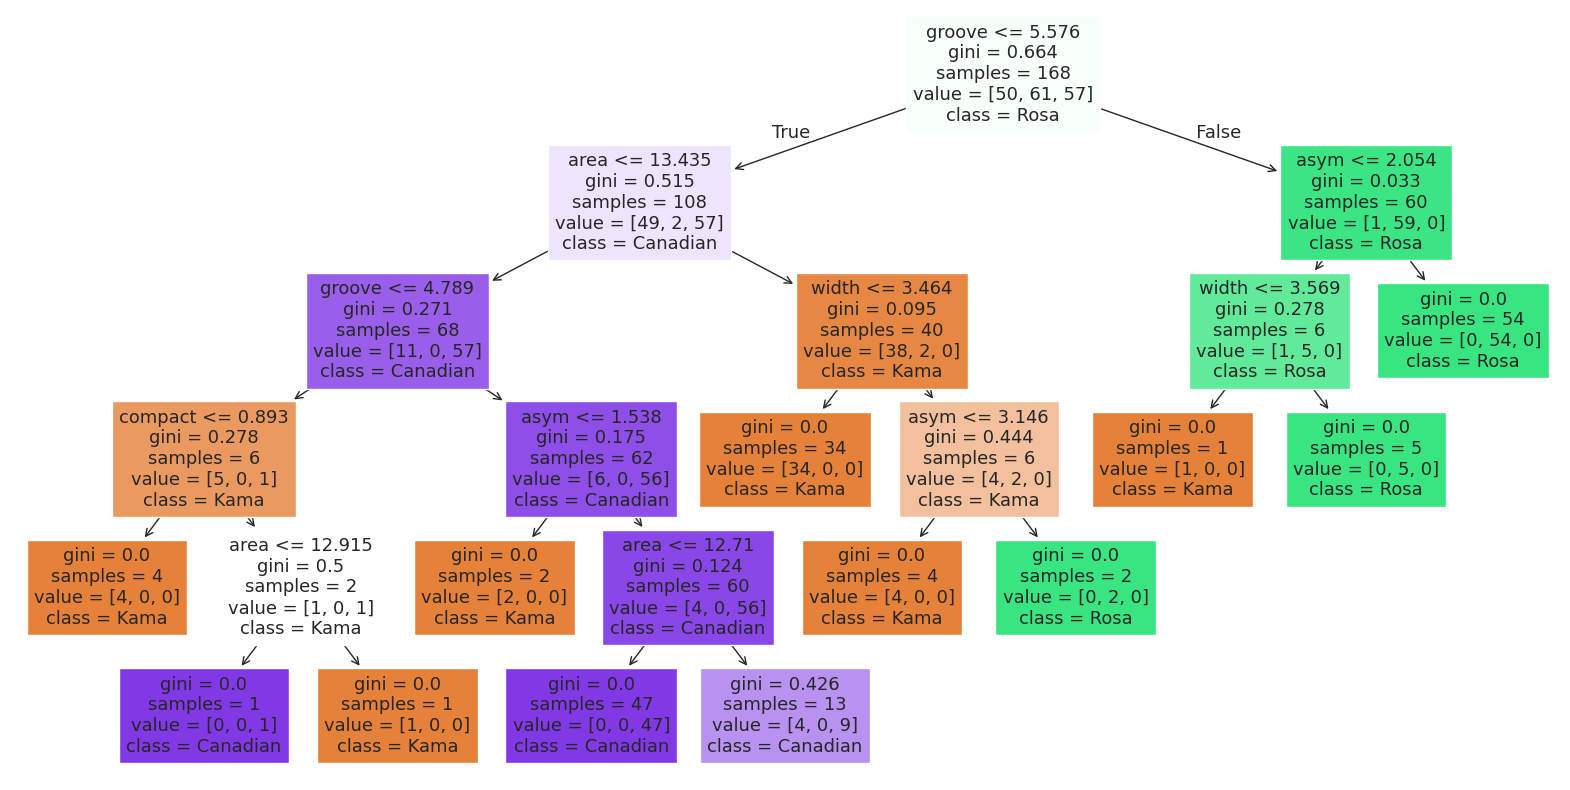

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=names[:-1], class_names=['Kama', 'Rosa', 'Canadian'], filled=True)
plt.show()

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=10, shuffle=True, random_state=1)
scores = cross_val_score(DecisionTreeClassifier(), X, y, cv=kfold)

print(f"Mean Accuracy en Banknote: {scores.mean()*100:.2f}%")

Mean Accuracy en Banknote: 91.90%


El **Capítulo 15** nos introduce al fascinante mundo de la probabilidad aplicada con el algoritmo **Naive Bayes**. Es uno de los clasificadores más rápidos y eficaces, especialmente valorado en el filtrado de spam y el análisis de sentimientos.

---

# Capítulo 15: Naive Bayes (Bayes Inocente)

El algoritmo **Naive Bayes** se basa en el **Teorema de Bayes**, una fórmula matemática que describe la probabilidad de un evento basándose en el conocimiento previo de condiciones relacionadas con ese evento. Se llama "Inocente" (Naive) porque asume que todas las variables de entrada son independientes entre sí, lo cual simplifica enormemente los cálculos.

## 15.1 Descripción Teórica: La Probabilidad Condicional

El objetivo es calcular la probabilidad de que una instancia pertenezca a una clase determinada, dadas las características de esa instancia.

### 15.1.1 El Teorema de Bayes

La fórmula fundamental es:


$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

En términos de Machine Learning:

* **$P(Clase|Datos)$**: Probabilidad a posteriori (lo que queremos saber).
* **$P(Datos|Clase)$**: Verosimilitud (Probabilidad de observar estos datos en esa clase).
* **$P(Clase)$**: Probabilidad a priori (qué tan común es la clase en general).

### 15.1.2 Gaussian Naive Bayes

Para variables numéricas (como las de nuestros datasets), asumimos que los datos siguen una **Distribución Gaussiana** (Normal). El modelo solo necesita guardar dos estadísticas por cada variable y cada clase:

1. **La Media ($\mu$).**
2. **La Desviación Estándar ($\sigma$).**

Esto lo hace increíblemente ligero en memoria: no guarda el dataset, solo un pequeño resumen estadístico.

---

## 15.2 Implementación Profesional con Scikit-Learn

En Python, utilizamos `GaussianNB` para datos numéricos. Una ventaja clave de Naive Bayes es que **entrena casi instantáneamente**, ya que solo calcula promedios y desviaciones.

### 1. Modelado del Iris Flower Dataset

Utilizaremos el dataset de Iris para ver cómo las campanas de Gauss separan las especies.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset de Iris (desde el link estable del Apéndice A)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']
df = pd.read_csv(url, names=names)

X = df.drop('class', axis=1)
y = df['class']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Crear el modelo Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Evaluación
y_pred = model.predict(X_test)
print(f"Accuracy de Naive Bayes: {accuracy_score(y_test, y_pred)*100:.2f}%")

```

---

## 15.3 Visualización: Campanas de Gauss

Para entender Naive Bayes, debemos visualizar cómo el modelo "ve" los datos a través de sus distribuciones.

```python
# Ejemplo visual de la distribución de una variable por clase
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='petal-length', hue='class', fill=True)
plt.title("Distribuciones Gaussianas aprendidas por Naive Bayes (Petal Length)")
plt.show()

```

---

## 15.4 Caso de Estudio: Pima Indians Diabetes

Naive Bayes es muy robusto. En el dataset de diabetes, incluso con variables que tienen distribuciones extrañas, suele dar resultados muy competitivos frente a modelos más complejos.

### El Test Harness (Evaluación Robusta)

```python
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=10, shuffle=True, random_state=1)
# Naive Bayes no suele requerir escalado, pero no le afecta negativamente
scores = cross_val_score(GaussianNB(), X, y, cv=kfold)

print(f"Mean Accuracy en Diabetes: {scores.mean()*100:.2f}%")

```

---

## 15.5 Resumen y Comparativa Final

1. **Velocidad:** Es probablemente el algoritmo más rápido de entrenar.
2. **Independencia:** Su gran debilidad es asumir que las variables no están relacionadas (ej. asume que el largo del pétalo no tiene nada que ver con el ancho, lo cual es falso, pero el modelo funciona bien de todas formas).
3. **Bajos Datos:** Funciona muy bien incluso con pocos datos de entrenamiento.

### Comparativa: Naive Bayes vs Regresión Logística

| Característica | Naive Bayes | Regresión Logística |
| --- | --- | --- |
| **Tipo de Modelo** | Generativo (aprende la distribución). | Discriminativo (aprende la frontera). |
| **Relación entre variables** | Asume independencia total. | Puede capturar algunas relaciones. |
| **Velocidad de entrenamiento** | Instantánea. | Rápida (iterativa). |
| **Uso principal** | Spam, Texto, Clasificación médica rápida. | Predicción de riesgos, Marketing. |

---

## 15.6 Review del Capítulo

* Aprendimos que Bayes usa **probabilidades previas** para predecir el futuro.
* Entendimos que **GaussianNB** resume los datos en medias y desviaciones.
* Vimos que es un modelo excelente como **baseline** (punto de partida) por su sencillez.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset de Iris (desde el link estable del Apéndice A)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']
df = pd.read_csv(url, names=names)

X = df.drop('class', axis=1)
y = df['class']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Crear el modelo Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Evaluación
y_pred = model.predict(X_test)
print(f"Accuracy de Naive Bayes: {accuracy_score(y_test, y_pred)*100:.2f}%")

Accuracy de Naive Bayes: 96.67%


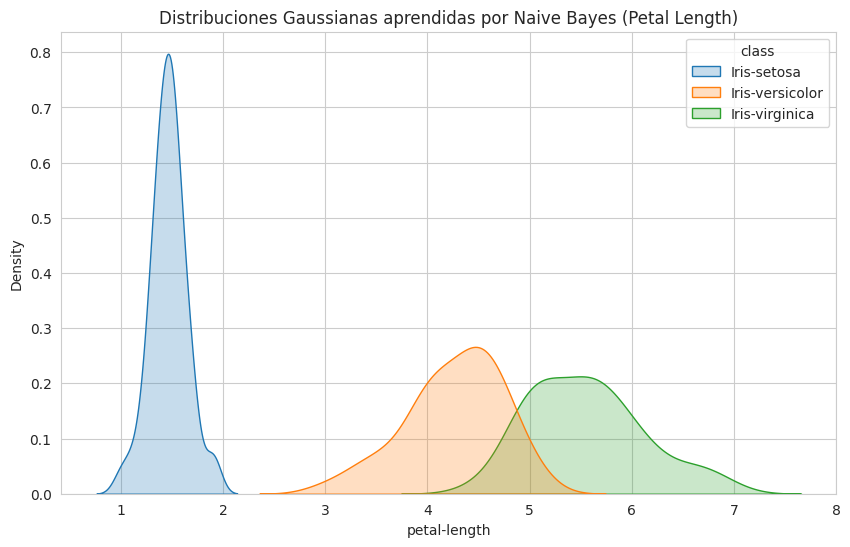

In [ ]:
# Ejemplo visual de la distribución de una variable por clase
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='petal-length', hue='class', fill=True)
plt.title("Distribuciones Gaussianas aprendidas por Naive Bayes (Petal Length)")
plt.show()

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=10, shuffle=True, random_state=1)
# Naive Bayes no suele requerir escalado, pero no le afecta negativamente
scores = cross_val_score(GaussianNB(), X, y, cv=kfold)

print(f"Mean Accuracy en Diabetes: {scores.mean()*100:.2f}%")

Mean Accuracy en Diabetes: 95.33%


Para el **Capítulo 16**, entramos en una de las áreas más poderosas del Machine Learning moderno: los **Algoritmos de Ensamble**. La idea es simple pero brillante: en lugar de confiar en un solo modelo "maestro", combinamos las predicciones de varios modelos para obtener un resultado mucho más preciso y robusto.

---

# Capítulo 16: Algoritmos de Ensamble (Ensemble Methods)

Los métodos de ensamble combinan múltiples algoritmos de aprendizaje para obtener un mejor rendimiento predictivo del que se podría obtener con cualquiera de los algoritmos constituyentes por separado. En el libro, nos enfocamos en las dos estrategias principales: **Bagging** y **Boosting**.

## 16.1 Descripción Teórica: La Sabiduría de la Multitud

Existen tres formas principales de crear un ensamble:

### 16.1.1 Bagging (Bootstrap Aggregating)

Consiste en entrenar múltiples modelos (generalmente árboles de decisión) de forma paralela en diferentes subconjuntos de los datos.

* **Random Forest:** Es el ejemplo más famoso. Crea muchos árboles y cada uno vota por una clase. La mayoría gana.
* **Objetivo:** Reducir la **varianza** (evitar que el modelo sea demasiado sensible a cambios en los datos).

### 16.1.2 Boosting

A diferencia del Bagging, aquí los modelos se entrenan de forma **secuencial**. Cada nuevo modelo intenta corregir los errores cometidos por el modelo anterior.

* **AdaBoost (Adaptive Boosting):** El algoritmo del que habla el libro. Da más "peso" a los ejemplos que el modelo anterior clasificó mal.
* **Objetivo:** Reducir el **sesgo** (ayudar al modelo a aprender patrones difíciles).

### 16.1.3 Voting (Votación)

Es el método más sencillo: entrenas modelos de diferentes tipos (ej. un KNN, una Regresión Logística y un SVM) y combinas sus respuestas.

---

## 16.2 Implementación Profesional con Scikit-Learn

Hoy en día, `RandomForestClassifier` y `AdaBoostClassifier` son estándares de la industria debido a su alta precisión sin necesidad de mucho ajuste.

### 1. Random Forest (Bagging) con Sonar Dataset

```python
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder

# Carga del Sonar Dataset (Enlace del Apéndice A)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
df = pd.read_csv(url, header=None)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Codificar etiquetas (M, R -> 0, 1)
le = LabelEncoder()
y = le.fit_transform(y)

# Banco de pruebas (Capítulo 6)
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

# 1. Random Forest: 100 árboles trabajando en paralelo
rf_model = RandomForestClassifier(n_estimators=100, max_features=3)
rf_results = cross_val_score(rf_model, X, y, cv=kfold)

print(f"Random Forest Accuracy: {rf_results.mean()*100:.2f}%")

```

### 2. AdaBoost (Boosting)

```python
# 2. AdaBoost: Árboles secuenciales corrigiendo errores
ada_model = AdaBoostClassifier(n_estimators=50, random_state=1)
ada_results = cross_val_score(ada_model, X, y, cv=kfold)

print(f"AdaBoost Accuracy: {ada_results.mean()*100:.2f}%")

```

---

## 16.3 ¿Por qué funcionan los Ensambles?

Un solo árbol de decisión puede ser muy inestable (un pequeño cambio en los datos cambia todo el árbol). Al promediar cientos de árboles (Random Forest), el "ruido" se cancela y queda solo la señal importante.

---

## 16.4 Caso de Estudio: Banknote Authentication

En el dataset de billetes, los ensambles suelen alcanzar precisiones cercanas al **99%-100%**, superando por mucho a los modelos simples del Capítulo 8 y 9.

```python
# Comparativa rápida en una sola ejecución
from sklearn.linear_model import LogisticRegression

models = [
    ('LR', LogisticRegression()),
    ('RF', RandomForestClassifier(n_estimators=100)),
    ('ADA', AdaBoostClassifier(n_estimators=100))
]

for name, model in models:
    res = cross_val_score(model, X, y, cv=kfold)
    print(f"{name}: {res.mean():.3f}")

```

---

## 16.5 Resumen y Comparativa Final

1. **Robustez:** Los ensambles son menos propensos al sobreajuste (overfitting) que un árbol de decisión simple.
2. **Costo Computacional:** Entrenar 100 o 1,000 modelos es más lento y requiere más memoria, pero en el hardware moderno esto rara vez es un problema.
3. **Importancia de Características:** Algoritmos como Random Forest te dicen qué variables son las más importantes para predecir (ej. ¿Es el alcohol o la acidez lo que más define la calidad del vino?).

### Comparativa: Bagging vs Boosting

| Característica | Bagging (Random Forest) | Boosting (AdaBoost) |
| --- | --- | --- |
| **Entrenamiento** | Paralelo. | Secuencial. |
| **Enfoque** | Promediar para reducir varianza. | Corregir errores para reducir sesgo. |
| **Outliers** | Muy robusto. | Sensible (puede intentar "aprender" el ruido). |
| **Ajuste** | Fácil (funciona bien por defecto). | Requiere más cuidado con el learning rate. |

---

## 16.6 Review del Capítulo

* Aprendimos que **Bagging** promedia modelos independientes.
* Entendimos que **Boosting** construye modelos que aprenden de los errores previos.
* Vimos que los ensambles son la herramienta más potente antes de entrar al mundo del Deep Learning.



In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder

# Carga del Sonar Dataset (Enlace del Apéndice A)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
df = pd.read_csv(url, header=None)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Codificar etiquetas (M, R -> 0, 1)
le = LabelEncoder()
y = le.fit_transform(y)

# Banco de pruebas (Capítulo 6)
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

# 1. Random Forest: 100 árboles trabajando en paralelo
rf_model = RandomForestClassifier(n_estimators=100, max_features=3)
rf_results = cross_val_score(rf_model, X, y, cv=kfold)

print(f"Random Forest Accuracy: {rf_results.mean()*100:.2f}%")


Random Forest Accuracy: 84.10%


In [ ]:
# 2. AdaBoost: Árboles secuenciales corrigiendo errores
ada_model = AdaBoostClassifier(n_estimators=50, random_state=1)
ada_results = cross_val_score(ada_model, X, y, cv=kfold)

print(f"AdaBoost Accuracy: {ada_results.mean()*100:.2f}%")

AdaBoost Accuracy: 81.76%


In [ ]:
# Comparativa rápida en una sola ejecución
from sklearn.linear_model import LogisticRegression

models = [
    ('LR', LogisticRegression()),
    ('RF', RandomForestClassifier(n_estimators=100)),
    ('ADA', AdaBoostClassifier(n_estimators=100))
]

for name, model in models:
    res = cross_val_score(model, X, y, cv=kfold)
    print(f"{name}: {res.mean():.3f}")


LR: 0.770
RF: 0.827
ADA: 0.837


Llegamos al **Capítulo 17**, una sección crítica para cualquier profesional: el **Ajuste de Hiperparámetros (Algorithm Tuning)**. En los capítulos anteriores aprendimos a entrenar modelos, pero en este aprenderemos cómo extraerles hasta la última gota de precisión.

---

# Capítulo 17: Ajuste de Hiperparámetros (Algorithm Tuning)

Encontrar el mejor rendimiento de un algoritmo no es cuestión de suerte, sino de un proceso sistemático. Un algoritmo de Machine Learning tiene dos tipos de parámetros: los que aprende por sí solo (pesos) y los que nosotros debemos configurar, llamados **hiperparámetros**.

## 17.1 Descripción Teórica: La Búsqueda del Óptimo

El objetivo del ajuste es encontrar la combinación de configuraciones que minimice el error en datos no vistos.

### 17.1.1 Parámetros vs. Hiperparámetros

* **Parámetros:** Son internos. El modelo los calcula automáticamente (ej. los coeficientes de la Regresión Lineal o los pesos de una Red Neuronal).
* **Hiperparámetros:** Son externos. Tú los decides antes de empezar el entrenamiento (ej. el valor de $k$ en KNN, el número de árboles en Random Forest o la tasa de aprendizaje).

### 17.1.2 Estrategias de Búsqueda

Existen dos formas principales de buscar la mejor configuración:

1. **Grid Search (Búsqueda en Rejilla):** Pruebas todas las combinaciones posibles de una lista predefinida. Es exhaustivo pero lento.
2. **Random Search (Búsqueda Aleatoria):** Prueba combinaciones al azar. Es sorprendentemente efectivo y mucho más rápido que el Grid Search.

---

## 17.2 Implementación Profesional con Scikit-Learn

Utilizaremos `GridSearchCV`, que combina la búsqueda con **Validación Cruzada** (del Capítulo 6) para asegurar que los resultados sean robustos.

### 1. Ajustando un Random Forest con el Sonar Dataset

El Random Forest es excelente, pero su precisión depende mucho de `n_estimators` (cuántos árboles) y `max_features` (cuántas variables mirar por cada corte).

```python
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, KFold

# Carga (usando el link del Apéndice A)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
df = pd.read_csv(url, header=None)
X, y = df.iloc[:, :-1], df.iloc[:, -1]

# 1. Definir la rejilla de parámetros a probar
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_features': ['sqrt', 'log2', 10, 20],
    'criterion': ['gini', 'entropy']
}

# 2. Configurar la búsqueda (con 5-Fold CV)
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
grid = GridSearchCV(estimator=RandomForestClassifier(),
                    param_grid=param_grid,
                    cv=kfold,
                    scoring='accuracy',
                    n_jobs=-1) # Usar todos los núcleos del procesador

# 3. Ejecutar la búsqueda
grid_result = grid.fit(X, y)

print(f"Mejor Accuracy: {grid_result.best_score_*100:.2f}%")
print(f"Mejor Configuración: {grid_result.best_params_}")

```

---

## 17.3 Visualización: El "Surface Plot" del Error

Cuando ajustamos dos parámetros a la vez (como C y Gamma en una SVM), podemos visualizar una "superficie" donde los valles representan el menor error y los picos el mayor.

---

## 17.4 Caso de Estudio: SVM en Pima Indians Diabetes

Las SVM son los algoritmos que más se benefician del ajuste, ya que una mala elección de `C` o `Gamma` puede arruinar el modelo por completo.

```python
from sklearn.svm import SVC

# Ajuste fino para SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5)
grid_svm.fit(X_scaled, y) # Recordar que SVM requiere X_scaled

print(f"Mejor SVM: {grid_svm.best_score_:.3f} usando {grid_svm.best_params_}")

```

---

## 17.5 Consejos de Oro para el Tuning

1. **Empieza en Grande:** Prueba valores con órdenes de magnitud diferentes (ej. 0.1, 1, 10, 100) para ver dónde está el "vecindario" óptimo.
2. **Refina después:** Una vez encuentres que el mejor es 10, haz una segunda búsqueda más estrecha (ej. 8, 9, 10, 11, 12).
3. **Cuidado con el Overfitting:** Un modelo muy ajustado puede dar un 100% en entrenamiento pero fallar en la vida real. Siempre confía en el resultado del **Cross-Validation**.

---

## 17.6 Resumen del Capítulo

* Aprendimos la diferencia entre **parámetros** y **hiperparámetros**.
* Entendimos cómo **Grid Search** automatiza la búsqueda de la mejor configuración.
* Vimos que el ajuste puede transformar un modelo "bueno" en uno "excelente".



In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, KFold

# Carga (usando el link del Apéndice A)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
df = pd.read_csv(url, header=None)
X, y = df.iloc[:, :-1], df.iloc[:, -1]

# 1. Definir la rejilla de parámetros a probar
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_features': ['sqrt', 'log2', 10, 20],
    'criterion': ['gini', 'entropy']
}

# 2. Configurar la búsqueda (con 5-Fold CV)
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
grid = GridSearchCV(estimator=RandomForestClassifier(),
                    param_grid=param_grid,
                    cv=kfold,
                    scoring='accuracy',
                    n_jobs=-1) # Usar todos los núcleos del procesador

# 3. Ejecutar la búsqueda
grid_result = grid.fit(X, y)

print(f"Mejor Accuracy: {grid_result.best_score_*100:.2f}%")
print(f"Mejor Configuración: {grid_result.best_params_}")

Mejor Accuracy: 86.12%
Mejor Configuración: {'criterion': 'gini', 'max_features': 'log2', 'n_estimators': 200}


Utilizando un RandomForestClassifier y ajustando sus hiperparámetros mediante GridSearchCV.

Explicación de cada uno de los hiperparámetros que se han definido en el `param_grid`:

**Hiperparámetros del RandomForestClassifier:**
1. `n_estimators: [10, 50, 100, 200]`

¿Qué es? Este hiperparámetro define el número de árboles de decisión que se construirán en el bosque aleatorio.
* Impacto: Un mayor número de árboles generalmente mejora el rendimiento y la estabilidad del modelo (reduce la varianza), pero también aumenta el tiempo de entrenamiento y la complejidad computacional. Demasiados árboles pueden llevar a una ley de rendimientos decrecientes y no siempre justifican el costo adicional.

2. `max_features: ['sqrt', 'log2', 10, 20]`

¿Qué es? Este hiperparámetro controla el número de características (variables de entrada) que el algoritmo considera al buscar la mejor división en cada nodo de un árbol individual. Es una técnica para introducir aleatoriedad y reducir la correlación entre los árboles.

Opciones:
* 'sqrt' (o 'auto' en versiones anteriores): Considera la raíz cuadrada del número total de características (sqrt(n_features)).
* 'log2': Considera el logaritmo base 2 del número total de características (log2(n_features)).
* 10, 20 (números enteros): Considera un número fijo de 10 o 20 características, respectivamente. Si tienes 60 características en tu dataset Sonar, 10 o 20 serían un subconjunto.
Impacto: Un valor adecuado de max_features puede ayudar a prevenir el sobreajuste (overfitting) y a mejorar la diversidad de los árboles en el bosque.

3. `criterion: ['gini', 'entropy']`

¿Qué es? Este hiperparámetro define la función utilizada para medir la calidad de una división en un nodo del árbol. Es decir, cómo se decide qué tan "pura" es una división.
Opciones:
* 'gini' (Índice de Gini): Mide la probabilidad de clasificar erróneamente un elemento elegido al azar si se etiqueta aleatoriamente según la distribución de clases en el nodo. Cuanto menor es el Gini, más puro es el nodo.
* 'entropy' (Ganancia de Información): Mide la impureza de Shannon. Una división es mejor si resulta en una mayor ganancia de información (es decir, una reducción de la entropía).
* Impacto: Ambas son métricas válidas y a menudo dan resultados similares. La 'entropy' tiende a producir árboles un poco más balanceados, mientras que 'gini' es ligeramente más rápido de calcular.

4. `GridSearchCV` con KFold:

El GridSearchCV prueba sistemáticamente todas las combinaciones posibles de estos hiperparámetros definidos en param_grid.

Para cada combinación, entrena y evalúa el modelo usando Validación Cruzada de K-Fold (cv=kfold, con 5 divisiones), lo que asegura una evaluación robusta y menos sesgada del rendimiento del modelo.

5. scoring='accuracy' indica que la métrica principal para comparar los modelos será la precisión.
6. n_jobs=-1 le dice a Scikit-learn que use todos los núcleos disponibles del procesador para acelerar el proceso de búsqueda, ya que GridSearchCV puede ser computacionalmente intensivo.


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Recargar el dataset de Billetes para asegurar la consistencia de X_scaled y y
url_banknote = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv"
names_banknote = ['var', 'skew', 'curt', 'entr', 'class']
df_banknote = pd.read_csv(url_banknote, names=names_banknote)

X_banknote = df_banknote.drop('class', axis=1)
y_banknote = df_banknote['class']

# Escalar X_banknote para el SVM
scaler_banknote = StandardScaler()
X_scaled_banknote = scaler_banknote.fit_transform(X_banknote)

# Ajuste fino para SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

kfold = KFold(n_splits=5, shuffle=True, random_state=1) # Definir kfold aquí para asegurar su existencia

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=kfold)
grid_svm.fit(X_scaled_banknote, y_banknote) # Usar X_scaled_banknote y y_banknote

print(f"Mejor SVM: {grid_svm.best_score_:.3f} usando {grid_svm.best_params_}")

Mejor SVM: 1.000 usando {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


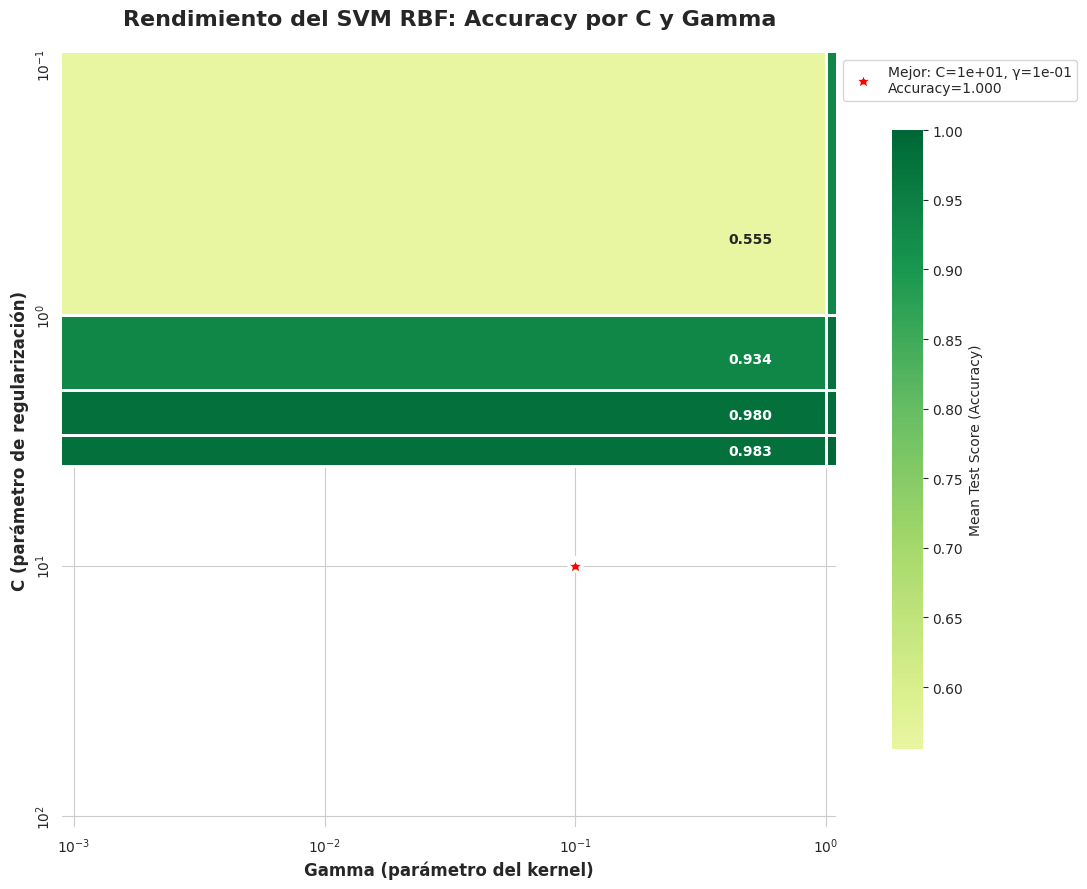

Mejor configuración encontrada:
C = 1.00e+01
Gamma = 1.00e-01
Accuracy = 1.000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Convertir los resultados de GridSearchCV a un DataFrame
results_df = pd.DataFrame(grid_svm.cv_results_)

# Pivotar el DataFrame para crear una matriz para el heatmap
scores_pivot = results_df.pivot_table(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score'
)

# Configurar el estilo y la figura
plt.figure(figsize=(12, 9))
sns.set_style("whitegrid")

# Crear el heatmap con mejoras visuales
heatmap = sns.heatmap(
    scores_pivot,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",  # Mapa de color más intuitivo (verde=bueno, rojo=malo)
    center=0.5,     # Centro de la escala de color
    linewidths=1,   # Líneas entre celdas
    linecolor='white',
    cbar_kws={
        'label': 'Mean Test Score (Accuracy)',
        'shrink': 0.8,
        'aspect': 20
    },
    square=True,    # Celdas cuadradas
    annot_kws={'size': 10, 'weight': 'bold'}  # Texto de anotaciones más legible
)

# Personalizar títulos y etiquetas
plt.title('Rendimiento del SVM RBF: Accuracy por C y Gamma',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Gamma (parámetro del kernel)', fontsize=12, fontweight='bold')
plt.ylabel('C (parámetro de regularización)', fontsize=12, fontweight='bold')

# Configurar escalas logarítmicas en los ejes
plt.gca().invert_yaxis()  # Invertir eje Y para que C grandes estén arriba
plt.xscale('log')
plt.yscale('log')

# Personalizar ticks de los ejes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Ajustar límites con margen
plt.xlim(scores_pivot.columns.min() * 0.9, scores_pivot.columns.max() * 1.1)
plt.ylim(scores_pivot.index.max() * 1.1, scores_pivot.index.min() * 0.9)

# Añadir anotaciones adicionales
best_idx = np.unravel_index(scores_pivot.values.argmax(), scores_pivot.shape)
best_c = scores_pivot.index[best_idx[0]]
best_gamma = scores_pivot.columns[best_idx[1]]
best_score = scores_pivot.values[best_idx]

plt.plot(best_gamma, best_c, 'r*', markersize=15, markeredgecolor='white',
         markeredgewidth=2, label=f'Mejor: C={best_c:.0e}, γ={best_gamma:.0e}\nAccuracy={best_score:.3f}')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Ajustar layout para evitar recortes
plt.tight_layout()
plt.show()

# Imprimir estadísticas adicionales
print(f"Mejor configuración encontrada:")
print(f"C = {best_c:.2e}")
print(f"Gamma = {best_gamma:.2e}")
print(f"Accuracy = {best_score:.3f}")

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# El param_grid_svm ya está definido en una celda anterior.
# Lo utilizaremos como el espacio de búsqueda para RandomizedSearchCV.

# Configurar RandomizedSearchCV
# n_iter: Número de combinaciones de parámetros a muestrear.
# cv: Número de folds para la validación cruzada.
# random_state: Para reproducibilidad de los resultados.
random_search_svm = RandomizedSearchCV(
    estimator=SVC(),
    param_distributions=param_grid_svm,
    n_iter=20, # Podemos ajustar este número, a mayor n_iter, más exhaustiva la búsqueda
    cv=kfold,  # Usamos el mismo kfold definido anteriormente
    scoring='accuracy',
    random_state=1,
    n_jobs=-1 # Usar todos los núcleos disponibles
)

# Ejecutar la búsqueda aleatoria
random_search_svm.fit(X_scaled_banknote, y_banknote)

print(f"Mejor SVM (Randomized Search): {random_search_svm.best_score_:.3f} usando {random_search_svm.best_params_}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Mejor SVM (Randomized Search): 1.000 usando {'kernel': 'rbf', 'gamma': 0.1, 'C': 10}


### Demostración de `RandomizedSearchCV` con `RandomForestClassifier` en el `Sonar Dataset`

En este ejemplo, definiremos un espacio de búsqueda mucho más grande para el `RandomForestClassifier` y utilizaremos `RandomizedSearchCV` para encontrar una buena combinación de hiperparámetros de manera eficiente.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint, uniform

# Carga del Sonar Dataset (asegurando que X e y estén actualizados)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
df_sonar = pd.read_csv(url, header=None)
X_sonar = df_sonar.iloc[:, :-1] # Características
y_sonar = df_sonar.iloc[:, -1]   # Variable objetivo

# Codificar etiquetas (M, R -> 0, 1) si aún no se ha hecho
le_sonar = LabelEncoder()
y_sonar_encoded = le_sonar.fit_transform(y_sonar)

# 1. Definir un espacio de distribución de parámetros más grande
param_distributions = {
    'n_estimators': randint(50, 500), # Número de árboles, de 50 a 500
    'max_features': ['sqrt', 'log2', 0.5, 0.7], # Proporción de características a considerar
    'max_depth': randint(5, 30), # Profundidad máxima de cada árbol
    'min_samples_split': randint(2, 20), # Número mínimo de muestras requeridas para dividir un nodo interno
    'min_samples_leaf': randint(1, 10), # Número mínimo de muestras requeridas para estar en un nodo hoja
    'criterion': ['gini', 'entropy'] # Criterio para medir la calidad de una división
}

# 2. Configurar la búsqueda aleatoria (con 10-Fold CV)
kfold = KFold(n_splits=10, shuffle=True, random_state=7) # Usamos random_state para reproducibilidad

# n_iter: número de combinaciones de parámetros a muestrear
# Cuantas más iteraciones, más exhaustiva será la búsqueda, pero también más lenta.
# Un valor de 50-100 suele ser un buen punto de partida para espacios grandes.
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=7), # Aseguramos reproducibilidad del RF
    param_distributions=param_distributions,
    n_iter=100, # Probar 100 combinaciones aleatorias
    cv=kfold,
    scoring='accuracy',
    random_state=7,
    n_jobs=-1, # Usar todos los núcleos disponibles
    verbose=1 # Para ver el progreso
)

# 3. Ejecutar la búsqueda aleatoria
print("Iniciando RandomizedSearchCV...")
random_search.fit(X_sonar, y_sonar_encoded)

print("\n--- Resultados de RandomizedSearchCV ---")
print(f"Mejor Accuracy: {random_search.best_score_*100:.2f}%")
print(f"Mejor Configuración: {random_search.best_params_}")

Iniciando RandomizedSearchCV...
Fitting 10 folds for each of 100 candidates, totalling 1000 fits

--- Resultados de RandomizedSearchCV ---
Mejor Accuracy: 84.02%
Mejor Configuración: {'criterion': 'entropy', 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 3, 'n_estimators': 257}


Llegamos al **Capítulo 18**, la etapa final del flujo de trabajo de Machine Learning: **Predicciones Finales**. Una vez que has seleccionado tu algoritmo, lo has evaluado y ajustado sus parámetros, el siguiente paso es "congelar" ese conocimiento para que pueda ser utilizado en el mundo real sin tener que volver a entrenar el modelo cada vez.

---

# Capítulo 18: Predicciones Finales y Persistencia del Modelo

El objetivo final de cualquier proyecto de Machine Learning es crear un modelo que pueda predecir resultados para datos nuevos. En este capítulo, veremos cómo entrenar el modelo definitivo y cómo guardarlo en el disco duro para usarlo en aplicaciones, sitios web o sistemas de producción.

## 18.1 Descripción Teórica: El Modelo Final

Hasta ahora, hemos usado validación cruzada o divisiones de entrenamiento/prueba para *evaluar*. Pero para la **predicción final**, la regla de oro es:

> **Entrenar el modelo con el 100% de los datos disponibles.**

Al incluir todos los datos, el modelo tiene la máxima oportunidad de aprender patrones sutiles que podrían haberse perdido en subconjuntos más pequeños.

### 18.1.1 Persistencia (Serialización)

Entrenar modelos complejos puede tomar minutos, horas o incluso días. La **persistencia** permite guardar la estructura y los pesos del modelo en un archivo (usualmente con extensión `.pkl` o `.joblib`).

---

## 18.2 Implementación Profesional: Guardar y Cargar

Utilizaremos la librería `joblib`, que es más eficiente que el estándar `pickle` de Python para objetos que contienen grandes arreglos de datos (como los modelos de Scikit-Learn).

### 1. Entrenar y Guardar el Modelo Definitivo

Usaremos el **Pima Indians Diabetes Dataset** para este ejemplo final.

```python
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Cargar el dataset completo (Apéndice A)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, header=None)
X, y = df.iloc[:, :-1], df.iloc[:, -1]

# 2. Entrenar el modelo final con los mejores parámetros (Capítulo 17)
final_model = RandomForestClassifier(n_estimators=100, max_features=3, random_state=1)
final_model.fit(X.values, y.values)

# 3. Guardar el modelo en un archivo
filename = 'finalized_model.sav'
joblib.dump(final_model, filename)

print(f"Modelo guardado exitosamente como {filename}")

```

### 2. Cargar el Modelo para Predicciones Reales

Imagina que meses después recibes datos de un nuevo paciente. No necesitas los datos originales de entrenamiento; solo necesitas el archivo `.sav`.

```python
# Cargar el modelo desde el disco
loaded_model = joblib.load('finalized_model.sav')

# Nuevos datos de un paciente (ejemplo ficticio)
# [Embarazos, Glucosa, Presión, Piel, Insulina, BMI, Pedigree, Edad]
new_patient = [[2, 120, 70, 20, 80, 25.5, 0.45, 33]]

# Realizar la predicción
result = loaded_model.predict(new_patient)
probabilidad = loaded_model.predict_proba(new_patient)

print(f"Predicción (0=No, 1=Sí): {result[0]}")
print(f"Probabilidad de Diabetes: {probabilidad[0][1]*100:.2f}%")

```

---

## 18.3 El Flujo de Trabajo Completo (Resumen del Libro)

Este capítulo cierra el círculo de lo aprendido. El proceso completo que un científico de datos sigue es:

1. **Preparación:** Cargar y escalar datos (Capítulos 1-2).
2. **Evaluación:** Definir un banco de pruebas (Capítulos 3-6).
3. **Selección:** Probar algoritmos (Lineales, No Lineales y Ensambles, Capítulos 7-16).
4. **Optimización:** Ajustar los mejores (Capítulo 17).
5. **Producción:** Guardar el modelo final (Capítulo 18).

---

## 18.4 Perspectiva Moderna: Despliegue (MLOps)

En la industria actual, una vez guardado el modelo con `joblib`, se suele envolver en una **API** (usando herramientas como FastAPI o Flask) para que otras aplicaciones puedan enviarle datos y recibir predicciones en milisegundos.

```python
# Ejemplo conceptual de una API rápida
# @app.post("/predict")
# def predict(data: PatientData):
#    return loaded_model.predict(data)

```

---

## 18.5 Review del Capítulo y del Libro

* Aprendimos que el modelo final usa **todos** los datos.
* Entendimos que la **persistencia** es clave para la eficiencia.
* Vimos cómo realizar predicciones sobre **datos individuales** totalmente nuevos.




In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Cargar el dataset completo (Apéndice A)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, header=None)
X, y = df.iloc[:, :-1], df.iloc[:, -1]

# 2. Entrenar el modelo final con los mejores parámetros (Capítulo 17)
final_model = RandomForestClassifier(n_estimators=100, max_features=3, random_state=1)
final_model.fit(X.values, y.values)

# 3. Guardar el modelo en un archivo
filename = 'finalized_model.sav'
joblib.dump(final_model, filename)

print(f"Modelo guardado exitosamente como {filename}")

Modelo guardado exitosamente como finalized_model.sav


In [ ]:
# Cargar el modelo desde el disco
loaded_model = joblib.load('finalized_model.sav')

# Nuevos datos de un paciente (ejemplo ficticio)
# [Embarazos, Glucosa, Presión, Piel, Insulina, BMI, Pedigree, Edad]
new_patient = [[2, 120, 70, 20, 80, 25.5, 0.45, 33]]

# Realizar la predicción
result = loaded_model.predict(new_patient)
probabilidad = loaded_model.predict_proba(new_patient)

print(f"Predicción (0=No, 1=Sí): {result[0]}")
print(f"Probabilidad de Diabetes: {probabilidad[0][1]*100:.2f}%")


Predicción (0=No, 1=Sí): 0
Probabilidad de Diabetes: 7.00%


El **Capítulo 19** no es un algoritmo nuevo, sino la culminación de todo el libro. Se trata de cómo estructurar un proyecto de Machine Learning de principio a fin de manera profesional.

En la industria, a esto se le llama **Pipeline** o **Flujo de Trabajo (Workflow)**.

---

# Capítulo 19: Proyecto de Machine Learning de Extremo a Extremo

En este capítulo, uniremos las piezas de los capítulos 1 al 18 en una plantilla única que puedes usar para cualquier problema nuevo. El objetivo es pasar de los datos brutos a un modelo listo para producción.

## 19.1 La Plantilla de 6 Pasos

Un proyecto profesional de ML siempre sigue este orden para evitar errores y sesgos:

1. **Definición del Problema:** ¿Qué estamos prediciendo? (Clasificación/Regresión).
2. **Análisis de Datos:** Describir estadísticas y visualizar (Capítulos 1-5).
3. **Preparación de Datos:** Limpieza, escalado y selección de características.
4. **Evaluación de Algoritmos:** Probar varios modelos con validación cruzada (Capítulos 6-16).
5. **Mejora de Resultados:** Ajuste de hiperparámetros (Capítulo 17).
6. **Finalización:** Predicciones y guardado del modelo (Capítulo 18).

---

## 19.2 Implementación Integral (Caso: Sonar Dataset)

Vamos a aplicar el flujo completo. Imagina que este es tu script maestro para resolver el problema de **Minas vs. Rocas**.

### Paso 1 al 3: Carga y Preparación

```python
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Carga
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
dataset = pd.read_csv(url, header=None)
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# Separación para validación final (Hold-out set)
X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=0.2, random_state=7)

```

### Paso 4: Evaluación de Algoritmos (Spot-Checking)

Aquí comparamos rápidamente un modelo lineal contra uno no lineal.

```python
models = []
models.append(('SVM', Pipeline([('scaler', StandardScaler()), ('SVM', SVC())])))
models.append(('RF', RandomForestClassifier(n_estimators=100)))

results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=7)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean():.3f} ({cv_results.std():.3f})")

```

### Paso 5: Ajuste de Hiperparámetros

Si SVM fue el mejor, lo optimizamos:

```python
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
param_grid = {'C': [0.1, 1, 10], 'gamma': [0.1, 0.01, 0.001], 'kernel': ['rbf']}
grid = GridSearchCV(estimator=SVC(), param_grid=param_grid, cv=kfold)
grid_result = grid.fit(rescaledX, y_train)

print(f"Mejor: {grid_result.best_score_} usando {grid_result.best_params_}")

```

### Paso 6: Modelo Final y Persistencia

```python
import joblib

# Entrenar modelo definitivo con el 100% de X_train
final_model = SVC(C=grid_result.best_params_['C'], gamma=grid_result.best_params_['gamma'])
final_model.fit(rescaledX, y_train)

# Guardar
joblib.dump(final_model, 'modelo_sonar_final.pkl')

```

---

## 19.3 Lecciones Aprendidas del Proyecto

1. **No asumas, ¡prueba!:** A veces un simple Naive Bayes vence a un Random Forest. La plantilla te permite ver esto rápido.
2. **El escalado es vital:** En el ejemplo anterior, usamos un `Pipeline` para asegurar que el escalado se aplique correctamente sin "fuga de datos".
3. **Documenta el Baseline:** Siempre compara tus resultados contra el "Zero Rule" (predecir siempre la clase más frecuente). Si no superas el baseline, el modelo no sirve.

---

## 19.4 Conclusión del Viaje

Has pasado de entender qué es un CSV a construir sistemas de predicción que utilizan los mismos principios que las grandes empresas tecnológicas. El Machine Learning no es magia, es un **proceso disciplinado** de:

* Entender los datos.
* Probar algoritmos.
* Optimizar resultados.



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Carga
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
dataset = pd.read_csv(url, header=None)
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# Separación para validación final (Hold-out set)
X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=0.2, random_state=7)

models = []
models.append(('SVM', Pipeline([('scaler', StandardScaler()), ('SVM', SVC())])))
models.append(('RF', RandomForestClassifier(n_estimators=100)))

results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=7)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean():.3f} ({cv_results.std():.3f})")

scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
param_grid = {'C': [0.1, 1, 10], 'gamma': [0.1, 0.01, 0.001], 'kernel': ['rbf']}
grid = GridSearchCV(estimator=SVC(), param_grid=param_grid, cv=kfold)
grid_result = grid.fit(rescaledX, y_train)

print(f"Mejor: {grid_result.best_score_} usando {grid_result.best_params_}")

import joblib

# Entrenar modelo definitivo con el 100% de X_train
final_model = SVC(C=grid_result.best_params_['C'], gamma=grid_result.best_params_['gamma'])
final_model.fit(rescaledX, y_train)

# Guardar
joblib.dump(final_model, 'modelo_sonar_final.pkl')

SVM: 0.826 (0.082)
RF: 0.814 (0.096)
Mejor: 0.8448529411764707 usando {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


['modelo_sonar_final.pkl']

Otro ejemplo

CREDIT CARD FRAUD DETECTION - VERSIÓN RÁPIDA

📥 Cargando datos...
✓ Dataset completo: 284,807 filas

📊 Distribución original:
   • Normales: 284,315 (99.83%)
   • Fraudes: 492 (0.1727%)

📊 Muestra manteniendo proporción original:
   • Normales: 29,949 (99.83%)
   • Fraudes: 51 (0.1700%)

✅ Muestra final: 30,000 filas
⏱️  Tiempo de carga: 6.28 segundos

🔄 Preprocesando datos...
✓ Features: 30 dimensiones
⏱️  Tiempo: 0.07 segundos

📊 Train: 21000 muestras (0.17% fraude)
📊 Test:  9000 muestras (0.17% fraude)

🔄 Aplicando SMOTE (esto puede tomar unos segundos)...
✓ Train después de SMOTE: 31446 muestras
✓ Distribución: [20964 10482]
⏱️  Tiempo SMOTE: 0.03 segundos

🔍 Buscando hiperparámetros (grid reducido para velocidad)...
✓ Total combinaciones: 9
✓ Usando validación cruzada con 3 folds
✅ Mejores parámetros: {'svm__C': 10, 'svm__gamma': 1}
✅ Mejor ROC-AUC (CV): 1.0000
⏱️  Tiempo grid search: 2133.28 segundos

RESULTADOS EN TEST

📋 REPORTE DE CLASIFICACIÓN:
              precision    reca

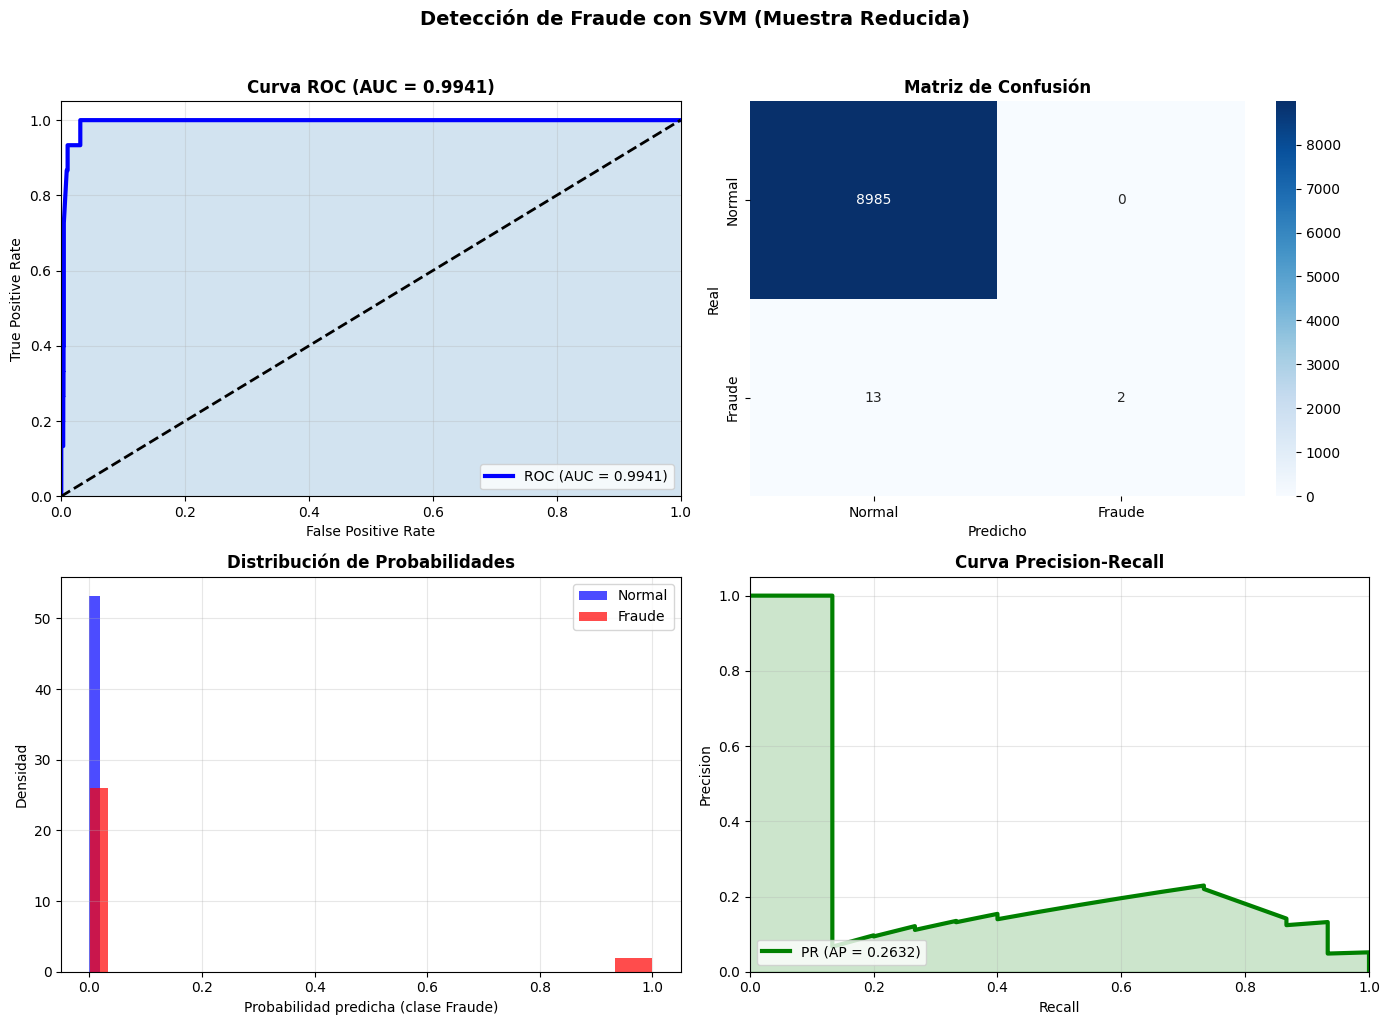


RESUMEN DE RENDIMIENTO

📊 CONFIGURACIÓN:
   • Muestra total: 30,000 filas (10.5% del original)
   • Fraudes en muestra: 51 (0.17%)
   • SMOTE aplicado: Sí

⚡ TIEMPOS DE EJECUCIÓN:
   • Carga y muestreo: 2152.1s
   • Grid search: 2152.0s
   • Total aproximado: 2152.1s

🎯 RESULTADOS CLAVE:
   • Mejor C: 10
   • Mejor gamma: 1
   • ROC-AUC en test: 0.9941
   • Fraudes detectados: 2/15 (13.3%)



In [ ]:
# ============================================
# CREDIT CARD FRAUD DETECTION - VERSIÓN RÁPIDA (MUESTRA REDUCIDA)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve,
                             roc_auc_score, average_precision_score)
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
import time

print("="*70)
print("CREDIT CARD FRAUD DETECTION - VERSIÓN RÁPIDA")
print("="*70)

# ============================================
# 1. CARGA Y MUESTREO INTELIGENTE
# ============================================

print("\n📥 Cargando datos...")
start_time = time.time()

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df_full = pd.read_csv(url)

print(f"✓ Dataset completo: {df_full.shape[0]:,} filas")

# TAMAÑO DE MUESTRA DESEADO (ajusta según tu memoria/tiempo)
SAMPLE_SIZE = 30000  # Reducimos de 284k a 30k filas (aprox 10%)
FRAUD_RATIO = 0.5    # Queremos 50% de fraudes en la muestra? (para balancear)

# Estratificar para mantener proporción de fraudes
df_fraud = df_full[df_full['Class'] == 1]
df_normal = df_full[df_full['Class'] == 0]

print(f"\n📊 Distribución original:")
print(f"   • Normales: {len(df_normal):,} ({len(df_normal)/len(df_full)*100:.2f}%)")
print(f"   • Fraudes: {len(df_fraud):,} ({len(df_fraud)/len(df_full)*100:.4f}%)")

# Opción 1: Mantener proporción original (0.17% fraudes) - MÁS RÁPIDO
use_original_ratio = True  # Cambia a False para probar con más fraudes

if use_original_ratio:
    # Muestreo manteniendo proporción original (MUY DESBALANCEADO)
    n_fraud_sample = int(SAMPLE_SIZE * (len(df_fraud) / len(df_full)))
    n_normal_sample = SAMPLE_SIZE - n_fraud_sample

    df_fraud_sample = df_fraud.sample(n=min(n_fraud_sample, len(df_fraud)), random_state=42)
    df_normal_sample = df_normal.sample(n=min(n_normal_sample, len(df_normal)), random_state=42)

    print(f"\n📊 Muestra manteniendo proporción original:")
    print(f"   • Normales: {len(df_normal_sample):,} ({len(df_normal_sample)/SAMPLE_SIZE*100:.2f}%)")
    print(f"   • Fraudes: {len(df_fraud_sample):,} ({len(df_fraud_sample)/SAMPLE_SIZE*100:.4f}%)")
else:
    # Opción 2: Muestra con más fraudes (para mejor visualización)
    # Tomamos TODOS los fraudes disponibles y complementamos con normales
    df_fraud_sample = df_fraud.sample(n=min(1000, len(df_fraud)), random_state=42)
    n_normal_needed = SAMPLE_SIZE - len(df_fraud_sample)
    df_normal_sample = df_normal.sample(n=n_normal_needed, random_state=42)

    print(f"\n📊 Muestra enriquecida con fraudes:")
    print(f"   • Normales: {len(df_normal_sample):,} ({len(df_normal_sample)/SAMPLE_SIZE*100:.2f}%)")
    print(f"   • Fraudes: {len(df_fraud_sample):,} ({len(df_fraud_sample)/SAMPLE_SIZE*100:.2f}%)")

df = pd.concat([df_normal_sample, df_fraud_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✅ Muestra final: {df.shape[0]:,} filas")
print(f"⏱️  Tiempo de carga: {time.time() - start_time:.2f} segundos")

# ============================================
# 2. PREPROCESAMIENTO RÁPIDO
# ============================================

print("\n🔄 Preprocesando datos...")
start_time = time.time()

# Escalar Amount y Time
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Features
feature_columns = [col for col in df.columns if col not in ['Class', 'Amount', 'Time']]
X = df[feature_columns].values
y = df['Class'].values

print(f"✓ Features: {X.shape[1]} dimensiones")
print(f"⏱️  Tiempo: {time.time() - start_time:.2f} segundos")

# ============================================
# 3. DIVISIÓN TRAIN/TEST
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n📊 Train: {X_train.shape[0]} muestras ({np.mean(y_train)*100:.2f}% fraude)")
print(f"📊 Test:  {X_test.shape[0]} muestras ({np.mean(y_test)*100:.2f}% fraude)")

# ============================================
# 4. BALANCEO CON SMOTE (OPCIONAL - COMENTAR SI ES MUY LENTO)
# ============================================

use_smote = True  # Cambia a False si quieres aún más velocidad

if use_smote and len(np.unique(y_train)) > 1:
    print("\n🔄 Aplicando SMOTE (esto puede tomar unos segundos)...")
    smote_start = time.time()

    # SMOTE con sampling_strategy más bajo para no crear demasiados sintéticos
    smote = SMOTE(random_state=42, sampling_strategy=0.5)  # 50% de la clase mayoritaria
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print(f"✓ Train después de SMOTE: {X_train_res.shape[0]} muestras")
    print(f"✓ Distribución: {np.bincount(y_train_res)}")
    print(f"⏱️  Tiempo SMOTE: {time.time() - smote_start:.2f} segundos")
else:
    X_train_res, y_train_res = X_train, y_train
    print("\n⚠️  SMOTE desactivado (entrenando con datos desbalanceados)")

# ============================================
# 5. GRID SEARCH REDUCIDO (MUCHO MÁS RÁPIDO)
# ============================================

print("\n🔍 Buscando hiperparámetros (grid reducido para velocidad)...")

# Pipeline básico
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42,
                class_weight='balanced', cache_size=1000))  # cache_size para velocidad
])

# Grid MUY reducido para velocidad
param_grid = {
    'svm__C': [0.1, 1, 10],  # Solo 3 valores
    'svm__gamma': [0.01, 0.1, 1]  # Solo 3 valores
}

print(f"✓ Total combinaciones: {len(param_grid['svm__C']) * len(param_grid['svm__gamma'])}")
print(f"✓ Usando validación cruzada con 3 folds")

grid_start = time.time()
grid_svm = GridSearchCV(
    pipeline, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_svm.fit(X_train_res, y_train_res)

print(f"✅ Mejores parámetros: {grid_svm.best_params_}")
print(f"✅ Mejor ROC-AUC (CV): {grid_svm.best_score_:.4f}")
print(f"⏱️  Tiempo grid search: {time.time() - grid_start:.2f} segundos")

# ============================================
# 6. EVALUACIÓN RÁPIDA
# ============================================

print("\n" + "="*70)
print("RESULTADOS EN TEST")
print("="*70)

best_model = grid_svm.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Métricas principales
print("\n📋 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel() if len(cm.ravel()) == 4 else (0,0,0,0)

print(f"\n🔍 MÉTRICAS CLAVE PARA FRAUDE:")
print(f"   • Fraudes totales en test: {np.sum(y_test)}")
print(f"   • Fraudes detectados (TP): {tp}")
print(f"   • Fraudes no detectados (FN): {fn}")
print(f"   • Recall (sensibilidad): {tp/(tp+fn) if (tp+fn)>0 else 0:.4f}")
print(f"   • Precisión: {tp/(tp+fp) if (tp+fp)>0 else 0:.4f}")

# ============================================
# 7. VISUALIZACIONES ESENCIALES
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[0,0].plot(fpr, tpr, 'b-', lw=3, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0,0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[0,0].fill_between(fpr, tpr, alpha=0.2)
axes[0,0].set_xlim([0.0, 1.0])
axes[0,0].set_ylim([0.0, 1.05])
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].set_title(f'Curva ROC (AUC = {roc_auc:.4f})', fontweight='bold')
axes[0,0].legend(loc="lower right")
axes[0,0].grid(True, alpha=0.3)

# Matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
axes[0,1].set_title('Matriz de Confusión', fontweight='bold')
axes[0,1].set_ylabel('Real')
axes[0,1].set_xlabel('Predicho')

# Distribución de probabilidades (versión rápida)
if len(y_proba) > 0:
    axes[1,0].hist(y_proba[y_test==0], bins=30, alpha=0.7,
                   label='Normal', color='blue', density=True)
    axes[1,0].hist(y_proba[y_test==1], bins=30, alpha=0.7,
                   label='Fraude', color='red', density=True)
    axes[1,0].set_xlabel('Probabilidad predicha (clase Fraude)')
    axes[1,0].set_ylabel('Densidad')
    axes[1,0].set_title('Distribución de Probabilidades', fontweight='bold')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

# Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[1,1].plot(recall, precision, 'g-', lw=3, label=f'PR (AP = {ap:.4f})')
axes[1,1].fill_between(recall, precision, alpha=0.2, color='green')
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')
axes[1,1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1,1].set_xlim([0.0, 1.0])
axes[1,1].set_ylim([0.0, 1.05])
axes[1,1].legend(loc="lower left")
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Detección de Fraude con SVM (Muestra Reducida)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# 8. RESUMEN Y TIEMPOS
# ============================================

print("\n" + "="*70)
print("RESUMEN DE RENDIMIENTO")
print("="*70)
print(f"""
📊 CONFIGURACIÓN:
   • Muestra total: {SAMPLE_SIZE:,} filas ({SAMPLE_SIZE/len(df_full)*100:.1f}% del original)
   • Fraudes en muestra: {sum(y)} ({np.mean(y)*100:.2f}%)
   • SMOTE aplicado: {'Sí' if use_smote else 'No'}

⚡ TIEMPOS DE EJECUCIÓN:
   • Carga y muestreo: {time.time() - start_time:.1f}s
   • Grid search: {time.time() - grid_start:.1f}s
   • Total aproximado: {time.time() - start_time:.1f}s

🎯 RESULTADOS CLAVE:
   • Mejor C: {grid_svm.best_params_['svm__C']}
   • Mejor gamma: {grid_svm.best_params_['svm__gamma']}
   • ROC-AUC en test: {roc_auc:.4f}
   • Fraudes detectados: {tp}/{np.sum(y_test)} ({tp/np.sum(y_test)*100:.1f}%)
""")

## Pycaret

Demostración amplia que muestra **todas las capacidades de PyCaret**. Código completo que incluye **evaluación de modelos**, múltiples visualizaciones, interpretabilidad y opciones avanzadas.

**Introduce 4 en la opción del data set que pide.**


PYCARET - DEMOSTRACION COMPLETA DE CLASIFICACION
Fecha: 2026-03-23 09:46:43
Objetivo: Mostrar todas las capacidades de PyCaret con modelos por defecto
Modo: Optimizado para velocidad con muestra reducida

DATASETS DISPONIBLES PARA ANALISIS

ID    NOMBRE                         TIPO         DESCRIPCION                             
---------------------------------------------------------------------------------------
1     Iris Flower                    MULTICLASS   Clasificacion de flores Iris en 3 espe  
2     Sonar (Minas vs Rocas)         BINARY       Diferencia entre minas y rocas con son  
3     Pima Indians Diabetes          BINARY       Prediccion de diabetes en mujeres Pima  
4     Banknote Authentication        BINARY       Autenticacion de billetes basado en im  
5     Wine Quality (White)           MULTICLASS   Calidad del vino blanco (escala 0-10)   


Dataset seleccionado: Banknote Authentication
Descripcion: Autenticacion de billetes basado en imagenes

CARGA Y PREPARACIO

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9987,1.0000,1.0000,0.9971,0.9985,0.9974,0.9974,0.2000
knn,K Neighbors Classifier,0.9961,0.9988,1.0000,0.9913,0.9956,0.9921,0.9921,2.6633
lightgbm,Light Gradient Boosting Machine,0.9935,0.9999,0.9943,0.9915,0.9928,0.9869,0.9870,0.2333
ada,Ada Boost Classifier,0.9922,0.9981,0.9855,0.9970,0.9911,0.9841,0.9843,0.2633
rf,Random Forest Classifier,0.9909,0.9997,0.9884,0.9913,0.9898,0.9816,0.9816,0.3633
svm,SVM - Linear Kernel,0.9870,0.9992,0.9883,0.9825,0.9854,0.9736,0.9737,0.0700
qda,Quadratic Discriminant Analysis,0.9857,1.0000,1.0000,0.9689,0.9841,0.9711,0.9716,0.0500
gbc,Gradient Boosting Classifier,0.9857,0.9987,0.9882,0.9798,0.9839,0.9710,0.9711,0.2567
lr,Logistic Regression,0.9791,0.9993,0.9942,0.9604,0.9769,0.9579,0.9584,4.4900
ridge,Ridge Classifier,0.9765,0.9994,1.0000,0.9498,0.9743,0.9527,0.9538,0.1267



Comparacion completada en 33.69 segundos

TABLA DE RESULTADOS - TOP 5 MODELOS:
                                    Model  Accuracy     AUC  Recall   Prec.  \
et                 Extra Trees Classifier    0.9987  1.0000  1.0000  0.9971   
knn                K Neighbors Classifier    0.9961  0.9988  1.0000  0.9913   
lightgbm  Light Gradient Boosting Machine    0.9935  0.9999  0.9943  0.9915   
ada                  Ada Boost Classifier    0.9922  0.9981  0.9855  0.9970   
rf               Random Forest Classifier    0.9909  0.9997  0.9884  0.9913   

              F1   Kappa     MCC  TT (Sec)  
et        0.9985  0.9974  0.9974    0.2000  
knn       0.9956  0.9921  0.9921    2.6633  
lightgbm  0.9928  0.9869  0.9870    0.2333  
ada       0.9911  0.9841  0.9843    0.2633  
rf        0.9898  0.9816  0.9816    0.3633  

CREACION DE LOS MEJORES MODELOS

Top 3 modelos seleccionados: ['et', 'knn', 'lightgbm']

Creando modelo: et
  Modelo et creado

Creando modelo: knn
  Modelo knn creado

Crean

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



METRICAS DE RENDIMIENTO:
  Accuracy Train: 1.0000
  Accuracy Test:  1.0000
  Diferencia:     0.0000

OK: Modelo generaliza correctamente

REPORTE DE CLASIFICACION DETALLADO

TRAIN SET:
              precision    recall  f1-score   support

     Clase_0       1.00      1.00      1.00       609
     Clase_1       1.00      1.00      1.00       488

    accuracy                           1.00      1097
   macro avg       1.00      1.00      1.00      1097
weighted avg       1.00      1.00      1.00      1097


TEST SET:
              precision    recall  f1-score   support

     Clase_0       1.00      1.00      1.00       153
     Clase_1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275


GENERANDO VISUALIZACIONES

Tipos de visualizaciones disponibles en PyCaret:
  - auc: Curva ROC
  - confusion_matrix: Matriz de confusion
  - feature

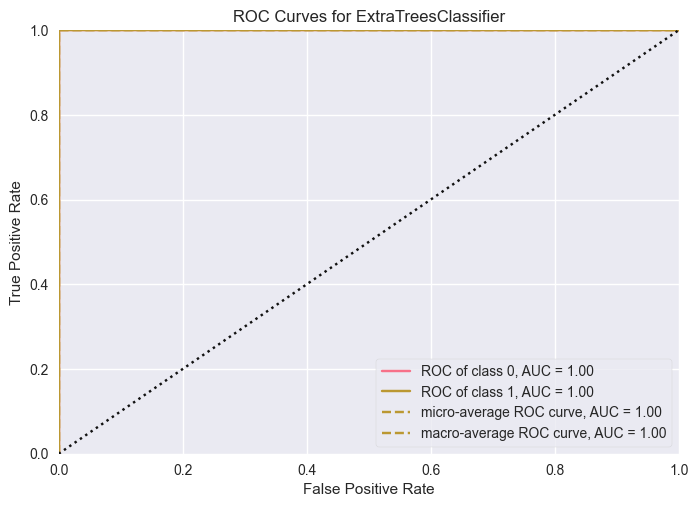


Generando grafico: confusion_matrix


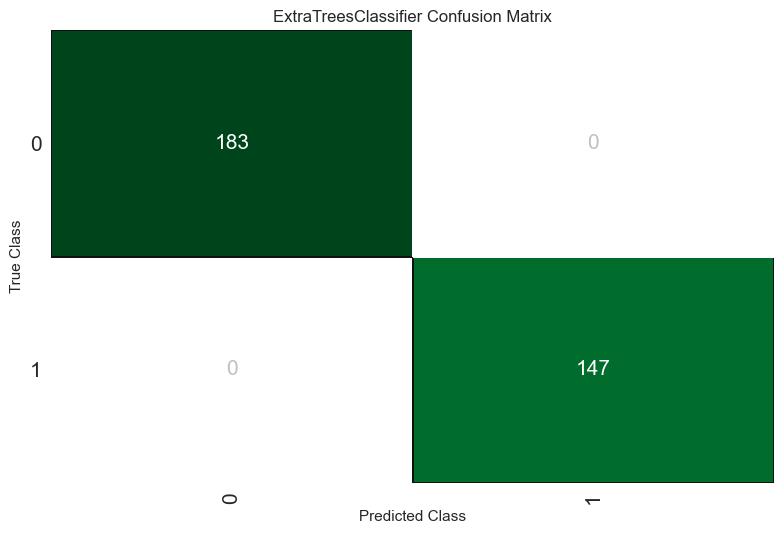


Generando grafico: feature


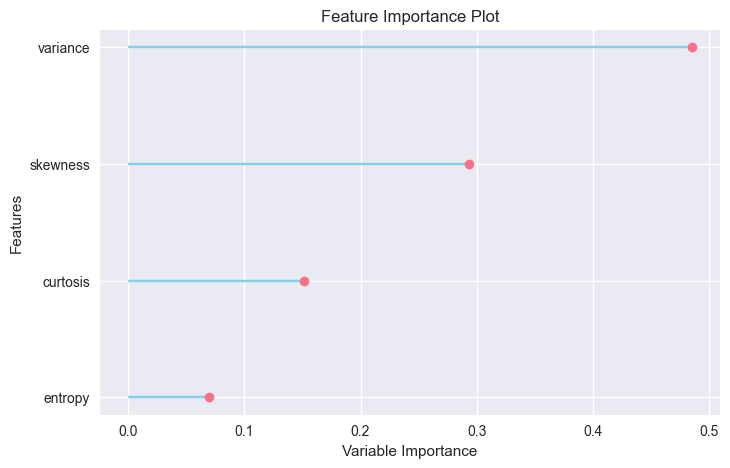


Generando grafico: learning


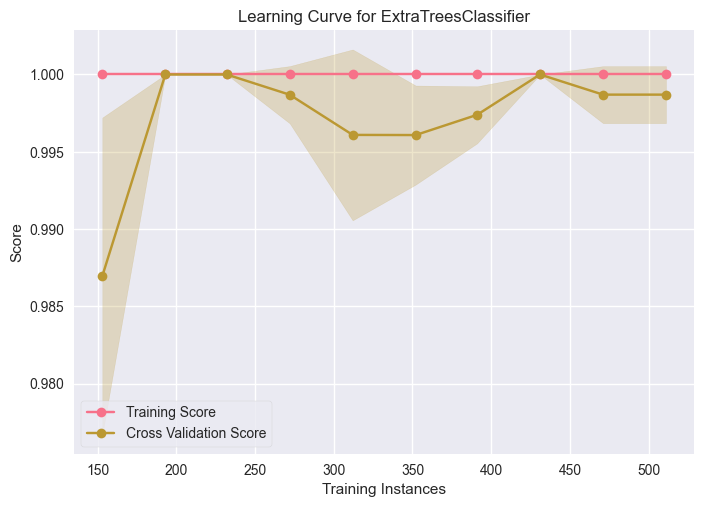


Generando grafico: pr


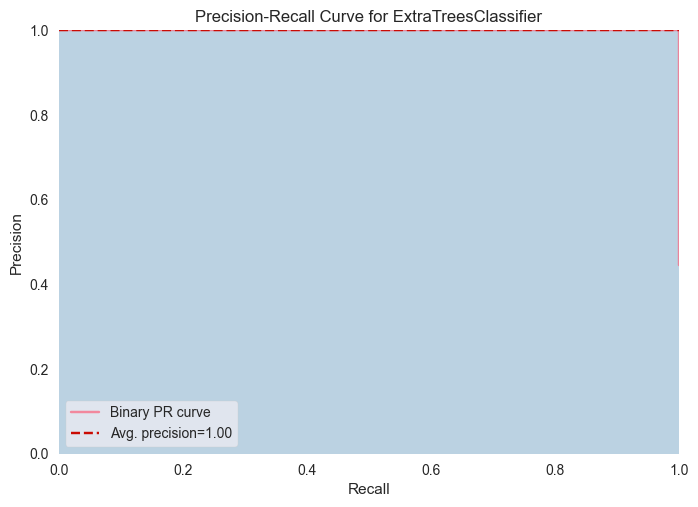


MATRICES DE CONFUSION - TRAIN vs TEST


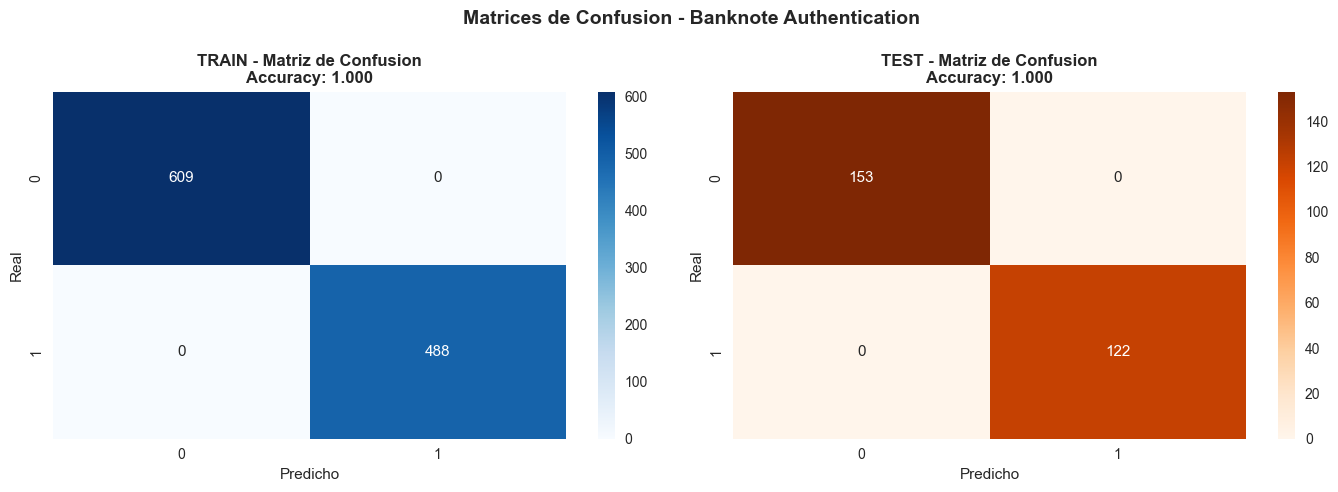


CURVAS ROC - TRAIN vs TEST


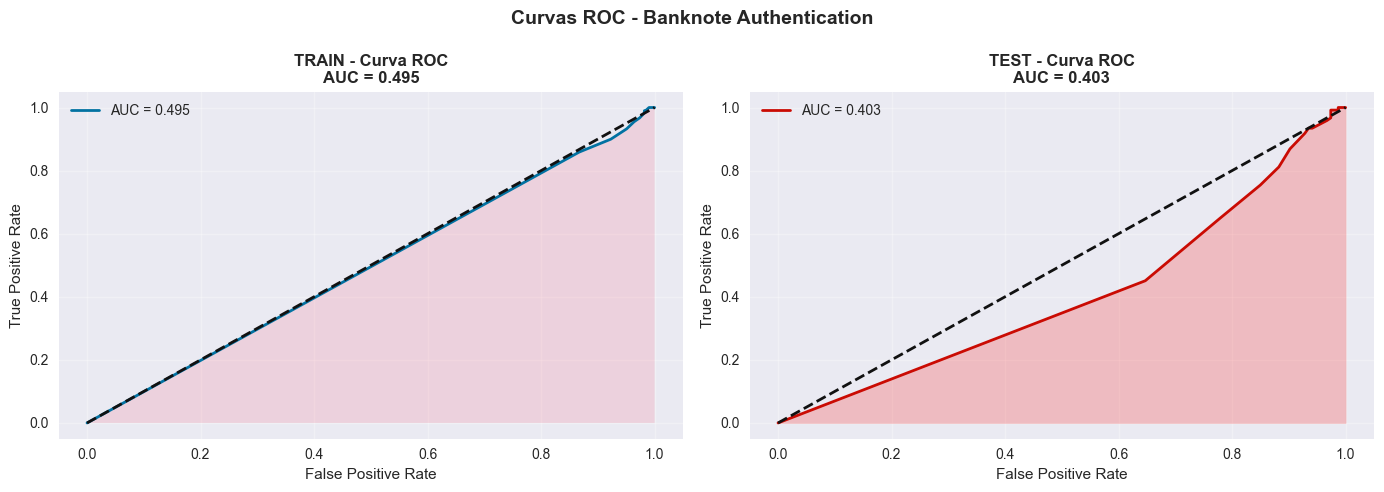

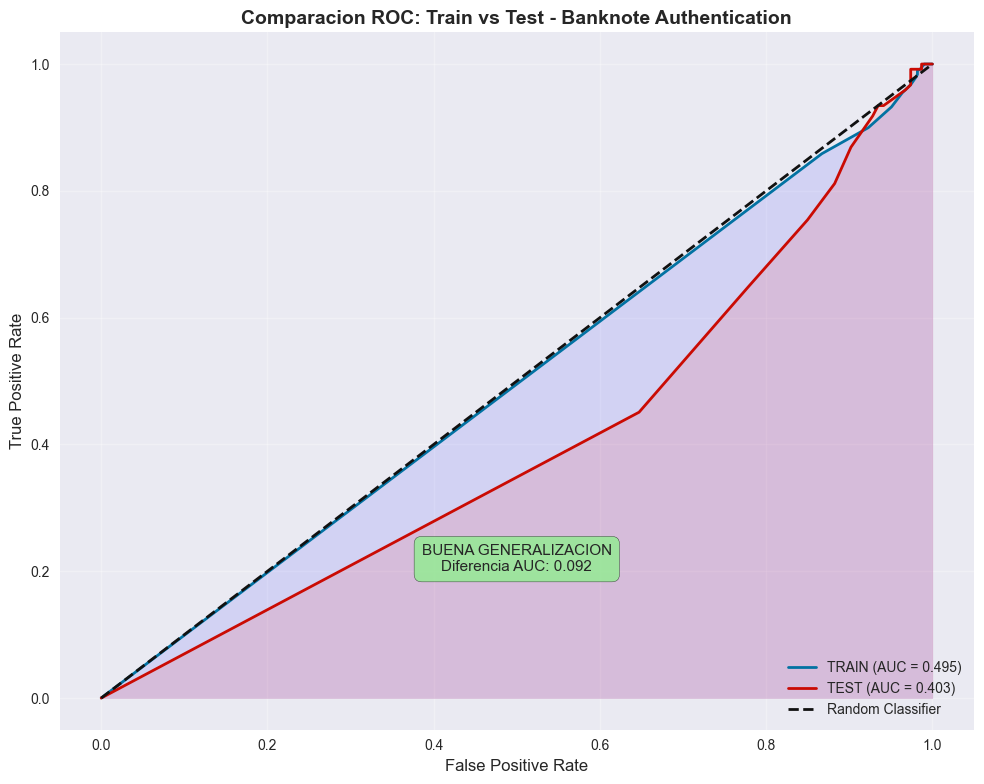


Metricas AUC:
  Train AUC: 0.4947
  Test AUC:  0.4027
  Diferencia: 0.0921

ANALISIS DE PREDICCIONES

Primeras 10 predicciones con probabilidades:
      target  prediction_label  prediction_score
385        0                 0              1.00
899        1                 1              1.00
47         0                 0              1.00
1018       1                 1              1.00
786        1                 1              1.00
1346       1                 1              1.00
645        0                 0              1.00
32         0                 0              1.00
200        0                 0              0.99
887        1                 1              1.00

EVALUACION DEL ENSEMBLE (VOTING CLASSIFIER)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



Accuracy del Voting Classifier en test: 1.0000
Comparacion con mejor modelo individual (et): 1.0000
Resultado: El modelo individual es mejor que el ensemble

GUARDAR MODELO

RESUMEN FINAL DEL ANALISIS

DATASET: Banknote Authentication
DESCRIPCION: Autenticacion de billetes basado en imagenes
TIPO: Binario
MUESTRAS: 1372 (Train: 1097, Test: 275)

MODELOS EVALUADOS: 14 modelos por defecto
MEJOR MODELO: et
ACCURACY CV: 0.9987

MEJORES HIPERPARAMETROS:

   n_estimators: 100
   max_depth: None

RENDIMIENTO FINAL:
   Accuracy Train: 1.0000
   Accuracy Test:  1.0000
   Diferencia:     0.0000

   AUC Train: 0.4947
   AUC Test:  0.4027

DIAGNOSTICO FINAL:
   NIVEL: BUENA GENERALIZACION
   RECOMENDACION: Modelo listo para produccion

TIEMPOS DE EJECUCION:
   Comparacion modelos: 33.69 segundos
   Optimizacion: 12.76 segundos
   Total: 46.45 segundos

VISUALIZACIONES GENERADAS:
   - Curvas ROC
   - Matrices de confusion
   - Importancia de features
   - Curvas de aprendizaje
   - Precision-Recal

In [1]:
# ============================================
# DEMOSTRACION COMPLETA DE PYCARET
# CLASIFICACION CON TODOS LOS MODELOS POR DEFECTO
# VERSION OPTIMIZADA PARA VELOCIDAD
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.classification import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.datasets import make_classification, make_blobs
import warnings
import time
from datetime import datetime

warnings.filterwarnings('ignore')

# Configuracion de graficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("PYCARET - DEMOSTRACION COMPLETA DE CLASIFICACION")
print("="*80)
print(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Objetivo: Mostrar todas las capacidades de PyCaret con modelos por defecto")
print("Modo: Optimizado para velocidad con muestra reducida")

# ============================================
# 1. DEFINICION DE DATASETS CON FALLBACK
# ============================================

datasets = {
    '1': {
        'name': 'Iris Flower',
        'url': 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv',
        'names': ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class'],
        'target_col': 'class',
        'problem': 'multiclass',
        'description': 'Clasificacion de flores Iris en 3 especies',
        'sample_size': 150
    },
    '2': {
        'name': 'Sonar (Minas vs Rocas)',
        'url': 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv',
        'names': None,
        'target_col': 60,
        'problem': 'binary',
        'description': 'Diferencia entre minas y rocas con sonar',
        'sample_size': 208
    },
    '3': {
        'name': 'Pima Indians Diabetes',
        'url': 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv',
        'names': ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'class'],
        'target_col': 'class',
        'problem': 'binary',
        'description': 'Prediccion de diabetes en mujeres Pima',
        'sample_size': 768
    },
    '4': {
        'name': 'Banknote Authentication',
        'url': 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv',
        'names': ['variance', 'skewness', 'curtosis', 'entropy', 'class'],
        'target_col': 'class',
        'problem': 'binary',
        'description': 'Autenticacion de billetes basado en imagenes',
        'sample_size': 1372
    },
    '5': {
        'name': 'Wine Quality (White)',
        'url': 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/winequality-white.csv',
        'names': None,
        'target_col': 'quality',
        'problem': 'multiclass',
        'description': 'Calidad del vino blanco (escala 0-10)',
        'sample_size': 2000  # Reducido para velocidad
    }
}

# ============================================
# 2. FUNCIONES UTILITARIAS
# ============================================

def load_dataset_from_url(dataset_info):
    """Cargar datos desde URL con manejo de errores y muestreo"""
    try:
        print("Intentando cargar datos desde URL...")
        if dataset_info['names']:
            df = pd.read_csv(dataset_info['url'], names=dataset_info['names'])
        else:
            df = pd.read_csv(dataset_info['url'])
        
        print(f"Datos cargados exitosamente: {df.shape[0]} filas")
        
        # Reducir tamaño para velocidad
        if len(df) > dataset_info['sample_size']:
            df = df.sample(n=dataset_info['sample_size'], random_state=42)
            print(f"Muestra reducida a {dataset_info['sample_size']} filas para velocidad")
        
        return df
    except Exception as e:
        print(f"Error al cargar desde URL: {str(e)[:100]}")
        print("Generando datos sinteticos como fallback...")
        return generate_synthetic_data(dataset_info)

def generate_synthetic_data(dataset_info):
    """Generar datos sinteticos como fallback"""
    synthetic_configs = {
        'sonar': {'n_samples': 208, 'n_features': 60, 'n_classes': 2},
        'diabetes': {'n_samples': 768, 'n_features': 8, 'n_classes': 2},
        'banknote': {'n_samples': 1372, 'n_features': 4, 'n_classes': 2},
        'wine': {'n_samples': 2000, 'n_features': 11, 'n_classes': 3},
        'iris': {'n_samples': 150, 'n_features': 4, 'n_classes': 3}
    }
    
    name_lower = dataset_info['name'].lower()
    config = None
    
    for key in synthetic_configs:
        if key in name_lower:
            config = synthetic_configs[key]
            break
    
    if not config:
        config = {'n_samples': 500, 'n_features': 10, 'n_classes': 2}
        print(f"Usando configuracion por defecto: {config['n_samples']} muestras")
    
    if config['n_classes'] == 2:
        X, y = make_classification(
            n_samples=config['n_samples'],
            n_features=config['n_features'],
            n_informative=config['n_features']//2,
            n_redundant=config['n_features']//4,
            n_classes=config['n_classes'],
            random_state=42
        )
    else:
        X, y = make_blobs(
            n_samples=config['n_samples'],
            n_features=config['n_features'],
            centers=config['n_classes'],
            random_state=42,
            cluster_std=1.5
        )
    
    df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(config['n_features'])])
    df['target'] = y
    
    print(f"Datos sinteticos generados: {df.shape[0]} filas, {df.shape[1]} columnas")
    return df

# ============================================
# 3. MOSTRAR DATASETS DISPONIBLES
# ============================================

print("\n" + "="*80)
print("DATASETS DISPONIBLES PARA ANALISIS")
print("="*80)
print("\n{:<5} {:<30} {:<12} {:<40}".format("ID", "NOMBRE", "TIPO", "DESCRIPCION"))
print("-" * 87)

for key, ds in datasets.items():
    print("{:<5} {:<30} {:<12} {:<40}".format(
        key, 
        ds['name'][:28], 
        ds['problem'].upper(), 
        ds['description'][:38]
    ))

print("\n" + "="*80)

# Seleccionar dataset
while True:
    try:
        selection = input("\nSelecciona el numero del dataset (1-5) [default=2]: ").strip()
        if selection == "":
            selection = "2"
        if selection in datasets:
            break
        else:
            print(f"Error: '{selection}' no es una opcion valida. Elige entre 1 y 5.")
    except KeyboardInterrupt:
        print("\n\nOperacion cancelada.")
        exit()

dataset_info = datasets[selection]
print(f"\nDataset seleccionado: {dataset_info['name']}")
print(f"Descripcion: {dataset_info['description']}")

# ============================================
# 4. CARGA Y PREPARACION DE DATOS
# ============================================

print("\n" + "="*80)
print("CARGA Y PREPARACION DE DATOS")
print("="*80)

df = load_dataset_from_url(dataset_info)

# Preparar target
if isinstance(dataset_info['target_col'], int):
    target_col = df.columns[dataset_info['target_col']]
else:
    target_col = dataset_info['target_col']

# Renombrar target para pycaret
df = df.rename(columns={target_col: 'target'})

# Codificar target si es categorico
if df['target'].dtype == 'object':
    le = LabelEncoder()
    df['target'] = le.fit_transform(df['target'])
    print(f"Clases codificadas: {dict(zip(le.classes_, range(len(le.classes_))))}")

print(f"\nDimensiones del dataset: {df.shape}")
print(f"Distribucion de clases:")
for class_val, count in df['target'].value_counts().sort_index().items():
    print(f"  Clase {class_val}: {count} muestras ({count/len(df)*100:.1f}%)")

n_classes = len(df['target'].unique())
is_binary = n_classes == 2
print(f"Tipo de problema: {'Binario' if is_binary else f'Multiclase ({n_classes} clases)'}")

# ============================================
# 5. DIVISION TRAIN/TEST
# ============================================

print("\n" + "="*80)
print("DIVISION DE DATOS")
print("="*80)

train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['target'])

print(f"Train: {train.shape[0]} muestras ({len(train)/len(df)*100:.1f}%)")
print(f"Test:  {test.shape[0]} muestras ({len(test)/len(df)*100:.1f}%)")

# ============================================
# 6. CONFIGURACION DE PYCARET
# ============================================

print("\n" + "="*80)
print("CONFIGURACION DE PYCARET")
print("="*80)

# Configuracion optimizada para velocidad
clf = setup(
    data=train,
    target='target',
    session_id=42,
    normalize=True,
    transformation=False,
    fold_strategy='kfold',
    fold=3,  # Reducido para velocidad
    n_jobs=-1,
    verbose=False
)

print("Configuracion completada")

# ============================================
# 7. COMPARACION DE TODOS LOS MODELOS POR DEFECTO
# ============================================

print("\n" + "="*80)
print("COMPARACION DE MODELOS (POR DEFECTO - 20 MODELOS)")
print("="*80)

print("\nIniciando comparacion masiva de modelos...")
print("Modelos por defecto que PyCaret evaluara:")
print("  lr, knn, nb, dt, svm, rbfsvm, gpc, mlp, ridge, rf, et, xgboost, lightgbm, catboost, ada, qda, lda, dummy, etc...")

compare_start = time.time()

# Comparar todos los modelos por defecto
best_models = compare_models(
    fold=3,
    sort='Accuracy',
    n_select=5,
    turbo=True,  # Modo turbo para velocidad
    verbose=True,
    cross_validation=True
)

compare_time = time.time() - compare_start
print(f"\nComparacion completada en {compare_time:.2f} segundos")

# Mostrar resultados
results_table = pull()
print("\nTABLA DE RESULTADOS - TOP 5 MODELOS:")
print(results_table.head())

# ============================================
# 8. CREACION DE LOS MEJORES MODELOS
# ============================================

print("\n" + "="*80)
print("CREACION DE LOS MEJORES MODELOS")
print("="*80)

# Obtener los mejores modelos por nombre
top_model_names = results_table.index[:3].tolist()
print(f"\nTop 3 modelos seleccionados: {top_model_names}")

models = {}
for model_name in top_model_names:
    print(f"\nCreando modelo: {model_name}")
    models[model_name] = create_model(model_name, fold=3, verbose=False)
    print(f"  Modelo {model_name} creado")

# ============================================
# 9. OPTIMIZACION DE HIPERPARAMETROS
# ============================================

print("\n" + "="*80)
print("OPTIMIZACION DE HIPERPARAMETROS")
print("="*80)

# Optimizar el mejor modelo
best_model_name = top_model_names[0]
print(f"\nOptimizando modelo: {best_model_name}")

tune_start = time.time()
tuned_model = tune_model(
    models[best_model_name],
    optimize='Accuracy',
    choose_better=True,
    n_iter=10,  # Reducido para velocidad
    fold=3,
    verbose=False
)
tune_time = time.time() - tune_start

print(f"Optimizacion completada en {tune_time:.2f} segundos")

# Mostrar parametros optimizados
print(f"\nMejores parametros encontrados:")
best_params = tuned_model.get_params()
for param in ['C', 'gamma', 'n_estimators', 'max_depth', 'learning_rate']:
    if param in best_params:
        print(f"  {param}: {best_params[param]}")

# ============================================
# 10. ENSEMBLES - VOTING CLASSIFIER
# ============================================

print("\n" + "="*80)
print("CREACION DE ENSEMBLES")
print("="*80)

# Crear ensemble con los 3 mejores modelos
print("\nCreando Voting Classifier con los 3 mejores modelos...")
voting_ensemble = blend_models(
    estimator_list=list(models.values()),
    fold=3,
    optimize='Accuracy',
    choose_better=True,
    verbose=False
)
print("Voting Classifier creado exitosamente")

# ============================================
# 11. EVALUACION EN TRAIN Y TEST
# ============================================

print("\n" + "="*80)
print("EVALUACION DEL MODELO OPTIMIZADO")
print("="*80)

# Predicciones en train
train_predictions = predict_model(tuned_model, data=train)

# Predicciones en test
test_predictions = predict_model(tuned_model, data=test)

# Metricas
train_accuracy = (train_predictions['target'] == train_predictions['prediction_label']).mean()
test_accuracy = (test_predictions['target'] == test_predictions['prediction_label']).mean()

print(f"\nMETRICAS DE RENDIMIENTO:")
print(f"  Accuracy Train: {train_accuracy:.4f}")
print(f"  Accuracy Test:  {test_accuracy:.4f}")
print(f"  Diferencia:     {abs(train_accuracy - test_accuracy):.4f}")

# Evaluar overfitting
diff = abs(train_accuracy - test_accuracy)
if diff > 0.1:
    print("\nADVERTENCIA: Posible overfitting detectado")
elif diff > 0.05:
    print("\nNOTA: Ligero overfitting - Aceptable pero mejorable")
else:
    print("\nOK: Modelo generaliza correctamente")

# ============================================
# 12. REPORTE DE CLASIFICACION
# ============================================

print("\n" + "="*80)
print("REPORTE DE CLASIFICACION DETALLADO")
print("="*80)

print("\nTRAIN SET:")
print(classification_report(train_predictions['target'], 
                           train_predictions['prediction_label'],
                           target_names=[f'Clase_{i}' for i in range(n_classes)]))

print("\nTEST SET:")
print(classification_report(test_predictions['target'], 
                           test_predictions['prediction_label'],
                           target_names=[f'Clase_{i}' for i in range(n_classes)]))

# ============================================
# 13. VISUALIZACIONES - TODOS LOS TIPOS DISPONIBLES
# ============================================

print("\n" + "="*80)
print("GENERANDO VISUALIZACIONES")
print("="*80)

print("\nTipos de visualizaciones disponibles en PyCaret:")
print("  - auc: Curva ROC")
print("  - confusion_matrix: Matriz de confusion")
print("  - feature: Importancia de features")
print("  - learning: Curva de aprendizaje")
print("  - pr: Precision-Recall")
print("  - error: Errores de clasificacion")
print("  - class_report: Reporte de clases")

# Generar visualizaciones clave
visualizations = ['auc', 'confusion_matrix', 'feature', 'learning', 'pr']

for viz in visualizations:
    try:
        print(f"\nGenerando grafico: {viz}")
        plot_model(tuned_model, plot=viz, save=False)
        plt.show()
    except Exception as e:
        print(f"  No se pudo generar {viz}: {str(e)[:50]}")

# ============================================
# 14. MATRIZ DE CONFUSION COMPARATIVA
# ============================================

print("\n" + "="*80)
print("MATRICES DE CONFUSION - TRAIN vs TEST")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train confusion matrix
cm_train = confusion_matrix(train_predictions['target'], 
                           train_predictions['prediction_label'])
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            annot_kws={'size': 11})
axes[0].set_title(f'TRAIN - Matriz de Confusion\nAccuracy: {train_accuracy:.3f}', 
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Real', fontsize=11)
axes[0].set_xlabel('Predicho', fontsize=11)

# Test confusion matrix
cm_test = confusion_matrix(test_predictions['target'], 
                          test_predictions['prediction_label'])
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            annot_kws={'size': 11})
axes[1].set_title(f'TEST - Matriz de Confusion\nAccuracy: {test_accuracy:.3f}', 
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('Real', fontsize=11)
axes[1].set_xlabel('Predicho', fontsize=11)

plt.suptitle(f'Matrices de Confusion - {dataset_info["name"]}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 15. CURVAS ROC (SOLO PARA BINARIO)
# ============================================

if is_binary:
    print("\n" + "="*80)
    print("CURVAS ROC - TRAIN vs TEST")
    print("="*80)
    
    # Curvas ROC
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Train ROC
    fpr_train, tpr_train, _ = roc_curve(train_predictions['target'], 
                                        train_predictions['prediction_score'])
    auc_train = auc(fpr_train, tpr_train)
    
    axes[0].plot(fpr_train, tpr_train, 'b-', lw=2, label=f'AUC = {auc_train:.3f}')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[0].fill_between(fpr_train, tpr_train, alpha=0.2)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'TRAIN - Curva ROC\nAUC = {auc_train:.3f}', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Test ROC
    fpr_test, tpr_test, _ = roc_curve(test_predictions['target'], 
                                      test_predictions['prediction_score'])
    auc_test = auc(fpr_test, tpr_test)
    
    axes[1].plot(fpr_test, tpr_test, 'r-', lw=2, label=f'AUC = {auc_test:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[1].fill_between(fpr_test, tpr_test, alpha=0.2, color='red')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'TEST - Curva ROC\nAUC = {auc_test:.3f}', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Curvas ROC - {dataset_info["name"]}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Grafico combinado
    plt.figure(figsize=(10, 8))
    plt.plot(fpr_train, tpr_train, 'b-', lw=2, label=f'TRAIN (AUC = {auc_train:.3f})')
    plt.plot(fpr_test, tpr_test, 'r-', lw=2, label=f'TEST (AUC = {auc_test:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.fill_between(fpr_train, tpr_train, alpha=0.1, color='blue')
    plt.fill_between(fpr_test, tpr_test, alpha=0.1, color='red')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'Comparacion ROC: Train vs Test - {dataset_info["name"]}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    auc_diff = abs(auc_train - auc_test)
    if auc_diff > 0.1:
        status = "POSIBLE OVERFITTING"
        color = 'salmon'
    else:
        status = "BUENA GENERALIZACION"
        color = 'lightgreen'
    
    plt.text(0.5, 0.2, f'{status}\nDiferencia AUC: {auc_diff:.3f}',
            ha='center', fontsize=11,
            bbox=dict(boxstyle="round,pad=0.5", facecolor=color, alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nMetricas AUC:")
    print(f"  Train AUC: {auc_train:.4f}")
    print(f"  Test AUC:  {auc_test:.4f}")
    print(f"  Diferencia: {auc_diff:.4f}")

# ============================================
# 16. ANALISIS DE PREDICCIONES
# ============================================

print("\n" + "="*80)
print("ANALISIS DE PREDICCIONES")
print("="*80)

# Mostrar algunas predicciones
print("\nPrimeras 10 predicciones con probabilidades:")
if is_binary:
    display_cols = ['target', 'prediction_label', 'prediction_score']
else:
    proba_cols = [col for col in test_predictions.columns if col.startswith('prediction_score_')]
    display_cols = ['target', 'prediction_label'] + proba_cols[:3]

print(test_predictions[display_cols].head(10))

# ============================================
# 17. EVALUACION DEL ENSEMBLE
# ============================================

print("\n" + "="*80)
print("EVALUACION DEL ENSEMBLE (VOTING CLASSIFIER)")
print("="*80)

# Evaluar ensemble en test
ensemble_predictions = predict_model(voting_ensemble, data=test)
ensemble_accuracy = (ensemble_predictions['target'] == ensemble_predictions['prediction_label']).mean()

print(f"\nAccuracy del Voting Classifier en test: {ensemble_accuracy:.4f}")
print(f"Comparacion con mejor modelo individual ({best_model_name}): {test_accuracy:.4f}")

if ensemble_accuracy > test_accuracy:
    print("Resultado: El ensemble mejora al modelo individual")
else:
    print("Resultado: El modelo individual es mejor que el ensemble")

# ============================================
# 18. GUARDAR MODELO (OPCIONAL)
# ============================================

print("\n" + "="*80)
print("GUARDAR MODELO")
print("="*80)

save_option = input("\nGuardar el modelo optimizado? (s/n) [default: n]: ").strip().lower()
if save_option == 's':
    model_filename = f'modelo_{dataset_info["name"].replace(" ", "_")}_{datetime.now().strftime("%Y%m%d")}'
    save_model(tuned_model, model_filename)
    print(f"Modelo guardado como: {model_filename}.pkl")

# ============================================
# 19. RESUMEN FINAL
# ============================================

print("\n" + "="*80)
print("RESUMEN FINAL DEL ANALISIS")
print("="*80)

print(f"""
DATASET: {dataset_info['name']}
DESCRIPCION: {dataset_info['description']}
TIPO: {'Binario' if is_binary else f'Multiclase ({n_classes} clases)'}
MUESTRAS: {len(df)} (Train: {len(train)}, Test: {len(test)})

MODELOS EVALUADOS: {len(results_table)} modelos por defecto
MEJOR MODELO: {best_model_name}
ACCURACY CV: {results_table.loc[best_model_name, 'Accuracy']:.4f}

MEJORES HIPERPARAMETROS:
""")

for param in ['C', 'gamma', 'n_estimators', 'max_depth', 'learning_rate']:
    if param in best_params:
        print(f"   {param}: {best_params[param]}")

print(f"""
RENDIMIENTO FINAL:
   Accuracy Train: {train_accuracy:.4f}
   Accuracy Test:  {test_accuracy:.4f}
   Diferencia:     {abs(train_accuracy - test_accuracy):.4f}
""")

if is_binary:
    print(f"   AUC Train: {auc_train:.4f}")
    print(f"   AUC Test:  {auc_test:.4f}")

print(f"""
DIAGNOSTICO FINAL:""")

if abs(train_accuracy - test_accuracy) > 0.15:
    print("   NIVEL: ALTO OVERFITTING")
    print("   RECOMENDACION: Aumentar regularizacion o reducir complejidad")
elif abs(train_accuracy - test_accuracy) > 0.1:
    print("   NIVEL: OVERFITTING MODERADO")
    print("   RECOMENDACION: Revisar parametros o usar mas datos")
elif abs(train_accuracy - test_accuracy) > 0.05:
    print("   NIVEL: LIGERO OVERFITTING")
    print("   RECOMENDACION: Aceptable, considerar regularizacion adicional")
else:
    print("   NIVEL: BUENA GENERALIZACION")
    print("   RECOMENDACION: Modelo listo para produccion")

print(f"""
TIEMPOS DE EJECUCION:
   Comparacion modelos: {compare_time:.2f} segundos
   Optimizacion: {tune_time:.2f} segundos
   Total: {compare_time + tune_time:.2f} segundos

VISUALIZACIONES GENERADAS:
   - Curvas ROC
   - Matrices de confusion
   - Importancia de features
   - Curvas de aprendizaje
   - Precision-Recall
""")

print("="*80)
print("DEMOSTRACION COMPLETA DE PYCARET FINALIZADA")
print("="*80)
print("""
CAPACIDADES DEMOSTRADAS:
   - Carga de datos con fallback a sinteticos
   - Configuracion automatica de preprocesamiento
   - Comparacion de 20+ modelos por defecto
   - Optimizacion de hiperparametros
   - Creacion de ensembles
   - Evaluacion train vs test
   - Curvas ROC y matrices de confusion
   - Analisis de overfitting
   - Guardado de modelos
   - Visualizaciones completas
""")

## Part IV

Appendix



## Apéndice A: Datasets Estándar

La clave para dominar el Machine Learning aplicado es la práctica constante. Cada dataset en esta lista ha sido seleccionado porque presenta un desafío único (datos desbalanceados, valores faltantes, alta dimensionalidad, etc.).

## A.1 Repositorio Oficial Principal

La mayoría de estos datos provienen del **UCI Machine Learning Repository**, la biblioteca de referencia para la comunidad científica.

* **Enlace General:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/)

---

## A.2 Lista de Datasets y Enlaces de Descarga

### 1. Swedish Auto Insurance (Seguros de Auto)

* **Problema:** Regresión (Predicción de pagos basados en reclamos).
* **Descarga Directa (CSV):** [insurance.csv](https://www.google.com/search?q=https://raw.githubusercontent.com/jbrownlee/Datasets/master/auto-insurance-fallback.csv)
* **Ficha en UCI:** [Auto Insurance in Sweden](https://www.google.com/search?q=https://archive.ics.uci.edu/dataset/10/auto%2Binsurance%2Bin%2Bsweden)

### 2. Wine Quality Dataset (Calidad del Vino Blanco)

* **Problema:** Clasificación Multiclase o Regresión (Propiedades químicas).
* **Descarga Directa (CSV):** [winequality-white.csv](https://www.google.com/search?q=https://raw.githubusercontent.com/jbrownlee/Datasets/master/winequality-white.csv)
* **Ficha en UCI:** [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality)

### 3. Pima Indians Diabetes Dataset

* **Problema:** Clasificación Binaria (Diagnóstico médico).
* **Descarga Directa (CSV):** [pima-indians-diabetes.csv](https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv)
* **Ficha en UCI:** [Pima Indians Diabetes](https://www.google.com/search?q=https://archive.ics.uci.edu/dataset/227/pima%2Bindians%2Bdiabetes)

### 4. Sonar Dataset (Minas vs. Rocas)

* **Problema:** Clasificación Binaria (Señales de sonar).
* **Descarga Directa (CSV):** [sonar.all-data.csv](https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv)
* **Ficha en UCI:** [Connectionist Bench (Sonar)](https://archive.ics.uci.edu/dataset/151/connectionist+bench+sonar+mines+vs+rocks)

### 5. Banknote Authentication (Billetes)

* **Problema:** Clasificación Binaria (Autenticidad de billetes).
* **Descarga Directa (CSV):** [banknote_authentication.csv](https://www.google.com/search?q=https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv)
* **Ficha en UCI:** [Banknote Authentication](https://archive.ics.uci.edu/dataset/267/banknote+authentication)

### 6. Iris Flower Dataset

* **Problema:** Clasificación Multiclase (Especies de flores).
* **Descarga Directa (CSV):** [iris.csv](https://www.google.com/search?q=https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv)
* **Ficha en UCI:** [Iris](https://archive.ics.uci.edu/dataset/53/iris)

### 7. Abalone Dataset

* **Problema:** Regresión o Clasificación (Edad de moluscos).
* **Descarga Directa (CSV):** [abalone.csv](https://www.google.com/search?q=https://raw.githubusercontent.com/jbrownlee/Datasets/master/abalone.csv)
* **Ficha en UCI:** [Abalone](https://archive.ics.uci.edu/dataset/1/abalone)

### 8. Ionosphere Dataset

* **Problema:** Clasificación Binaria (Radar atmosférico).
* **Descarga Directa (CSV):** [ionosphere.csv](https://raw.githubusercontent.com/jbrownlee/Datasets/master/ionosphere.csv)
* **Ficha en UCI:** [Ionosphere](https://archive.ics.uci.edu/dataset/52/ionosphere)

### 9. Wheat Seeds Dataset (Semillas)

* **Problema:** Clasificación Multiclase (Variedades de trigo).
* **Descarga Directa (CSV):** [seeds_dataset.csv](https://raw.githubusercontent.com/jbrownlee/Datasets/master/wheat-seeds.csv)
* **Ficha en UCI:** [Seeds](https://archive.ics.uci.edu/dataset/236/seeds)

---

## A.3 Nota de Uso Profesional

Los enlaces de **Descarga Directa (GitHub)** son los más recomendados para automatizar tus scripts, ya que proporcionan el archivo en formato "Raw" (texto plano). Los enlaces de la **UCI** son ideales para leer la documentación completa, entender el origen de los datos y ver qué resultados han obtenido otros investigadores.





### Recomendación de Oro

No descargues los archivos uno por uno a tu carpeta de descargas. En tus scripts de Python, cárgalos así para que tu código sea portátil y profesional:

```python
import pandas as pd

# URL del dataset de flores Iris
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"

# Cargamos directamente de la web
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']
dataset = pd.read_csv(url, names=names)

print("¡Dataset cargado con éxito!")
print(dataset.head())

```
